# Pulsed ESR Analysis

Analysis pipeline for the field-and-pulse sweep dataset:

1. **Preparation** — load datasets, build helper functions
2. **Field profile → resonant field**
3. **FID at resonance → $T_2^*$** (time-domain fit; FFT linewidth cross-check)
4. **Rabi oscillations at resonance → π / π/2 pulse calibration**
5. **Rabi chevron** (2D map: pulse length × field, measured vs. simulated)
6. **Power scaling → flip-angle calibration** ($\tau_\pi \propto 1/\sqrt{P}$)
7. **Summary**


## 1  Preparation

### 1.1  Imports

In [ ]:

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

from scipy.ndimage  import uniform_filter1d
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings('ignore')

from scipy.signal import hilbert, butter, filtfilt, find_peaks

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.linewidth': 1.3,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
})


imports ok


### 1.2  Load all datasets and split by sweep type

Adapt `root` path

In [4]:
root = Path(r'C:\Users\pauli\OneDrive\Documents\Phsik Studium\Bachelor_TU\Bachelorarbeit\Experiment_data')

def load_json(path):
    path = Path(path)
    if not path.exists():
        return {}
    with open(path, 'r') as f:
        return json.load(f)

def load_npz_dict(path):
    loaded = np.load(path, allow_pickle=True)
    return {k: loaded[k] for k in loaded.files}

def scan_datasets(root):
    rows = []
    for day_dir in sorted(Path(root).glob('2026_*')):
        if not day_dir.is_dir():
            continue
        for data_path in sorted(day_dir.glob('*_data.npz')):
            prefix = data_path.name.replace('_data.npz', '')
            settings_path   = day_dir / f'{prefix}_settings.json'
            conditions_path = day_dir / f'{prefix}_conditions.json'
            data       = load_npz_dict(data_path)
            settings   = load_json(settings_path)
            conditions = load_json(conditions_path)
            rows.append({
                'date'           : day_dir.name,
                'prefix'         : prefix,
                'sweep_type'     : str(data.get('Sweep Type', 'Unknown')),
                'osci_shape'     : data['Osci'].shape if 'Osci' in data else None,
                'n_time'         : len(data['Timestamps']) if 'Timestamps' in data else None,
                'data_path'      : data_path,
                'settings_path'  : settings_path,
                'conditions_path': conditions_path,
                'data'           : data,
                'settings'       : settings,
                'conditions'     : conditions,
            })
    return pd.DataFrame(rows)

df_all = scan_datasets(root)

bad_prefixes = [
    '11_48_57', '11_517_40', '09_50_14', '15_46_15', '15_50_13',
    '09_28_53', '14_35_38', '11_13_51', '16_55_21', '16_51_40',
    '17_00_39', '17_02_30', '17_07_57', '09_11_26', '09_15_29',
    '09_19_56', '09_23_18', '09_24_53', '11_57_56', '12_07_50',
    '10_38_23', '10_39_20', '09_09_07', '09_10_16', '09_22_37',
    '10_38_47', '10_40_39', '14_53_01', '17_56_35', '18_09_42',
]
df = df_all[~df_all['prefix'].isin(bad_prefixes)].reset_index(drop=True)

df_field             = df[df['sweep_type'] == 'Field Sweep'].copy().reset_index(drop=True)
df_power             = df[df['sweep_type'] == 'Power Sweep'].copy().reset_index(drop=True)
df_frequency         = df[df['sweep_type'] == 'Frequency Sweep'].copy().reset_index(drop=True)
df_pulse             = df[df['sweep_type'] == 'Pulse Sweep'].copy().reset_index(drop=True)
df_phase             = df[df['sweep_type'] == 'Phase Sweep'].copy().reset_index(drop=True)
df_double_pulse_delay= df[df['sweep_type'] == 'Double Pulse Delay Sweep'].copy().reset_index(drop=True)
df_field_freq        = df[df['sweep_type'] == 'Field and Frequency Sweep'].copy().reset_index(drop=True)
df_field_pulse       = df[df['sweep_type'] == 'Field and Pulse Sweep'].copy().reset_index(drop=True)
df_power_pulse       = df[df['sweep_type'] == 'Power and Pulse Sweep'].copy().reset_index(drop=True)
df_single            = df[df['sweep_type'] == 'Single Point'].copy().reset_index(drop=True)

for name, subset in {
    'field': df_field, 'power': df_power, 'frequency': df_frequency,
    'pulse': df_pulse, 'phase': df_phase,
    'double_pulse_delay': df_double_pulse_delay,
    'field_freq': df_field_freq, 'field_pulse': df_field_pulse,
    'power_pulse': df_power_pulse, 'single': df_single,
}.items():
    print(f'{name:<22} {len(subset)}')


field                  24
power                  3
frequency              5
pulse                  52
phase                  1
double_pulse_delay     6
field_freq             3
field_pulse            5
power_pulse            2
single                 115


In [ ]:
# preapre axes for plotting based on settings

# Find unique sweep types and their counts
sorted(df["sweep_type"].unique())
df["sweep_type"].value_counts()


# Make axis based on settings

def make_axis(start, stop, step, n):
    if n <= 1:
        return np.array([start])

    if step is None or step == 0:
        return np.linspace(start, stop, n)

    return start + np.arange(n) * step


def get_axis_from_settings(row, axis_name, n):
    settings = row["settings"]

    if axis_name == "field":
        s = settings["field_pct"]
        return make_axis(s["start"], s["stop"], s["step"], n), "Field (% OL)"

    if axis_name == "power":
        s = settings["power_dBm"]
        return make_axis(s["start"], s["stop"], s["step"], n), "Power (dBm)"

    if axis_name == "frequency":
        s = settings["frequency_Hz"]
        axis = make_axis(s["start"], s["stop"], s["step"], n) / 1e9
        return axis, "Frequency (GHz)"

    if axis_name == "pulse":
        s = settings["pulse_ns"]
        axis = make_axis(s["length_start"], s["length_stop"], s["length_step"], n)
        return axis, "Pulse Length (ns)"

    if axis_name == "phase":
        phases = np.array(settings.get("valon", {}).get("phase", []), dtype=float)

        if len(phases) == n:
            return phases, "Phase (°)"

        return np.arange(n), "Phase index"

    if axis_name == "double_pulse_delay":
        return np.arange(n), "Double Pulse Delay index"

    return np.arange(n), "Sweep index"

# For 1D sweeps, get the axis based on the sweep type

def get_1d_axis(row, n):
    sweep_type = row["sweep_type"]

    mapping = {
        "Field Sweep": "field",
        "Power Sweep": "power",
        "Frequency Sweep": "frequency",
        "Pulse Sweep": "pulse",
        "Phase Sweep": "phase",
        "Double Pulse Delay Sweep": "double_pulse_delay",
    }

    axis_name = mapping.get(sweep_type, "index")
    return get_axis_from_settings(row, axis_name, n)

# For 2D sweeps, get both axes based on the sweep type

def get_2d_axes(row, shape):
    sweep_type = row["sweep_type"]

    if sweep_type == "Field and Frequency Sweep":
        y, y_label = get_axis_from_settings(row, "field", shape[0])
        x, x_label = get_axis_from_settings(row, "frequency", shape[1])
        return x, y, x_label, y_label

    if sweep_type == "Field and Pulse Sweep":
        y, y_label = get_axis_from_settings(row, "field", shape[0])
        x, x_label = get_axis_from_settings(row, "pulse", shape[1])
        return x, y, x_label, y_label

    if sweep_type == "Power and Pulse Sweep":
        y, y_label = get_axis_from_settings(row, "power", shape[0])
        x, x_label = get_axis_from_settings(row, "pulse", shape[1])
        return x, y, x_label, y_label

    x = np.arange(shape[1])
    y = np.arange(shape[0])
    return x, y, "Sweep axis 2", "Sweep axis 1"

# Extract the time and signal from the data, applying necessary transformations
def get_signal(row, tmax_ns=300):
    data = row["data"]

    # Time in seconds, convert to nanoseconds and make relative to start
    t = data["Timestamps"]
    t = (t - t[0]) * 1e9
    # Signal in mV, relative to reference and convert from V to mV
    signal = (data["Osci"] - data["Osci_ref"]) * 1000  
    # for using the raw adata 
    #signal = data["Osci"] * 1000

    # keep only early times
    mask = t <= tmax_ns

    t = t[mask]
    signal = signal[..., mask]

    return t, signal



# Plotting functions for different sweep types


# For single-point datasets, plot signal vs time
def plot_single_point(row):
    t, signal = get_signal(row)

    plt.figure(figsize=(9, 4))
    plt.plot(t, signal, linewidth=1.2)
    plt.xlabel("Time (ns)")
    plt.ylabel("Signal (mV)")
    plt.title(f"{row['date']} {row['prefix']} - Single Point")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# For 1D sweeps, plot multiple traces vs time, colored by the sweep axis
def plot_1d_sweep(row, max_traces=1000):
    t, signal = get_signal(row)

    sweep_axis, sweep_label = get_1d_axis(row, signal.shape[0])

    print(row["date"], row["prefix"])
    print("Sweep type:", row["sweep_type"])
    print("Signal shape:", signal.shape)
    print("Sweep axis:", sweep_label, sweep_axis[0], "to", sweep_axis[-1])

    idxs = np.linspace(
        0,
        signal.shape[0] - 1,
        min(max_traces, signal.shape[0]),
        dtype=int
    )

    # ------------------------------------------------------------
    # 1. Styled trace plot
    # ------------------------------------------------------------
    cmap = plt.get_cmap("inferno")
    colors = cmap(np.linspace(0.15, 0.95, len(idxs)))

    fig, ax = plt.subplots(figsize=(9, 5))

    for c, i in zip(colors, idxs):
        ax.plot(
            t,
            signal[i],
            color=c,
            linewidth=1.0,
            alpha=0.9,
            solid_capstyle="round"
        )

    ax.set_xlabel("Time (ns)", fontsize=20, fontfamily="serif")
    ax.set_ylabel("Signal (mV)", fontsize=20, fontfamily="serif")
    ax.set_title(row["sweep_type"], fontsize=28, fontfamily="serif", pad=18)

    ax.grid(False)

    ax.tick_params(
        axis="both",
        labelsize=18,
        width=2.5,
        length=8,
        direction="out"
    )

    for spine in ax.spines.values():
        spine.set_linewidth(2.5)

    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily("serif")

    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 2. Signal intensity image plot
    # ------------------------------------------------------------
    vmax = np.max(np.abs(signal))

    plt.figure(figsize=(9, 5))
    plt.imshow(
        signal,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], sweep_axis[0], sweep_axis[-1]],
        vmin=-vmax,
        vmax=vmax,
    )
    plt.xlabel("Time (ns)")
    plt.ylabel(sweep_label)
    plt.title(
        f"{row['date']} {row['prefix']} - "
        f"{row['sweep_type']} Signal Intensity"
    )
    plt.colorbar(label="Signal Intensity (mV)")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3. Total and peak signal vs sweep axis
    # ------------------------------------------------------------
    total = np.sum(np.abs(signal), axis=1)
    peak = np.max(np.abs(signal), axis=1)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(sweep_axis, total, ".-", color="tab:red", label="Total signal")
    ax1.set_xlabel(sweep_label)
    ax1.set_ylabel("Total Signal (mV)", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:red")

    ax2 = ax1.twinx()
    ax2.plot(sweep_axis, peak, ".-", color="tab:blue", label="Peak signal")
    ax2.set_ylabel("Peak Signal (mV)", color="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:blue")

    plt.title(f"{row['date']} {row['prefix']} - {row['sweep_type']}")
    fig.tight_layout()
    plt.show()


# For 2D sweeps, plot the integrated signal vs both sweep axes,
# and a slice at the middle of the y-axis
def plot_2d_sweep(row):
    t, signal = get_signal(row)

    x_axis, y_axis, x_label, y_label = get_2d_axes(row, signal.shape)

    print(row["date"], row["prefix"])
    print("Sweep type:", row["sweep_type"])
    print("Signal shape:", signal.shape)

    integrated = np.sum(np.abs(signal), axis=2)

    plt.figure(figsize=(8, 6))
    plt.imshow(
        integrated,
        aspect="auto",
        origin="lower",
        extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
    )
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(
        f"{row['date']} {row['prefix']} - "
        f"{row['sweep_type']} Integrated Signal"
    )
    plt.colorbar(label="Integrated |Signal|")
    plt.tight_layout()
    plt.show()

    middle_y = signal.shape[0] // 2
    cut = signal[middle_y]

    vmax = np.max(np.abs(cut))

    plt.figure(figsize=(9, 5))
    plt.imshow(
        cut,
        aspect="auto",
        origin="lower",
        extent=[t[0], t[-1], x_axis[0], x_axis[-1]],
        vmin=-vmax,
        vmax=vmax,
    )
    plt.xlabel("Time (ns)")
    plt.ylabel(x_label)
    plt.title(
        f"{row['date']} {row['prefix']} - {row['sweep_type']}\n"
        f"slice at {y_label} = {y_axis[middle_y]:.4g}"
    )
    plt.colorbar(label="Signal Intensity (mV)")
    plt.tight_layout()
    plt.show()


# Main function to plot any dataset based on its sweep type
def plot_any_dataset(df, index=0):
    row = df.iloc[index]
    sweep_type = row["sweep_type"]

    if sweep_type == "Single Point":
        plot_single_point(row)

    elif sweep_type in [
        "Field Sweep",
        "Power Sweep",
        "Frequency Sweep",
        "Pulse Sweep",
        "Phase Sweep",
        "Double Pulse Delay Sweep",
    ]:
        plot_1d_sweep(row)

    elif sweep_type in [
        "Field and Frequency Sweep",
        "Field and Pulse Sweep",
        "Power and Pulse Sweep",
    ]:
        plot_2d_sweep(row)

    else:
        print("Unknown sweep type:", sweep_type)

    import math

### plot each sweep type in a grid

def plot_dataset_thumbnail(ax, row, cmap_signal="coolwarm", cmap_integrated="inferno"):
    t, signal = get_signal(row)

    ax.set_title(f"{row['date']}\n{row['prefix']}", fontsize=8)

    if signal.ndim == 1:
        ax.plot(t, signal, linewidth=1)
        ax.set_xlabel("ns")
        ax.set_ylabel("mV")
        return
    
    # 2D SWEEPS
    if signal.ndim == 2:
        vmax = np.max(np.abs(signal))
        sweep_axis, sweep_label = get_1d_axis(row, signal.shape[0])

        ax.imshow(
            signal,
            aspect="auto",
            origin="lower",
            extent=[t[0], t[-1], sweep_axis[0], sweep_axis[-1]],
            vmin=-vmax,
            vmax=vmax,
            cmap=cmap_signal,
        )

        ax.set_xlabel("Time (ns)", fontsize=8)
        ax.set_ylabel(sweep_label, fontsize=8)
        return

    if signal.ndim == 3:
        integrated = np.sum(np.abs(signal), axis=2)
        x_axis, y_axis, x_label, y_label = get_2d_axes(row, signal.shape)

        ax.imshow(
            integrated,
            aspect="auto",
            origin="lower",
            extent=[x_axis[0], x_axis[-1], y_axis[0], y_axis[-1]],
            cmap=cmap_integrated,
        )

        ax.set_xlabel(x_label, fontsize=8)
        ax.set_ylabel(y_label, fontsize=8)
        return

   
import math

def plot_all_measurements(
    df_subset,
    ncols=4,
    figsize_scale=4,
    cmap_signal="coolwarm",
    cmap_integrated="inferno",
):
    n = len(df_subset)
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_scale * ncols, figsize_scale * nrows)
    )

    sweep_type = df_subset.iloc[0]["sweep_type"]

    fig.suptitle(
        f"{sweep_type} Measurements ({len(df_subset)})",
        fontsize=18,
        y=1.02
    )

    if nrows == 1 and ncols == 1:
        axes = np.array([[axes]])
    elif nrows == 1:
        axes = np.array([axes])
    elif ncols == 1:
        axes = axes[:, np.newaxis]

    axes_flat = axes.flatten()

    for ax in axes_flat[n:]:
        ax.axis("off")

    for i, (_, row) in enumerate(df_subset.iterrows()):
        try:
            plot_dataset_thumbnail(
                axes_flat[i],
                row,
                cmap_signal=cmap_signal,
                cmap_integrated=cmap_integrated,
            )
        except Exception as e:
            axes_flat[i].text(
                0.5,
                0.5,
                f"FAILED\n{e}",
                ha="center",
                va="center"
            )

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


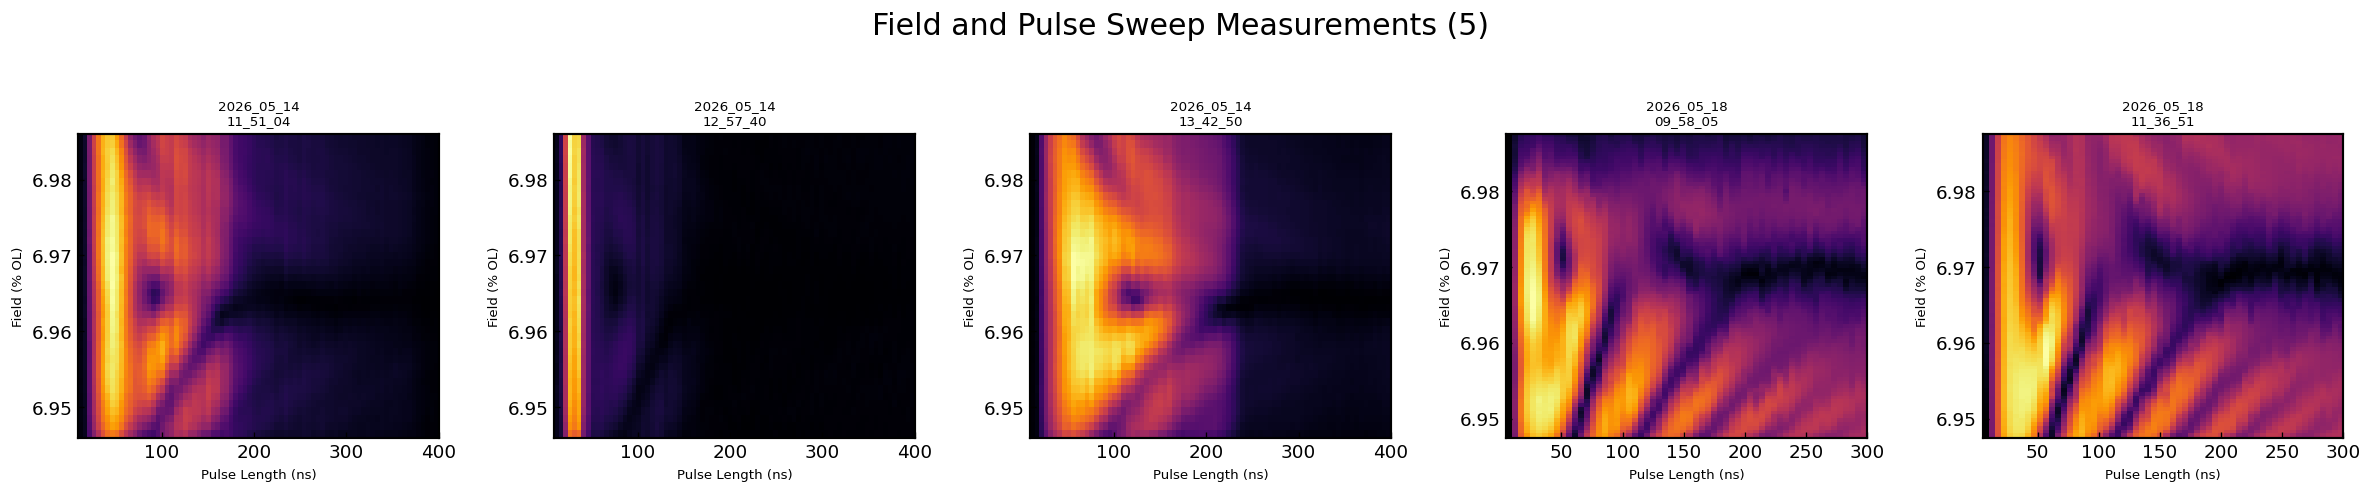

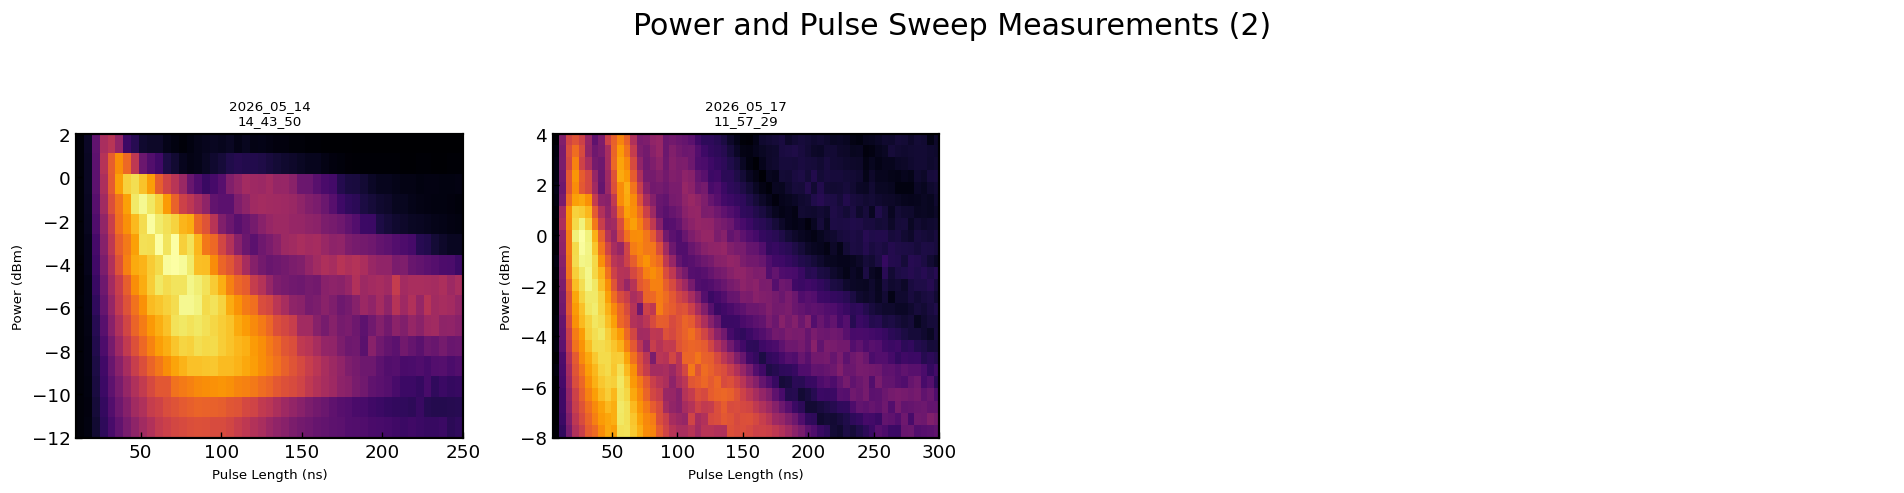

In [6]:
style1 = plt.get_cmap("inferno")
style2 = plt.get_cmap("viridis")

# plot_all_measurements(df_field, ncols=5,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_power, ncols=5,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_frequency, ncols=5,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_pulse, ncols=7,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_phase, ncols=5,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_double_pulse_delay, ncols=6,cmap_integrated=style1, cmap_signal=style2)
# plot_all_measurements(df_field_freq, ncols=5,cmap_integrated=style1, cmap_signal=style2)
plot_all_measurements(df_field_pulse, ncols=5,cmap_integrated=style1, cmap_signal=style2)
plot_all_measurements(df_power_pulse, ncols=4,cmap_integrated=style1, cmap_signal=style2)

### 1.3  Helper functions

All axis-building and data-extraction logic

In [39]:
def OL_to_mT(ol):
    """Calibrated OL (% overload) → B0 (mT) for this TEM setup."""
    return 22.934 * np.asarray(ol, dtype=float) + 18.678


def load_field_pulse(row): 
    """
    Extract arrays from a df_field_pulse row.

    Returns
    -------
    signal   : (n_field, n_pulse, n_time)  float  [mV]  ref-subtracted
    t_ns     : (n_time,)   time axis in ns, zero at first sample
    field_mT : (n_field,)  B0 axis in mT, always ascending
    pulse_ns : (n_pulse,)  pulse-length axis in ns
    """
    data     = row['data']
    settings = row['settings']

    osci     = np.array(data['Osci'],      dtype=float)
    osci_ref = np.array(data['Osci_ref'],  dtype=float)
    t_raw    = np.array(data['Timestamps'], dtype=float)

    signal = (osci - osci_ref) * 1e3          # V → mV
    t_ns   = (t_raw - t_raw[0]) * 1e9         # s → ns, zero at start

    # field axis
    fp      = settings['field_pct']
    n_field = signal.shape[0]
    field_OL = fp['start'] + fp['step'] * np.arange(n_field)
    field_mT = OL_to_mT(field_OL)
    if field_mT[-1] < field_mT[0]:            # ensure ascending
        field_mT = field_mT[::-1]
        signal   = signal[::-1, :, :]

    # pulse axis
    pp      = settings['pulse_ns']
    n_pulse = signal.shape[1]
    pulse_ns = np.arange(pp['length_start'],
                          pp['length_stop'] + pp['length_step'] / 2,
                          pp['length_step'], dtype=float)
    if len(pulse_ns) != n_pulse:
        pulse_ns = np.linspace(pp['length_start'], pp['length_stop'], n_pulse)

    return signal, t_ns, field_mT, pulse_ns


def load_power_pulse(row):
    """
    Extract arrays from a df_power_pulse row.

    Returns
    -------
    signal    : (n_pow, n_pulse, n_time)  float  [mV]
    t_ns      : (n_time,)  time axis in ns
    power_dBm : (n_pow,)   power axis in dBm
    pulse_ns  : (n_pulse,) pulse-length axis in ns
    """
    data     = row['data']
    settings = row['settings']

    osci     = np.array(data['Osci'],      dtype=float)
    osci_ref = np.array(data['Osci_ref'],  dtype=float)
    t_raw    = np.array(data['Timestamps'], dtype=float)

    signal = (osci - osci_ref) * 1e3
    t_ns   = (t_raw - t_raw[0]) * 1e9

    pp = settings['pulse_ns']
    n_pulse = signal.shape[1] if signal.ndim == 3 else signal.shape[0]
    pulse_ns = np.arange(pp['length_start'],
                          pp['length_stop'] + pp['length_step'] / 2,
                          pp['length_step'], dtype=float)
    if len(pulse_ns) != n_pulse:
        pulse_ns = np.linspace(pp['length_start'], pp['length_stop'], n_pulse)

    pd_s = settings['power_dBm']
    if signal.ndim == 3:
        n_pow     = signal.shape[0]
        power_dBm = np.linspace(pd_s['start'], pd_s['stop'], n_pow)
    else:
        power_dBm = np.array([pd_s['start']])
        signal    = signal[np.newaxis, ...]

    return signal, t_ns, power_dBm, pulse_ns


def snr_estimate(sig_3d, n_short=5):
    """
    Rough SNR for a power-pulse dataset.
    Peak integrated |signal| (averaged over power) divided by the std
    of the integrated signal at the shortest pulse lengths, where the
    FID is negligible (tau_p << tau_pi/2).
    """
    integ      = np.sum(np.abs(sig_3d), axis=2)   # (n_pow, n_pulse)
    integ_mean = integ.mean(axis=0)               # average over power rows
    noise_std  = np.std(integ_mean[:n_short]) + 1e-9
    return float(np.max(integ_mean) / noise_std)


# ── Model functions ───────────────────────────────────────────

def damped_cosine(t, A, T2s, fIF, phi, t0, C):
    """Damped cosine FID model. fIF in MHz, t in ns."""
    tt = t - t0
    return A * np.exp(-tt / T2s) * np.cos(2*np.pi * fIF * 1e-3 * tt + phi) + C

def lorentzian(B, B0, HWHM, A, bg): # used for field sweep fitting
    """Lorentzian lineshape in field domain."""
    return bg + A / (1.0 + ((B - B0) / HWHM)**2)

def lorentzian_freq(f, f0, HWHM, A, bg): # used for frequency sweep fitting
    """Lorentzian lineshape in frequency domain."""
    return bg + A / (1.0 + ((f - f0) / HWHM)**2)

def lorentzian_slope(B, B0, HWHM, A, bg, slope): # used for field sweep fitting with linear background
    """Lorentzian plus linear slope for asymmetric backgrounds."""
    return bg + slope*(B - B[0]) + A / (1.0 + ((B - B0)/HWHM)**2)

def rabi_model(tau, A, T_period, phi, T_Rabi, C): # used for pulse sweep fitting of Rabi oscillations
    """Damped cosine Rabi oscillation model."""
    return A * np.exp(-tau / T_Rabi) * np.cos(2*np.pi*tau / T_period + phi) + C

def exp_decay(t, A, T_Rabi, C):
    """Single exponential decay."""
    return A * np.exp(-t / T_Rabi) + C

def find_first_minimum(row_signal, pulse_axis, noise_frac=0.15):
    """
    Return pulse length of first local minimum after the first maximum.
    noise_frac: minimum required dip depth as fraction of peak-to-trough range.
    """
    y        = uniform_filter1d(row_signal.astype(float), size=3)
    peak_idx = int(np.argmax(y))
    if peak_idx >= len(y) - 2:
        return np.nan
    threshold = y[peak_idx] - noise_frac * (y[peak_idx] - np.min(y))
    for i in range(peak_idx + 1, len(y) - 1):
        if y[i] <= y[i-1] and y[i] <= y[i+1] and y[i] < threshold:
            return float(pulse_axis[i])
    return np.nan


### 1.4  Select the dataset for the Rabi analysis

In [8]:
# available field-pulse datasets
print(f'Available field-pulse datasets ({len(df_field_pulse)} total):')
print(f'{"idx":<5} {"date":<14} {"prefix":<12} {"shape"}')
print('-' * 50)
for i, row in df_field_pulse.iterrows():
    shape = row['osci_shape']
    print(f'{i:<5} {row["date"]:<14} {row["prefix"]:<12} {shape}')


Available field-pulse datasets (5 total):
idx   date           prefix       shape
--------------------------------------------------
0     2026_05_14     11_51_04     (41, 79, 1000)
1     2026_05_14     12_57_40     (41, 79, 1000)
2     2026_05_14     13_42_50     (41, 79, 1000)
3     2026_05_18     09_58_05     (81, 60, 2000)
4     2026_05_18     11_36_51     (81, 60, 2000)


In [9]:
MAIN_IDX = 4   # select dataset to analyze (index in df_field_pulse)

row_main = df_field_pulse.iloc[MAIN_IDX]
signal, t_ns, field_mT, pulse_ns = load_field_pulse(row_main)

n_field, n_pulse, n_time = signal.shape
print(f'Loaded   : {row_main["date"]}  {row_main["prefix"]}')
print(f'Shape    : {n_field} fields × {n_pulse} pulses × {n_time} time samples')
print(f'Field    : {field_mT[0]:.3f} – {field_mT[-1]:.3f} mT')
print(f'Pulse    : {pulse_ns[0]:.0f} – {pulse_ns[-1]:.0f} ns  (step {pulse_ns[1]-pulse_ns[0]:.0f} ns)')
print(f'Time     : {t_ns[0]:.1f} – {t_ns[-1]:.1f} ns')


Loaded   : 2026_05_18  11_36_51
Shape    : 81 fields × 60 pulses × 2000 time samples
Field    : 178.012 – 178.929 mT
Pulse    : 5 – 300 ns  (step 5 ns)
Time     : 0.0 – 499.7 ns


---
## 2  Field profile → resonant field

- Integrate $|s(t)|$ over the FID window (after dead time, before noise floor) and over all pulse lengths.
- Resonant field is identified **visually**, from the Rabi chevron vertex: the first π-pulse minimum occurs at the shortest pulse length there, consistent with $\tilde\Omega_R$ being maximal at resonance.
- Automated peak-finding on the integrated signal failed for this dataset — the field-dependent background coupling means integrated $|s(t)|$ is not a clean proxy for resonance here.
- `res_OL` is set **once**, here, and reused by every later section.

Resonant field: 178.528 mT  (6.9700 % OL)  [index 45]


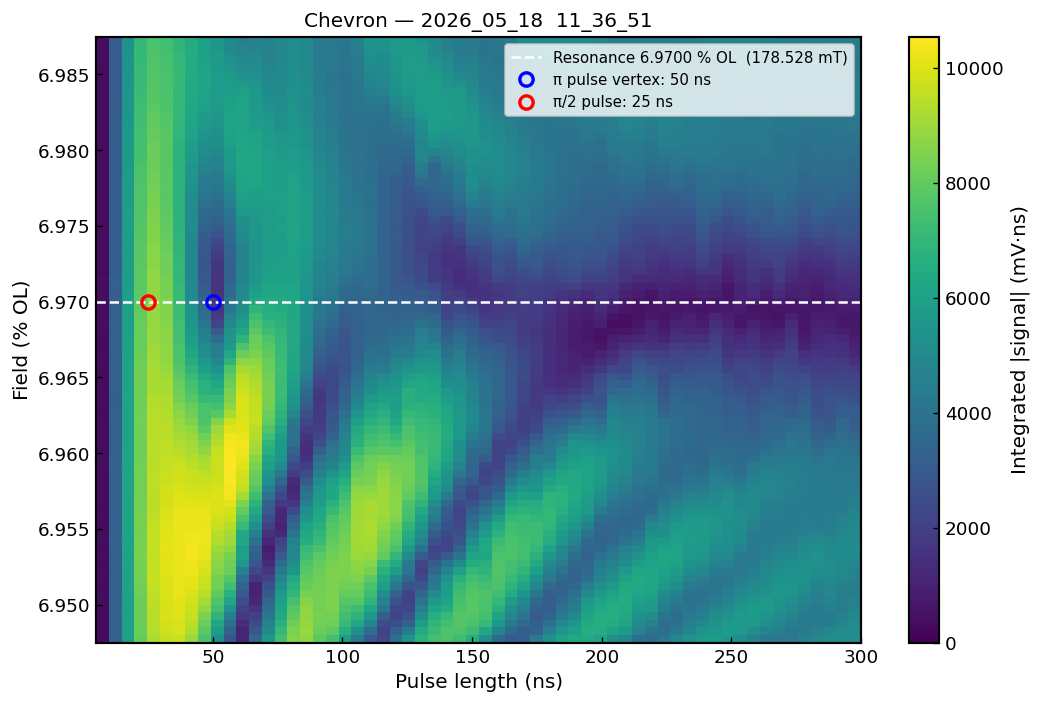

In [ ]:
# ── Set resonant field by eye from chevron vertex ─────────────
fp_s    = row_main['settings']['field_pct']
OL_axis = fp_s['start'] + fp_s['step'] * np.arange(n_field)
if OL_axis[-1] < OL_axis[0]:
    OL_axis = OL_axis[::-1]

######################## set resonant field by eye from chevron vertex
res_OL  = 6.97 #6.969
#########################

res_idx = int(np.argmin(np.abs(OL_axis - res_OL)))
B_res   = field_mT[res_idx]
res_OL  = OL_axis[res_idx]


print(f'Resonant field: {B_res:.3f} mT  ({res_OL:.4f} % OL)  [index {res_idx}]')

# find_first_minimum is defined once, in Section 1.3 (helper functions)

# ── Chevron with resonance line and vertex marker ──────────────
t_mask_res   = (t_ns >= 70) & (t_ns <= 400)
unsigned_map = np.sum(np.abs(signal[:, :, t_mask_res]), axis=2)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(unsigned_map, aspect='auto', origin='lower',
               extent=[pulse_ns[0], pulse_ns[-1], OL_axis[0], OL_axis[-1]],
               cmap='viridis', vmin=0, vmax=np.max(unsigned_map))

ax.axhline(res_OL, color='white', lw=1.5, ls='--',
           label=f'Resonance {res_OL:.4f} % OL  ({B_res:.3f} mT)')

# Integrate |signal| over the fit window for the resonant field row.
integ_res_row = np.sum(np.abs(signal[res_idx, :, :][:, t_mask_res]), axis=1)

# Find the first minimum after the peak in the integrated signal at the resonant field.
tau_pi_res    = find_first_minimum(integ_res_row, pulse_ns, noise_frac=0.10)

# Plot markers for π pulse vertex and π/2 pulse if a minimum was found.
if np.isfinite(tau_pi_res):
    ax.plot(tau_pi_res, res_OL, 'o', ms=8, color='blue',
            markerfacecolor='none', markeredgewidth=2,
            label=f'π pulse vertex: {tau_pi_res:.0f} ns')
    ax.plot(tau_pi_res / 2, res_OL, 'o', ms=8, color='red',
            markerfacecolor='none', markeredgewidth=2,
            label=f'π/2 pulse: {tau_pi_res/2:.0f} ns')
else:
    print('find_first_minimum did not find a minimum — set tau_pi_res manually')
    tau_pi_res = 50   # fallback

fig.colorbar(im, ax=ax, label='Integrated |signal| (mV·ns)')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Field (% OL)')
ax.set_title(f'Chevron — {row_main["date"]}  {row_main["prefix"]}')
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

---
## 3  FID at resonance → $T_2^*$

### 3.1  Time-domain fit

**Model**

$$s(t) = A\,e^{-(t-t_0)/T_2^*}\cos\!\big(2\pi f_{\rm IF}(t-t_0)+\phi\big) + C$$

after heterodyne downconversion, the oscilloscope records a damped
cosine at the intermediate frequency $f_{\rm IF} = |f_{\rm drive}-f_{\rm LO}|$.
Free parameters: amplitude $A$, dephasing time $T_2^*$, $f_{\rm IF}$, phase $\phi$, FID start time $t_0$, offset $C$.

**Procedure**
- DC offset $C$ estimated from the last 10% of the trace (pure noise, long after the FID has decayed) and subtracted before fitting.
- Hilbert envelope $A(t)=|s(t)+i\mathcal H[s](t)|$ gives the instantaneous amplitude with no assumption of exponential decay — used to set initial guesses and to visually confirm the decay is a clean single exponential.
- Fit window (start/end) is scanned on a 2D grid; the window minimising residual RMS while keeping $T_2^*$ within 5 ns of the all-window median is selected automatically.

Using pulse index 4 = 25 ns (nearest to π/2 = 25.0 ns)
Field index 45 = 6.9700 % OL  (178.528 mT)


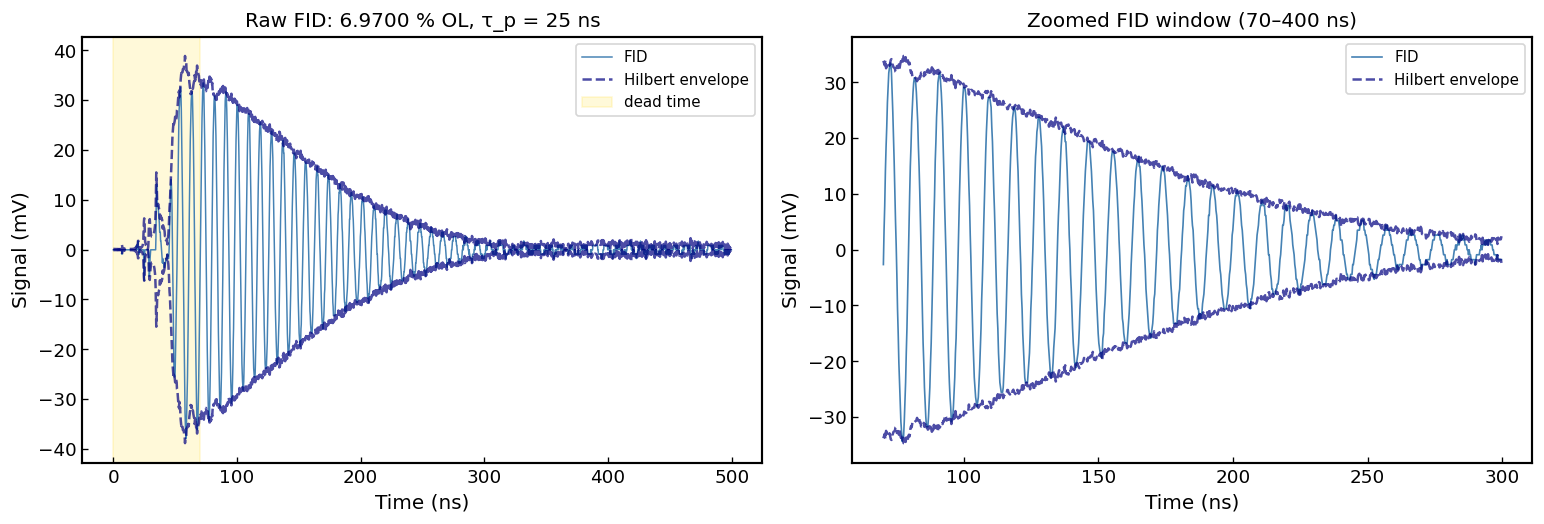

Hilbert 1/e estimate: T2* ≈ 112.0 ns


In [ ]:
# ── FID at resonance: load trace, DC-subtract, Hilbert envelope ─
# Use the π/2 pulse length identified from the chevron
tau_pi2_res = tau_pi_res / 2   # 27.5 ns → nearest grid point
pi2_idx     = int(np.argmin(np.abs(pulse_ns - tau_pi2_res)))
tau_sel     = pulse_ns[pi2_idx]
print(f'Using pulse index {pi2_idx} = {tau_sel:.0f} ns (nearest to π/2 = {tau_pi2_res:.1f} ns)')
print(f'Field index {res_idx} = {res_OL:.4f} % OL  ({B_res:.3f} mT)')

# Raw trace (ref-subtracted, DC removed)
trace_raw = signal[res_idx, pi2_idx, :]
C_est     = np.mean(trace_raw[-max(10, n_time // 10):]) # estimate DC from last 10% of samples
trace     = trace_raw - C_est

# Hilbert envelope
analytic  = hilbert(trace)
envelope  = np.abs(analytic)

# ── Quick inspection plot before any fitting ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(t_ns, trace,    color='steelblue', lw=0.9, label='FID')
ax.plot(t_ns,  envelope, color='navy', lw=1.5, ls='--', alpha=0.7, label='Hilbert envelope')
ax.plot(t_ns, -envelope, color='navy', lw=1.5, ls='--', alpha=0.7)
ax.axvspan(t_ns[0], 70, color='gold', alpha=0.15, label='dead time')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Signal (mV)')
ax.set_title(f'Raw FID: {res_OL:.4f} % OL, τ_p = {tau_sel:.0f} ns')
ax.legend(fontsize=9)

# Zoom into FID window
ax = axes[1]
zoom_mask = (t_ns >= 70) & (t_ns <= 300)
ax.plot(t_ns[zoom_mask], trace[zoom_mask],    color='steelblue', lw=1.0, label='FID')
ax.plot(t_ns[zoom_mask],  envelope[zoom_mask], color='navy', lw=1.5, ls='--', alpha=0.7, label='Hilbert envelope')
ax.plot(t_ns[zoom_mask], -envelope[zoom_mask], color='navy', lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Signal (mV)')
ax.set_title('Zoomed FID window (70–400 ns)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Print rough T2* from Hilbert envelope 1/e crossing
fid_start_i = int(np.argmin(np.abs(t_ns - 70)))
env_w       = envelope[fid_start_i:]
if np.max(env_w) > 0:
    env_norm    = env_w / np.max(env_w)
    cross_i     = np.argmax(env_norm < np.exp(-1))
    T2s_visual  = float(t_ns[fid_start_i + cross_i] - t_ns[fid_start_i]) # finds the first crossing of 1/e
    T2s_visual  = max(T2s_visual, 20.0)
    print(f'Hilbert 1/e estimate: T2* ≈ {T2s_visual:.1f} ns')

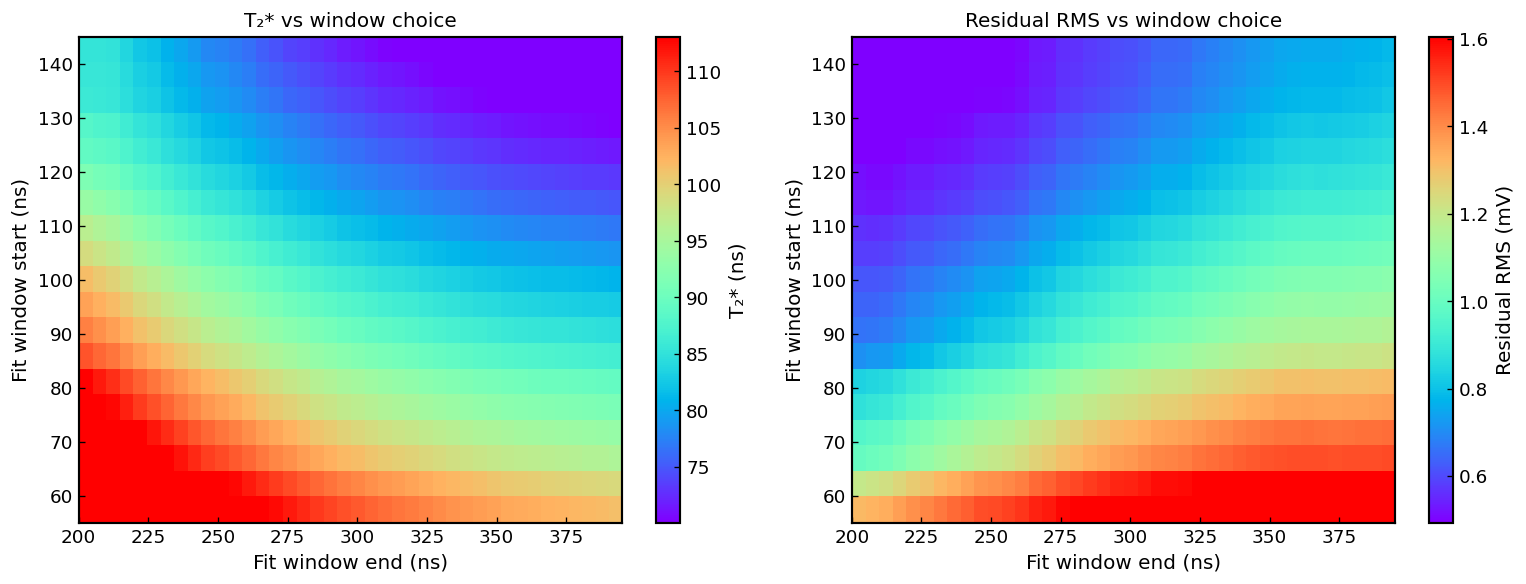

Median T2* across all windows : 87.6 ns
Std of T2* across all windows : 13.3 ns
This std tells you how sensitive T2* is to the window choice.
Best window  : 140 – 210 ns
T2* at best  : 85.5 ns
Residual RMS : 0.429 mV
Systematic uncertainty from window choice: ± 13.3 ns
Report as: T2* = 85 ± 13 ns (sys)


In [ ]:
# ── Fit T2* with damped cosine model, scanning fit window ─────

t_starts = np.arange(55, 150, 5)    # ns # time window start times to scan
t_ends   = np.arange(200, 400, 5)  # ns # time window end times to scan

T2s_grid   = np.full((len(t_starts), len(t_ends)), np.nan)
resid_grid = np.full((len(t_starts), len(t_ends)), np.nan)


for i, ts in enumerate(t_starts):
    for j, te in enumerate(t_ends):
        mask = (t_ns >= ts) & (t_ns <= te)
        if mask.sum() < 20:
            continue
        tf = t_ns[mask]
        yf = trace[mask]
        dt = float(np.median(np.diff(tf)))

        # guesses
        env_w  = envelope[mask]
        A_g    = float(np.max(env_w))
        cross  = np.argmax(env_w / np.max(env_w) < np.exp(-1))
        T2s_g  = max(float(tf[cross] - tf[0]) if cross > 0 else 80.0, 20.0)
        fft_f  = np.fft.rfftfreq(len(yf), d=dt*1e-9)*1e-6
        fft_m  = np.abs(np.fft.rfft(yf - np.mean(yf)))
        fIF_g  = float(fft_f[1:][np.argmax(fft_m[1:])])
        phi_g  = float(np.angle(analytic[mask][0]))

        p0 = [A_g, T2s_g, fIF_g, phi_g, float(tf[0]), 0.0]
        lo = [0., 1., 0., -np.pi, float(tf[0])-10, -np.inf]
        hi = [np.inf, np.inf, np.inf, np.pi, float(tf[0])+10, np.inf]

        try:
            popt, _ = curve_fit(damped_cosine, tf, yf,
                                 p0=p0, bounds=(lo,hi), maxfev=200000)
            T2s_grid[i, j]   = popt[1]
            resid_grid[i, j] = float(np.std(yf - damped_cosine(tf, *popt)))
        except:
            pass

# ── Plot: T2* as function of window choice ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes[0].imshow(T2s_grid, aspect='auto', origin='lower',
                      extent=[t_ends[0], t_ends[-1], t_starts[0], t_starts[-1]],
                      cmap='rainbow', vmin=np.nanpercentile(T2s_grid, 5),
                                     vmax=np.nanpercentile(T2s_grid, 95))
fig.colorbar(im0, ax=axes[0], label='T₂* (ns)')
axes[0].set_xlabel('Fit window end (ns)')
axes[0].set_ylabel('Fit window start (ns)')
axes[0].set_title('T₂* vs window choice')

im1 = axes[1].imshow(resid_grid, aspect='auto', origin='lower',
                      extent=[t_ends[0], t_ends[-1], t_starts[0], t_starts[-1]],
                      cmap='rainbow',
                      vmin=np.nanpercentile(resid_grid, 5),
                      vmax=np.nanpercentile(resid_grid, 95))
fig.colorbar(im1, ax=axes[1], label='Residual RMS (mV)')
axes[1].set_xlabel('Fit window end (ns)')
axes[1].set_ylabel('Fit window start (ns)')
axes[1].set_title('Residual RMS vs window choice')

plt.tight_layout()
plt.show()

# Print the stable region
stable = np.abs(T2s_grid - np.nanmedian(T2s_grid)) < 10  # within 10 ns of median
print(f'Median T2* across all windows : {np.nanmedian(T2s_grid):.1f} ns')
print(f'Std of T2* across all windows : {np.nanstd(T2s_grid):.1f} ns')
print(f'This std tells you how sensitive T2* is to the window choice.')

# ── Select best window from the scan ──────────────────────────
# Criteria: T2* within 5 ns of median AND lowest residual RMS
target_T2s = np.nanmedian(T2s_grid)
stable_mask = np.abs(T2s_grid - target_T2s) < 5.0
resid_masked = np.where(stable_mask, resid_grid, np.nan)

best_ij = np.unravel_index(np.nanargmin(resid_masked), resid_masked.shape)
best_start = t_starts[best_ij[0]]
best_end   = t_ends[best_ij[1]]
best_T2s   = T2s_grid[best_ij]

print(f'Best window  : {best_start:.0f} – {best_end:.0f} ns')
print(f'T2* at best  : {best_T2s:.1f} ns')
print(f'Residual RMS : {resid_grid[best_ij]:.3f} mV')
print(f'Systematic uncertainty from window choice: ± {np.nanstd(T2s_grid):.1f} ns')
print(f'Report as: T2* = {best_T2s:.0f} ± {np.nanstd(T2s_grid):.0f} ns (sys)')

# Use these for the final fit
dead_ns    = best_start
t_fit_end  = best_end

Fit window: 140 – 210 ns  (280 points)
Guesses:  A = 21.96 mV   T2* = 20.0 ns   fIF = 114.286 MHz   phi = 2.08 rad


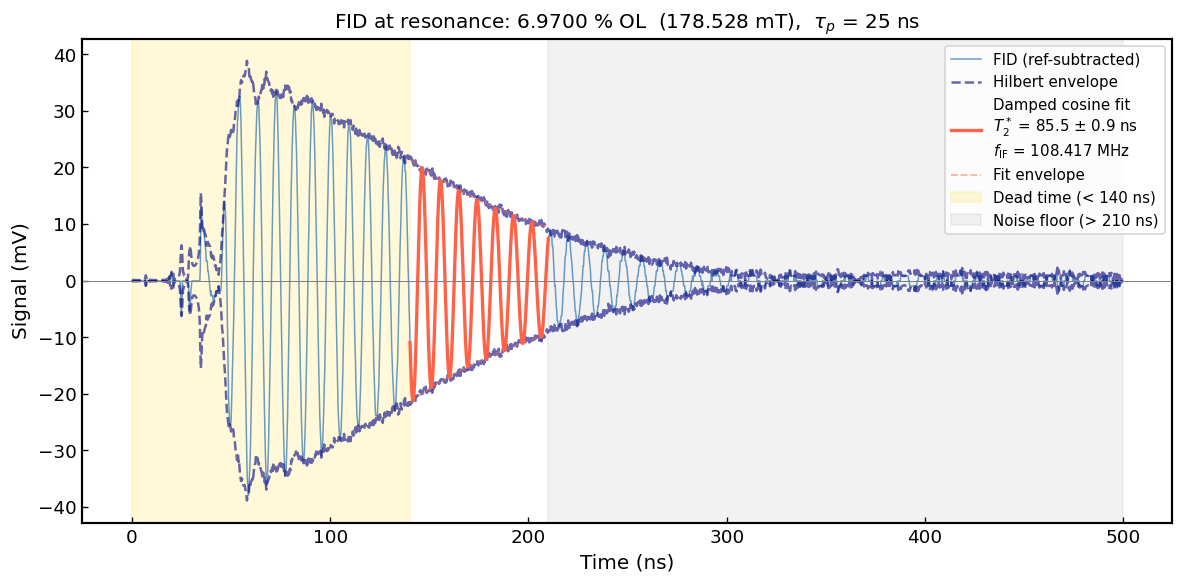

T2* (time domain) = 85.46 ± 0.94 ns
f_IF              = 108.4174 MHz
Amplitude         = 21.032 mV


In [ ]:
# ── Fit window ────────────────────────────────────────────────
dead_ns     = best_start # 125       # use results of window scan to set
t_fit_start = dead_ns
t_fit_end   = best_end #210      # use results of window scan to set

fit_mask = (t_ns >= t_fit_start) & (t_ns <= t_fit_end)
t_fit    = t_ns[fit_mask]
y_fit    = trace[fit_mask]
dt_fit   = float(np.median(np.diff(t_fit)))

print(f'Fit window: {t_fit[0]:.0f} – {t_fit[-1]:.0f} ns  ({fit_mask.sum()} points)')

# ── Data-driven initial guesses ───────────────────────────────
A_est   = float(np.max(envelope[fit_mask]))

# T2* from 1/e crossing of Hilbert envelope in fit window
env_w   = envelope[fit_mask]
env_n   = env_w / np.max(env_w)
cross_i = np.argmax(env_n < np.exp(-1))
T2s_est = float(t_fit[cross_i] - t_fit[0]) 
T2s_est = max(T2s_est, 20.0)

# f_IF from FFT peak of DC-subtracted windowed signal f_IF is ffrequency after downconversion, in MHz
fft_f   = np.fft.rfftfreq(len(y_fit), d=dt_fit * 1e-9) * 1e-6   # MHz
fft_m   = np.abs(np.fft.rfft(y_fit - np.mean(y_fit)))
fIF_est = float(fft_f[1:][np.argmax(fft_m[1:])]) # f_IF est from FFT peak of DC-subtracted windowed signal

# phi from argument of analytic signal at start of fit window
phi_est = float(np.angle(analytic[fit_mask][0]))
t0_est  = float(t_fit[0])

print(f'Guesses:  A = {A_est:.2f} mV   T2* = {T2s_est:.1f} ns   '
      f'fIF = {fIF_est:.3f} MHz   phi = {phi_est:.2f} rad')

# ── Damped cosine model ───────────────────────────────────────
# fIF in MHz, t in ns → multiply by 1e-3 to get cycles/ns = GHz... 
# 2π × fIF[MHz] × t[ns] × 1e-3 gives radians  ✓
def damped_cosine(t, A, T2s, fIF, phi, t0, C):
    tt = t - t0
    return A * np.exp(-tt / T2s) * np.cos(2*np.pi * fIF * 1e-3 * tt + phi) + C

p0 = [A_est,  T2s_est, fIF_est, phi_est, t0_est,  0.0] # initial guess based on estimates 
lo = [0.,     1.,      0.,     -np.pi,   t0_est - 10, -np.inf] # lower bounds for parameters
hi = [np.inf, np.inf,  np.inf,  np.pi,   t0_est + 10,  np.inf] # upper bounds for parameters

try: # fit the damped cosine model to the FID in the selected window
    popt_dc, pcov_dc = curve_fit(
        damped_cosine, t_fit, y_fit,
        p0=p0, bounds=(lo, hi), maxfev=200000
    )
    A_dc, T2s_dc, fIF_dc, phi_dc, t0_dc, C_dc = popt_dc
    T2s_dc_err = float(np.sqrt(np.diag(pcov_dc))[1]) # estimate error on T2* from covariance 
    dc_ok = True
except Exception as e:
    print('Damped-cosine fit failed:', e)
    dc_ok = False; T2s_dc = np.nan; T2s_dc_err = np.nan

# ── Plot ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(t_ns, trace, color='steelblue', lw=0.9, alpha=0.8,
        label='FID (ref-subtracted)')
ax.plot(t_ns,  envelope, color='navy', lw=1.5, ls='--', alpha=0.6,
        label='Hilbert envelope')
ax.plot(t_ns, -envelope, color='navy', lw=1.5, ls='--', alpha=0.6)

if dc_ok:
    td  = np.linspace(t_fit[0], t_fit[-1], 3000)
    yd  = damped_cosine(td, *popt_dc)
    ev  = A_dc * np.exp(-(td - t0_dc) / T2s_dc)
    ax.plot(td, yd, color='tomato', lw=2.0,
            label=f'Damped cosine fit\n'
                  f'$T_2^*$ = {T2s_dc:.1f} ± {T2s_dc_err:.1f} ns\n'
                  f'$f_{{\\rm IF}}$ = {fIF_dc:.3f} MHz')
    ax.plot(td,  ev, color='tomato', lw=1.1, ls='--', alpha=0.5,
            label='Fit envelope')
    ax.plot(td, -ev, color='tomato', lw=1.1, ls='--', alpha=0.5)

ax.axvspan(t_ns[0], dead_ns, color='gold', alpha=0.15,
           label=f'Dead time (< {dead_ns:.0f} ns)')
ax.axvspan(t_fit_end, t_ns[-1], color='gray', alpha=0.10,
           label=f'Noise floor (> {t_fit_end:.0f} ns)')
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Signal (mV)')
ax.set_title(f'FID at resonance: {res_OL:.4f} % OL  ({B_res:.3f} mT),  '
             f'$\\tau_p$ = {tau_sel:.0f} ns')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

if dc_ok:
    print(f'T2* (time domain) = {T2s_dc:.2f} ± {T2s_dc_err:.2f} ns')
    print(f'f_IF              = {fIF_dc:.4f} MHz')
    print(f'Amplitude         = {A_dc:.3f} mV')

### 3.2  FFT linewidth — why it doesn't work here

- Independent cross-check of $T_2^*$, no time-domain model needed. FID FFT is a Lorentzian:

$$|\hat s(f)| \propto \frac{1}{\sqrt{1+(2\pi T_2^*)^2(f-f_{\rm IF})^2}} \quad\Rightarrow\quad T_2^* = \frac{1}{\pi\,\Delta f_{\rm FWHM}}$$

- **Fails here** — resolution, not fitting, is the problem:

$$\delta f = \frac{1}{T_{\rm window}} \approx \frac{1}{300\,{\rm ns}} \approx 3.3\,{\rm MHz} \quad\sim\quad \Delta f_{\rm FWHM} \approx 3.5\,{\rm MHz}$$

- $\delta f \sim \Delta f_{\rm FWHM}$ → nothing left to resolve. Zero-padding smooths the peak but adds no real resolution.
- Can't just extend the window: FID decays into noise at a $T_2^*$-dependent time — the quantity we want *is* the limit on the data we have.
- Confirmed by scanning the fit window below: $T_2^*$ swings wildly window-to-window; $f_{\rm IF}$ (peak position, not width) stays stable.

**Two further attempts, same conclusion:**
- Longest pulse (300 ns) ≈ continuous driving → window still too short vs. $T_2^*$.
- Lorentzian fit to the **field-sweep** lineshape instead → no clean Lorentzian shape (likely the same resolution issue, compounded by it also being a pulsed measurement).

Both kept below as part of the record.

Window length      : 70 ns
Freq resolution    : 14.29 MHz  (= 1/T_win)
Expected FWHM      : 3.72 MHz  (= 1/pi*T2*)
Resolution / FWHM  : 3.84  (need << 1 for reliable fit)
f_IF (peak)        : 107.143 MHz  (reliable)
T2* (FFT fit)      : 13.7 ns  (unreliable — ratio too close to 1)


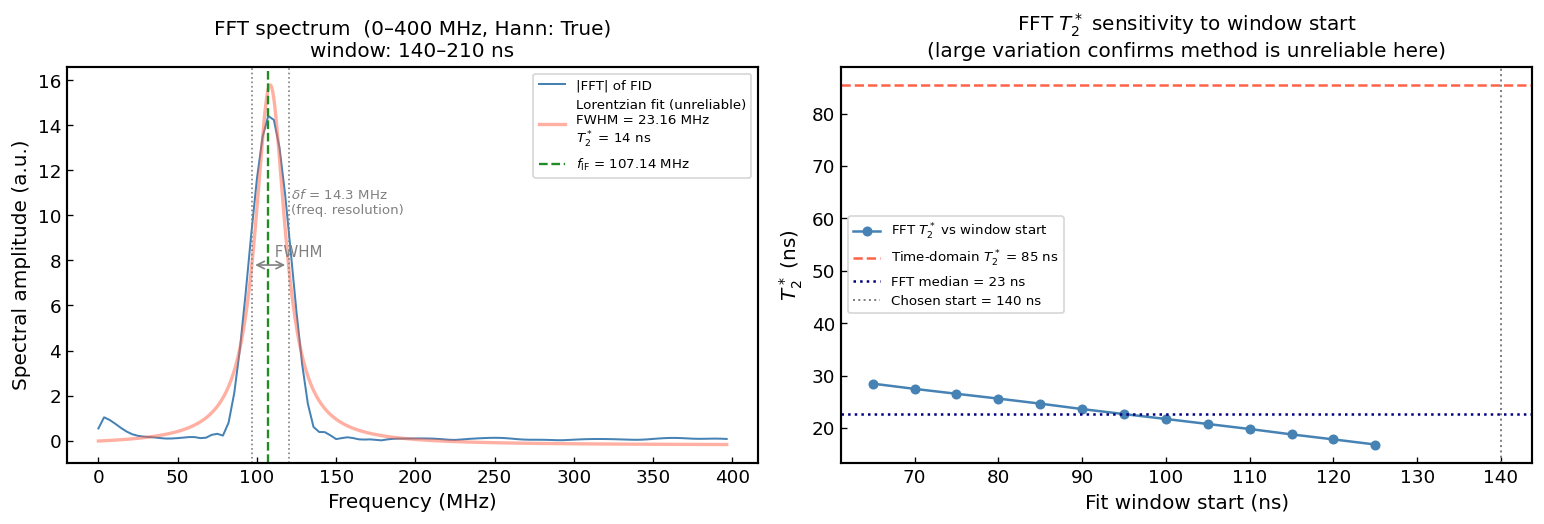

───────────────────────────────────────────────────────
T2* (time domain)  = 85.5 ± 13.3 ns  (sys)
T2* (FFT / FWHM)   = 13.7 ± 3.6 ns  (sys, unreliable)
f_IF               = 107.143 MHz  (reliable)

Conclusion: FFT linewidth method is not reliable for this dataset.
Reason: delta_f = 14.3 MHz ≈ expected FWHM = 3.7 MHz
A window of T_win >> pi*T2* = 268 ns would be needed.


In [14]:
# ── FFT spectrum and f_IF extraction (Section 3.2) ─────────────
# The FFT of the FID is the ESR absorption spectrum in the
# frequency domain. For a single-exponential FID the spectrum
# is a Lorentzian with FWHM = 1/(pi*T2*).
#
#
# This cell demonstrates the limitation explicitly and extracts
# f_IF (the peak frequency) which is reliable regardless.

fit_mask = (t_ns >= best_start) & (t_ns <= best_end)
dt_fit   = float(np.median(np.diff(t_ns[fit_mask])))

y_fid  = trace[fit_mask].copy()
y_fid -= np.mean(y_fid)

USE_HANN = True
if USE_HANN:
    window  = np.hanning(len(y_fid))
    y_fid_w = y_fid * window / np.mean(window)
else:
    y_fid_w = y_fid.copy()

N_pad     = 4 * len(y_fid_w)
dt_s      = dt_fit * 1e-9
freqs_fft = np.fft.rfftfreq(N_pad, d=dt_s) * 1e-6   # MHz

Sfft      = np.abs(np.fft.rfft(y_fid_w, n=N_pad)) / len(y_fid_w)
Sfft[1:-1] *= 2

# Limit to physically meaningful frequency range
# Nyquist is 2000 MHz but signal only exists below ~400 MHz
freq_mask = freqs_fft <= 400
freqs_plot = freqs_fft[freq_mask]
Sfft_plot  = Sfft[freq_mask]

# ── f_IF from peak position (reliable) ───────────────────────
pk_plot = int(np.argmax(Sfft_plot))
f_IF_measured = freqs_plot[pk_plot]

# ── Lorentzian fit (shown but expected to be unreliable) ──────
def lorentzian_freq(f, f0, HWHM, A, bg):
    return bg + A / (1.0 + ((f - f0) / HWHM)**2)

pk_full = int(np.argmax(Sfft_plot))
p0f = [freqs_plot[pk_full],
       (freqs_plot[-1] - freqs_plot[0]) / 20,
       Sfft_plot[pk_full] - np.median(Sfft_plot),
       np.median(Sfft_plot)]

try:
    popt_f, pcov_f = curve_fit(
        lorentzian_freq, freqs_plot, Sfft_plot,
        p0=p0f, maxfev=50000
    )
    f0_f, HWHM_f, A_f, bg_f = popt_f
    FWHM_MHz = 2.0 * abs(HWHM_f)
    T2s_fft  = 1.0 / (np.pi * FWHM_MHz * 1e6) * 1e9
    fft_ok   = True
except Exception as e:
    print('FFT fit failed:', e)
    fft_ok = False; FWHM_MHz = np.nan; T2s_fft = np.nan

# ── Window sensitivity scan ───────────────────────────────────
T2s_fft_scan  = []
t_starts_scan = np.arange(65, 130, 5)

for ts in t_starts_scan:
    mask = (t_ns >= ts) & (t_ns <= best_end)
    if mask.sum() < 20:
        T2s_fft_scan.append(np.nan); continue
    yf = trace[mask].copy()
    yf -= np.mean(yf)
    if USE_HANN:
        w  = np.hanning(len(yf))
        yf = yf * w / np.mean(w)
    N_p = 4 * len(yf)
    dt_ = float(np.median(np.diff(t_ns[mask]))) * 1e-9
    ff  = np.fft.rfftfreq(N_p, d=dt_) * 1e-6
    Sf  = np.abs(np.fft.rfft(yf, n=N_p)) / len(yf)
    Sf[1:-1] *= 2
    fm  = ff <= 400
    try:
        pp, _ = curve_fit(lorentzian_freq, ff[fm], Sf[fm],
                          p0=[ff[fm][np.argmax(Sf[fm])],
                              (ff[fm][-1]-ff[fm][0])/20,
                              Sf[fm][np.argmax(Sf[fm])] - np.median(Sf[fm]),
                              np.median(Sf[fm])],
                          maxfev=50000)
        T2s_fft_scan.append(1.0 / (np.pi * 2*abs(pp[1]) * 1e6) * 1e9)
    except:
        T2s_fft_scan.append(np.nan)

T2s_fft_scan = np.array(T2s_fft_scan)
T2s_fft_sys  = float(np.nanstd(T2s_fft_scan))

# ── Resolution vs FWHM comparison ────────────────────────────
window_ns    = best_end - best_start
delta_f_MHz  = 1.0 / (window_ns * 1e-3)   # MHz
expected_FWHM = 1.0 / (np.pi * T2s_dc * 1e-3) if dc_ok else np.nan  # MHz
print(f'Window length      : {window_ns:.0f} ns')
print(f'Freq resolution    : {delta_f_MHz:.2f} MHz  (= 1/T_win)')
print(f'Expected FWHM      : {expected_FWHM:.2f} MHz  (= 1/pi*T2*)')
print(f'Resolution / FWHM  : {delta_f_MHz/expected_FWHM:.2f}  (need << 1 for reliable fit)')
print(f'f_IF (peak)        : {f_IF_measured:.3f} MHz  (reliable)')
if fft_ok:
    print(f'T2* (FFT fit)      : {T2s_fft:.1f} ns  (unreliable — ratio too close to 1)')

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: FFT spectrum limited to 0–400 MHz
ax = axes[0]
ax.plot(freqs_plot, Sfft_plot, color='steelblue', lw=1.2,
        label='|FFT| of FID')
if fft_ok:
    fd = np.linspace(freqs_plot[0], freqs_plot[-1], 2000)
    ax.plot(fd, lorentzian_freq(fd, *popt_f), color='tomato',
            lw=2, alpha=0.5,
            label=f'Lorentzian fit (unreliable)\n'
                  f'FWHM = {FWHM_MHz:.2f} MHz\n'
                  f'$T_2^*$ = {T2s_fft:.0f} ns')
    mid_y = A_f * 0.5 + bg_f
    ax.axvline(f0_f - abs(HWHM_f), color='gray', ls=':', lw=1)
    ax.axvline(f0_f + abs(HWHM_f), color='gray', ls=':', lw=1)
    ax.annotate('', xy=(f0_f + abs(HWHM_f), mid_y),
                xytext=(f0_f - abs(HWHM_f), mid_y),
                arrowprops=dict(arrowstyle='<->', color='gray'))
    ax.text(f0_f, mid_y * 1.05, ' FWHM', color='gray', fontsize=9)
ax.axvline(f_IF_measured, color='forestgreen', ls='--', lw=1.4,
           label=f'$f_{{\\rm IF}}$ = {f_IF_measured:.2f} MHz')
# Mark the frequency resolution as a horizontal bar at half-max
ax.annotate(f'$\\delta f$ = {delta_f_MHz:.1f} MHz\n(freq. resolution)',
            xy=(f_IF_measured + delta_f_MHz, Sfft_plot[pk_plot]*0.7),
            fontsize=8, color='gray')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('Spectral amplitude (a.u.)')
ax.set_title(f'FFT spectrum  (0–400 MHz, Hann: {USE_HANN})\n'
             f'window: {best_start:.0f}–{best_end:.0f} ns')
ax.legend(fontsize=8)

# Right: T2* from FFT vs window start — shows instability
ax = axes[1]
ax.plot(t_starts_scan, T2s_fft_scan, 'o-', ms=5, color='steelblue',
        label='FFT $T_2^*$ vs window start')
if dc_ok:
    ax.axhline(T2s_dc, color='tomato', ls='--', lw=1.5,
               label=f'Time-domain $T_2^*$ = {T2s_dc:.0f} ns')
ax.axhline(np.nanmedian(T2s_fft_scan), color='navy', ls=':',
           label=f'FFT median = {np.nanmedian(T2s_fft_scan):.0f} ns')
ax.axvline(best_start, color='gray', ls=':', lw=1.2,
           label=f'Chosen start = {best_start:.0f} ns')
ax.set_xlabel('Fit window start (ns)')
ax.set_ylabel('$T_2^*$ (ns)')
ax.set_title('FFT $T_2^*$ sensitivity to window start\n'
             '(large variation confirms method is unreliable here)')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('─' * 55)
if dc_ok:
    print(f'T2* (time domain)  = {T2s_dc:.1f} ± {np.nanstd(T2s_grid):.1f} ns  (sys)')
if fft_ok:
    print(f'T2* (FFT / FWHM)   = {T2s_fft:.1f} ± {T2s_fft_sys:.1f} ns  (sys, unreliable)')
print(f'f_IF               = {f_IF_measured:.3f} MHz  (reliable)')
print(f'\nConclusion: FFT linewidth method is not reliable for this dataset.')
print(f'Reason: delta_f = {delta_f_MHz:.1f} MHz ≈ expected FWHM = {expected_FWHM:.1f} MHz')
print(f'A window of T_win >> pi*T2* = {np.pi*T2s_dc:.0f} ns would be needed.')

**Attempt: longest available pulse (300 ns), to approximate continuous driving — window is still too short relative to $T_2^*$.**

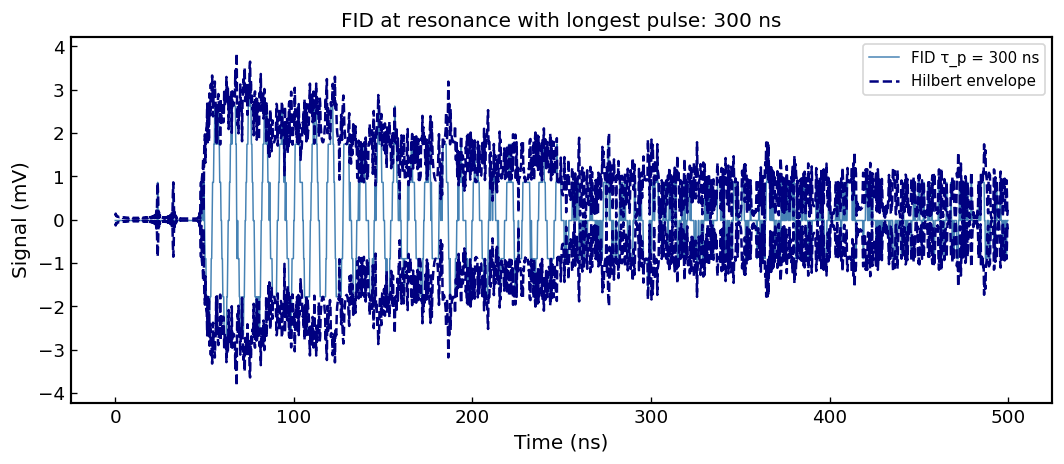

Peak amplitude: 3.500 mV
Noise floor   : 0.486 mV


In [15]:
long_pulse_idx = int(np.argmin(np.abs(pulse_ns - 300)))
trace_long = signal[res_idx, long_pulse_idx, :] 
trace_long -= np.mean(trace_long[-n_time//10:])
analytic_long = hilbert(trace_long)
envelope_long = np.abs(analytic_long)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_ns, trace_long, color='steelblue', lw=0.9, label=f'FID τ_p = {pulse_ns[long_pulse_idx]:.0f} ns')
ax.plot(t_ns, envelope_long, color='navy', lw=1.5, ls='--', label='Hilbert envelope')
ax.plot(t_ns, -envelope_long, color='navy', lw=1.5, ls='--')
ax.set_xlabel('Time (ns)')
ax.set_ylabel('Signal (mV)')
ax.set_title(f'FID at resonance with longest pulse: {pulse_ns[long_pulse_idx]:.0f} ns')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Peak amplitude: {np.max(np.abs(trace_long)):.3f} mV')
print(f'Noise floor   : {np.std(trace_long[-n_time//10:]):.3f} mV')

**Attempt: Lorentzian fit to the field-sweep lineshape instead of the FFT — an independent cross-check, but the data has no clean Lorentzian shape (insufficient resolution / still a pulsed measurement).**

Reloaded field sweep: 2026_05_17  11_09_52
B0   = 177.982 ± 0.003 mT
FWHM = 0.409 mT
T2*  = 27772.3 ns


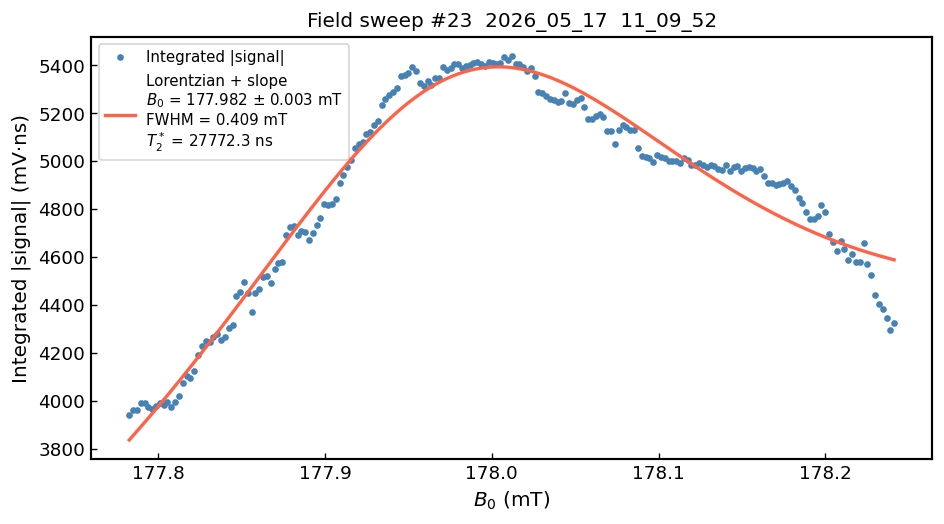

In [16]:
def lorentzian_slope(B, B0, HWHM, A, bg, slope):
    return bg + slope*(B - B[0]) + A / (1.0 + ((B - B0)/HWHM)**2)

# ── Reload field sweep #23 if not defined ─────────────────────
try:
    _ = fs_profile
    _ = fs_mT
except NameError:
    row_fs  = df_field.iloc[23]
    fs_osci = np.array(row_fs['data']['Osci'],      dtype=float)
    fs_ref  = np.array(row_fs['data']['Osci_ref'],  dtype=float)
    fs_t    = np.array(row_fs['data']['Timestamps'], dtype=float)
    fs_t_ns = (fs_t - fs_t[0]) * 1e9
    fs_sig  = (fs_osci - fs_ref) * 1e3

    fp    = row_fs['settings']['field_pct']
    n_f   = fs_sig.shape[0]
    fs_OL = fp['start'] + fp['step'] * np.arange(n_f)
    fs_mT = OL_to_mT(fs_OL)
    if fs_mT[-1] < fs_mT[0]:
        fs_mT  = fs_mT[::-1]
        fs_sig = fs_sig[::-1, :]

    t_mask_fs  = (fs_t_ns >= 70) & (fs_t_ns <= 370)
    fs_profile = np.sum(np.abs(fs_sig[:, t_mask_fs]), axis=1)
    print(f'Reloaded field sweep: {row_fs["date"]}  {row_fs["prefix"]}')

pk  = int(np.argmax(fs_profile))
p0  = [fs_mT[pk], 0.1,
       fs_profile[pk] - np.median(fs_profile),
       np.median(fs_profile), 0.0]

try:
    popt_23, pcov_23 = curve_fit(
        lambda B, B0, HWHM, A, bg, slope: lorentzian_slope(B, B0, HWHM, A, bg, slope),
        fs_mT, fs_profile, p0=p0, maxfev=50000
    )
    B0_23, HWHM_23, A_23, bg_23, slope_23 = popt_23
    B0_23_err = float(np.sqrt(np.diag(pcov_23))[0])
    T2s_23    = 1.0 / (28e6 * 2*np.pi * abs(HWHM_23) * 1e-3) * 1e9
    print(f'B0   = {B0_23:.3f} ± {B0_23_err:.3f} mT')
    print(f'FWHM = {2*abs(HWHM_23):.3f} mT')
    print(f'T2*  = {T2s_23:.1f} ns')
    fit_ok_23 = True
except Exception as e:
    print('Fit failed:', e); fit_ok_23 = False

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(fs_mT, fs_profile, 'o', ms=3, color='steelblue',
        label='Integrated |signal|')
if fit_ok_23:
    Bd = np.linspace(fs_mT[0], fs_mT[-1], 1000)
    ax.plot(Bd, lorentzian_slope(Bd, *popt_23), '-', color='tomato', lw=2,
            label=f'Lorentzian + slope\n'
                  f'$B_0$ = {B0_23:.3f} ± {B0_23_err:.3f} mT\n'
                  f'FWHM = {2*abs(HWHM_23):.3f} mT\n'
                  f'$T_2^*$ = {T2s_23:.1f} ns')
ax.set_xlabel('$B_0$ (mT)')
ax.set_ylabel('Integrated |signal| (mV·ns)')
ax.set_title(f'Field sweep #23  {row_fs["date"]}  {row_fs["prefix"]}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**Conclusion: the FFT-linewidth method is not usable for this dataset
or this experimental configuration**, for both the FID FFT and the
field-sweep lineshape. The time-domain fit in 3.1 is the result used
going forward.

---
## 4  Rabi oscillations at resonance — π and π/2 pulse calibration

**Resonant field:** set once in Section 2 (`res_OL`, `B_res`) &nbsp;|&nbsp; **Dataset:** see Section 1.4

### Physics

- Resonant pulse tips magnetisation by $\theta = \Omega_R \tau_p$: $|M_\perp| = M_0\,|\sin(\Omega_R \tau_p)|$
- Sweeping $\tau_p$ → Rabi oscillation:

$$\tau_{\pi/2} = \frac{1}{2f_{\rm Rabi}} \qquad \tau_\pi = \frac{1}{f_{\rm Rabi}} = T_{\rm period}$$

### Signed vs. unsigned

- **Unsigned** $\int|s|\,dt$: can't distinguish $+x$/$-x$ spin. After background subtraction, oscillates **at $f_{\rm Rabi}$** (since $\sin^2\theta = \tfrac12(1-\cos2\theta)$).
- **Signed** $\int s\,dt$: preserves FID phase, sign flips at each π pulse. Also at $f_{\rm Rabi}$, but period $2\tau_\pi$ (full $2\pi$ needed to return).
- Unsigned used for all fitting/simulation; signed kept as reference only (see 4.2 — choppier, less clear for this dataset).

### π / π/2 calibration: two independent methods

- **Primary — time domain**: `find_peaks` directly on the on-resonance 1D cut. Reads pulse lengths straight off the measured grid (5 ns steps), with no Fourier-resolution penalty.
- **Cross-check — FFT**: $f_{\rm Rabi}$ from the FFT peak of the background-subtracted signal, converted analytically to $\tau_{\pi/2}, \tau_\pi$. Resolution-limited ($\delta f = 1/T_{\rm window}$ — the same limitation that ruled out the FFT-linewidth method in 3.2), so used only to confirm the time-domain result, not as the primary measurement.
- Both methods are computed and plotted together below; they agree within the 5 ns measurement grid spacing for this dataset.

Time-domain (primary):  τ_π/2 = 25 ns,  τ_π = 50 ns
FFT (cross-check):      τ_π/2 = 25.0 ns,  τ_π = 50.0 ns   (f_Rabi = 20.0 MHz, δf = 3.3 MHz)

Agreement: Δτ_π/2 = 0.0 ns,  Δτ_π = 0.0 ns  (grid step = 5 ns)


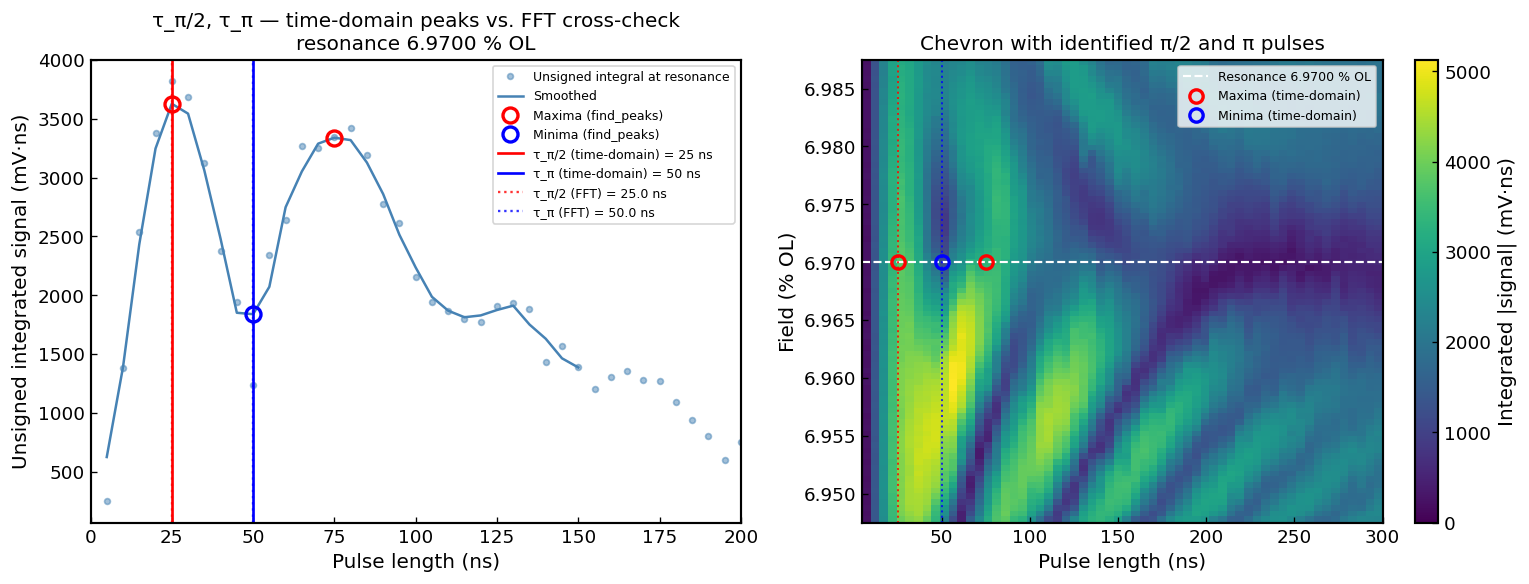

────────────────────────────────────────────────────────────
  τ_π/2 = 25 ns   (time-domain, primary)
  τ_π   = 50 ns   (time-domain, primary)
  FFT cross-check: f_Rabi = 20.0 MHz (δf = 3.3 MHz, resolution-limited — same issue as the T2* linewidth method in 3.2)
  Methods agree within the 5 ns measurement grid spacing.
────────────────────────────────────────────────────────────


In [17]:
# ── π and π/2 pulse calibration: time-domain peaks vs. FFT cross-check ─
#
# Primary method: scipy.signal.find_peaks directly on the on-resonance
# 1D cut. This reads pulse lengths straight off the measured grid
# (5 ns steps) with no Fourier-resolution penalty, so it is the more
# precise method here.
#
# Cross-check: f_Rabi from the FFT peak of the background-subtracted
# signal, converted analytically to tau_pi/2 = 1/(2 f_Rabi) and
# tau_pi = 1/f_Rabi. The FFT has frequency resolution
# delta_f = 1/T_window (same resolution limit that made the T2*
# linewidth method fail in Section 3.2), so this is reported as a
# consistency check, not the primary measurement.

from scipy.signal import find_peaks
from scipy.ndimage import uniform_filter1d

# ── On-resonance 1D cut (uses res_OL / res_idx set once in Section 2) ─
t_mask_chev  = (t_ns >= dead_ns) & (t_ns <= 370)
cut_unsigned = np.sum(np.abs(signal[res_idx, :, :][:, t_mask_chev]), axis=1)
cut_smooth   = uniform_filter1d(cut_unsigned.astype(float), size=3)

# ══════════════════════════════════════════════════════════════
# Primary method: time-domain peak finding
# ══════════════════════════════════════════════════════════════

early_mask = pulse_ns <= 150   # Rabi fringes are clearly visible here
cut_early  = cut_smooth[early_mask]
pls_early  = pulse_ns[early_mask]

peak_indices, _ = find_peaks(
    cut_early, prominence=np.std(cut_early) * 0.5, distance=3
)
min_indices, _ = find_peaks(
    -cut_early, prominence=np.std(cut_early) * 0.5, distance=3
)

peak_pulses = pls_early[peak_indices]
min_pulses  = pls_early[min_indices]

# Fallback only used if peak-finding fails outright (e.g. too noisy a
# dataset) — 25/50 ns matches the FFT-confirmed values used throughout
# the rest of the notebook, not an independent guess.
FALLBACK_PI2 = 25.0   # ns
FALLBACK_PI  = 50.0   # ns

tau_pi2_peaks = float(peak_pulses[0]) if len(peak_pulses) > 0 else FALLBACK_PI2
tau_pi_peaks  = float(min_pulses[0])  if len(min_pulses)  > 0 else FALLBACK_PI

if len(peak_pulses) == 0:
    print(f'No maximum found by find_peaks — using fallback τ_π/2 = {FALLBACK_PI2:.0f} ns')
if len(min_pulses) == 0:
    print(f'No minimum found by find_peaks — using fallback τ_π = {FALLBACK_PI:.0f} ns')

print(f'Time-domain (primary):  τ_π/2 = {tau_pi2_peaks:.0f} ns,  τ_π = {tau_pi_peaks:.0f} ns')

# ══════════════════════════════════════════════════════════════
# Cross-check: FFT of background-subtracted signal
# ══════════════════════════════════════════════════════════════

SMOOTH_WIDTH = 12   # pts — must stay below one Rabi period in points

rabi_map_abs = np.sum(np.abs(signal[:, :, t_mask_chev]), axis=2).astype(float)
rabi_bg      = uniform_filter1d(rabi_map_abs[res_idx, :], size=SMOOTH_WIDTH)
rabi_hpf     = rabi_map_abs[res_idx, :] - rabi_bg

pulse_arr = np.asarray(pulse_ns, dtype=float)
dp        = float(np.median(np.diff(pulse_arr)))
fft_freqs = np.fft.rfftfreq(len(pulse_arr), d=dp * 1e-9) * 1e-6   # MHz
fft_amp   = np.abs(np.fft.rfft(rabi_hpf))
fft_amp[0] = 0

f_rabi_fft  = float(fft_freqs[1:][np.argmax(fft_amp[1:])])
delta_f_fft = float(fft_freqs[1] - fft_freqs[0])   # frequency resolution = 1/T_window

tau_pi2_fft = 1e3 / (2.0 * f_rabi_fft)   # ns
tau_pi_fft  = 1e3 / (1.0 * f_rabi_fft)   # ns

print(f'FFT (cross-check):      τ_π/2 = {tau_pi2_fft:.1f} ns,  τ_π = {tau_pi_fft:.1f} ns'
      f'   (f_Rabi = {f_rabi_fft:.1f} MHz, δf = {delta_f_fft:.1f} MHz)')

agree_pi2 = abs(tau_pi2_peaks - tau_pi2_fft)
agree_pi  = abs(tau_pi_peaks  - tau_pi_fft)
print(f'\nAgreement: Δτ_π/2 = {agree_pi2:.1f} ns,  Δτ_π = {agree_pi:.1f} ns'
      f'  (grid step = {dp:.0f} ns)')

# ══════════════════════════════════════════════════════════════
# Figure: 1D cut with both methods, plus the chevron map
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: 1D cut, both methods marked --
ax = axes[0]
ax.plot(pulse_ns, cut_unsigned, 'o', ms=3.5, color='steelblue', alpha=0.5,
        label='Unsigned integral at resonance')
ax.plot(pls_early, cut_early, '-', color='steelblue', lw=1.5, label='Smoothed')

ax.plot(peak_pulses, cut_early[peak_indices], 'o', ms=9, color='red',
        markerfacecolor='none', markeredgewidth=2, label='Maxima (find_peaks)')
ax.plot(min_pulses, cut_early[min_indices], 'o', ms=9, color='blue',
        markerfacecolor='none', markeredgewidth=2, label='Minima (find_peaks)')

ax.axvline(tau_pi2_peaks, color='red',  lw=1.6, ls='-',
           label=f'τ_π/2 (time-domain) = {tau_pi2_peaks:.0f} ns')
ax.axvline(tau_pi_peaks,  color='blue', lw=1.6, ls='-',
           label=f'τ_π (time-domain) = {tau_pi_peaks:.0f} ns')
ax.axvline(tau_pi2_fft, color='red',  lw=1.4, ls=':', alpha=0.8,
           label=f'τ_π/2 (FFT) = {tau_pi2_fft:.1f} ns')
ax.axvline(tau_pi_fft,  color='blue', lw=1.4, ls=':', alpha=0.8,
           label=f'τ_π (FFT) = {tau_pi_fft:.1f} ns')

ax.set_xlim(0, 200)
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Unsigned integrated signal (mV·ns)')
ax.set_title(f'τ_π/2, τ_π — time-domain peaks vs. FFT cross-check\nresonance {res_OL:.4f} % OL')
ax.legend(fontsize=7.5)

# -- Right: chevron with both methods' markers --
unsigned_map = rabi_map_abs

ax = axes[1]
im = ax.imshow(unsigned_map, aspect='auto', origin='lower',
               extent=[pulse_ns[0], pulse_ns[-1], OL_axis[0], OL_axis[-1]],
               cmap='viridis', vmin=0, vmax=np.max(unsigned_map))
ax.axhline(res_OL, color='white', lw=1.3, ls='--', label=f'Resonance {res_OL:.4f} % OL')
ax.plot(peak_pulses, [res_OL]*len(peak_pulses), 'o', ms=8, color='red',
        markerfacecolor='none', markeredgewidth=2, label='Maxima (time-domain)')
ax.plot(min_pulses, [res_OL]*len(min_pulses), 'o', ms=8, color='blue',
        markerfacecolor='none', markeredgewidth=2, label='Minima (time-domain)')
ax.axvline(tau_pi2_fft, color='red',  lw=1.2, ls=':', alpha=0.8)
ax.axvline(tau_pi_fft,  color='blue', lw=1.2, ls=':', alpha=0.8)
fig.colorbar(im, ax=ax, label='Integrated |signal| (mV·ns)')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Field (% OL)')
ax.set_title('Chevron with identified π/2 and π pulses')
ax.legend(fontsize=7.5, loc='upper right')

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════
print('─' * 60)
print(f'  τ_π/2 = {tau_pi2_peaks:.0f} ns   (time-domain, primary)')
print(f'  τ_π   = {tau_pi_peaks:.0f} ns   (time-domain, primary)')
print(f'  FFT cross-check: f_Rabi = {f_rabi_fft:.1f} MHz (δf = {delta_f_fft:.1f} MHz, '
      f'resolution-limited — same issue as the T2* linewidth method in 3.2)')
print(f'  Methods agree within the {dp:.0f} ns measurement grid spacing.')
print('─' * 60)

# Carry forward: these are the values used in every later cell
TAU_PI2 = tau_pi2_peaks
TAU_PI  = tau_pi_peaks


### Background subtraction

- Raw signal has a slow background (transient coupling) that dominates the raw FFT (peak ≈3.3 MHz, not $f_{\rm Rabi}$) — confirmed explicitly below.
- Removed via moving-average high-pass filter, `SMOOTH_WIDTH = 12` pts = 60 ns.
- Must stay below one Rabi period in points, else it distorts the signal and produces an apparent doubled frequency.

FFT peak of RAW unsigned (Hann):    3.33 MHz
  → τ_π/2 = 75.0 ns
  → τ_π   = 150.0 ns

FFT peak of RAW unsigned (no window): 3.33 MHz
  → τ_π/2 = 75.0 ns
  → τ_π   = 150.0 ns


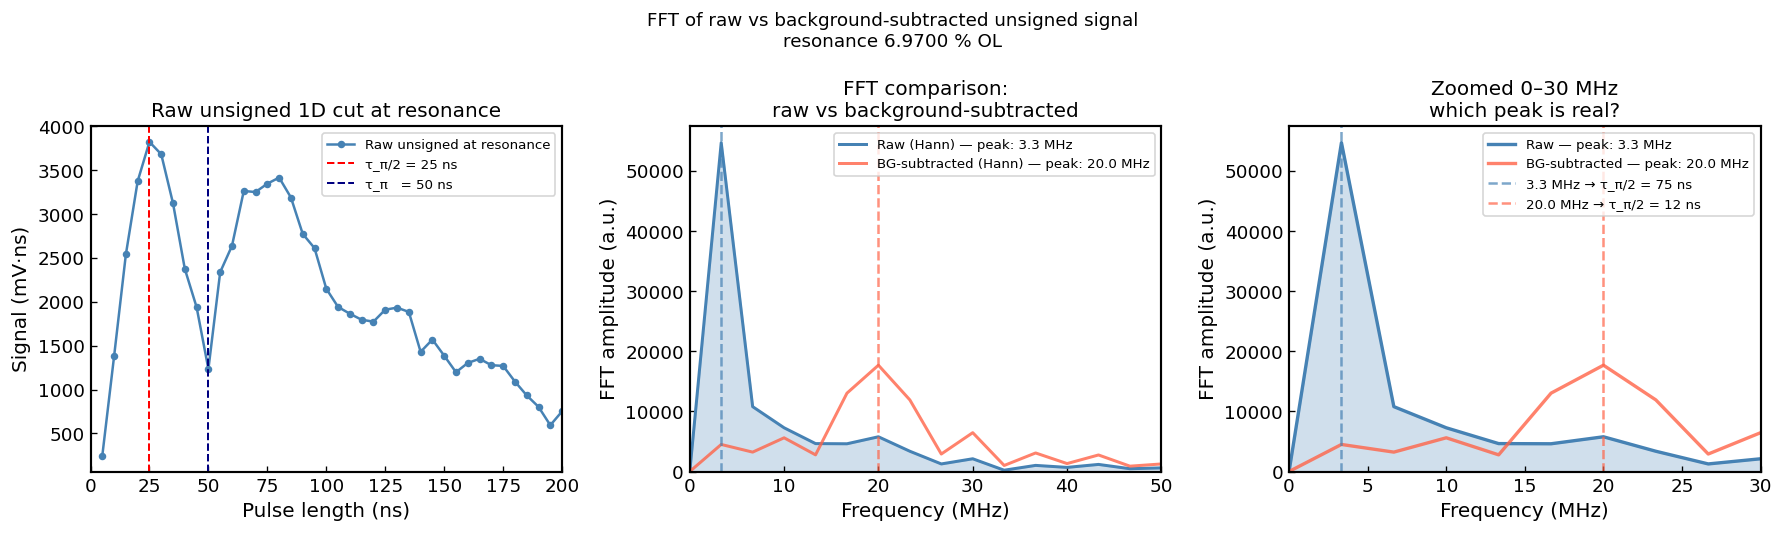


Key question:
  Raw FFT peak     = 3.3 MHz → τ_π = 150 ns
  BG-subtr. peak   = 20.0 MHz → τ_π = 25 ns
  Ratio BG/raw     = 6.00
  Visual τ_π/2     = 25 ns → f_Rabi = 10 MHz
  If raw FFT = 10 MHz → BG subtr. found 2× harmonic (expected!)
  If raw FFT = 20 MHz → true f_Rabi = 20 MHz, τ_π/2 = 12.5 ns


In [18]:
# ── FFT of raw unsmoothed unsigned signal at resonance ────────

cut_raw_u = rabi_map_abs[res_idx, :].astype(float)

# Hann window to reduce spectral leakage
hann      = np.hanning(len(cut_raw_u))
hann_norm = hann / np.mean(hann)

fft_raw   = np.abs(np.fft.rfft(cut_raw_u * hann_norm))
fft_raw[0]= 0   # zero DC
fft_f_raw = np.fft.rfftfreq(len(cut_raw_u), d=5e-9) * 1e-6  # MHz

# Also FFT without window for comparison
fft_raw_nowin    = np.abs(np.fft.rfft(cut_raw_u))
fft_raw_nowin[0] = 0

# Find peak
peak_f_raw = float(fft_f_raw[1:][np.argmax(fft_raw[1:])])
print(f'FFT peak of RAW unsigned (Hann):    {peak_f_raw:.2f} MHz')
print(f'  → τ_π/2 = {1/(4*peak_f_raw)*1e3:.1f} ns')
print(f'  → τ_π   = {1/(2*peak_f_raw)*1e3:.1f} ns')

peak_f_nowin = float(fft_f_raw[1:][np.argmax(fft_raw_nowin[1:])])
print(f'\nFFT peak of RAW unsigned (no window): {peak_f_nowin:.2f} MHz')
print(f'  → τ_π/2 = {1/(4*peak_f_nowin)*1e3:.1f} ns')
print(f'  → τ_π   = {1/(2*peak_f_nowin)*1e3:.1f} ns')

# ── Plot: raw FFT vs background-subtracted FFT ────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Panel 1: raw unsigned 1D cut
ax = axes[0]
ax.plot(pulse_arr, cut_raw_u, 'o-', ms=3.5, color='steelblue',
        label='Raw unsigned at resonance')
ax.axvline(25, color='red',  lw=1.2, ls='--', label='τ_π/2 = 25 ns')
ax.axvline(50, color='navy', lw=1.2, ls='--', label='τ_π   = 50 ns')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Signal (mV·ns)')
ax.set_title('Raw unsigned 1D cut at resonance')
ax.set_xlim(0, 200)
ax.legend(fontsize=8)

# Panel 2: FFT of raw vs background-subtracted
ax = axes[1]
ax.fill_between(fft_f_raw, fft_raw, alpha=0.25, color='steelblue')
ax.plot(fft_f_raw, fft_raw, '-', lw=1.8, color='steelblue',
        label=f'Raw (Hann) — peak: {peak_f_raw:.1f} MHz')

# Overlay background-subtracted FFT for comparison
# ── Recompute background-subtracted map if not already defined ──
try:
    rabi_map_hpf
except NameError:
    SMOOTH_WIDTH_FALLBACK = 12   # pts, same value used in Section 4
    t_mask_fallback = (t_ns >= 65) & (t_ns <= 370)
    rabi_map_abs_fallback = np.sum(np.abs(signal[:, :, t_mask_fallback]), axis=2).astype(float)
    rabi_map_bg_fallback  = uniform_filter1d(rabi_map_abs_fallback, size=SMOOTH_WIDTH_FALLBACK, axis=1)
    rabi_map_hpf = rabi_map_abs_fallback - rabi_map_bg_fallback

# Overlay background-subtracted FFT for comparison
rabi_res_hpf = rabi_map_hpf[res_idx, :].astype(float)
rabi_res_hpf = rabi_map_hpf[res_idx, :].astype(float)
hann2        = np.hanning(len(rabi_res_hpf))
hann2_norm   = hann2 / np.mean(hann2)
fft_hpf      = np.abs(np.fft.rfft(rabi_res_hpf * hann2_norm))
fft_hpf[0]  = 0
f_hpf_peak  = float(fft_f_raw[1:][np.argmax(fft_hpf[1:])])

ax.plot(fft_f_raw, fft_hpf, '-', lw=1.8, color='tomato', alpha=0.8,
        label=f'BG-subtracted (Hann) — peak: {f_hpf_peak:.1f} MHz')

ax.axvline(peak_f_raw,  color='steelblue', lw=1.5, ls='--', alpha=0.7)
ax.axvline(f_hpf_peak,  color='tomato',    lw=1.5, ls='--', alpha=0.7)
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('FFT amplitude (a.u.)')
ax.set_xlim(0, 50)
ax.set_ylim(bottom=0)
ax.set_title('FFT comparison:\nraw vs background-subtracted')
ax.legend(fontsize=8)

# Panel 3: zoom on 0-30 MHz
ax = axes[2]
show = fft_f_raw <= 30
ax.fill_between(fft_f_raw[show], fft_raw[show],
                alpha=0.25, color='steelblue')
ax.plot(fft_f_raw[show], fft_raw[show],
        '-', lw=2, color='steelblue',
        label=f'Raw — peak: {peak_f_raw:.1f} MHz')
ax.plot(fft_f_raw[show], fft_hpf[show],
        '-', lw=2, color='tomato', alpha=0.8,
        label=f'BG-subtracted — peak: {f_hpf_peak:.1f} MHz')
ax.axvline(peak_f_raw, color='steelblue', lw=1.5, ls='--', alpha=0.7,
           label=f'{peak_f_raw:.1f} MHz → τ_π/2 = {1/(4*peak_f_raw)*1e3:.0f} ns')
ax.axvline(f_hpf_peak, color='tomato',    lw=1.5, ls='--', alpha=0.7,
           label=f'{f_hpf_peak:.1f} MHz → τ_π/2 = {1/(4*f_hpf_peak)*1e3:.0f} ns')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('FFT amplitude (a.u.)')
ax.set_xlim(0, 30)
ax.set_ylim(bottom=0)
ax.set_title('Zoomed 0–30 MHz\nwhich peak is real?')
ax.legend(fontsize=8)

plt.suptitle(f'FFT of raw vs background-subtracted unsigned signal\n'
             f'resonance {res_OL:.4f} % OL', fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nKey question:')
print(f'  Raw FFT peak     = {peak_f_raw:.1f} MHz → τ_π = {1/(2*peak_f_raw)*1e3:.0f} ns')
print(f'  BG-subtr. peak   = {f_hpf_peak:.1f} MHz → τ_π = {1/(2*f_hpf_peak)*1e3:.0f} ns')
print(f'  Ratio BG/raw     = {f_hpf_peak/peak_f_raw:.2f}')
print(f'  Visual τ_π/2     = 25 ns → f_Rabi = 10 MHz')
print(f'  If raw FFT = 10 MHz → BG subtr. found 2× harmonic (expected!)')
print(f'  If raw FFT = 20 MHz → true f_Rabi = 20 MHz, τ_π/2 = 12.5 ns')

### 4.1  $T_{\rm Rabi}$ — accuracy check

Measured once, here, by combining two independent estimates:
- an exponential fit to the Hilbert envelope of the band-pass-filtered signal, repeated over several candidate fit windows to quantify sensitivity to that choice;
- a direct fit of the raw on-resonance signal to a damped $\sin^2$ with $f_{\rm Rabi}$ fixed.

The combined result, `T_RABI_BEST`, is used as a **fixed** input in every later cell in this section, so all figures agree on the same decay time rather than each silently re-deriving its own. As elsewhere, $T_{\rm Rabi} \leq T_2^*$, since it includes extra dephasing from $B_1$ inhomogeneity across the sample — different spins see slightly different $\Omega_R$, analogous to inhomogeneous broadening in the FID.

f_Rabi (FFT) = 20.00 MHz


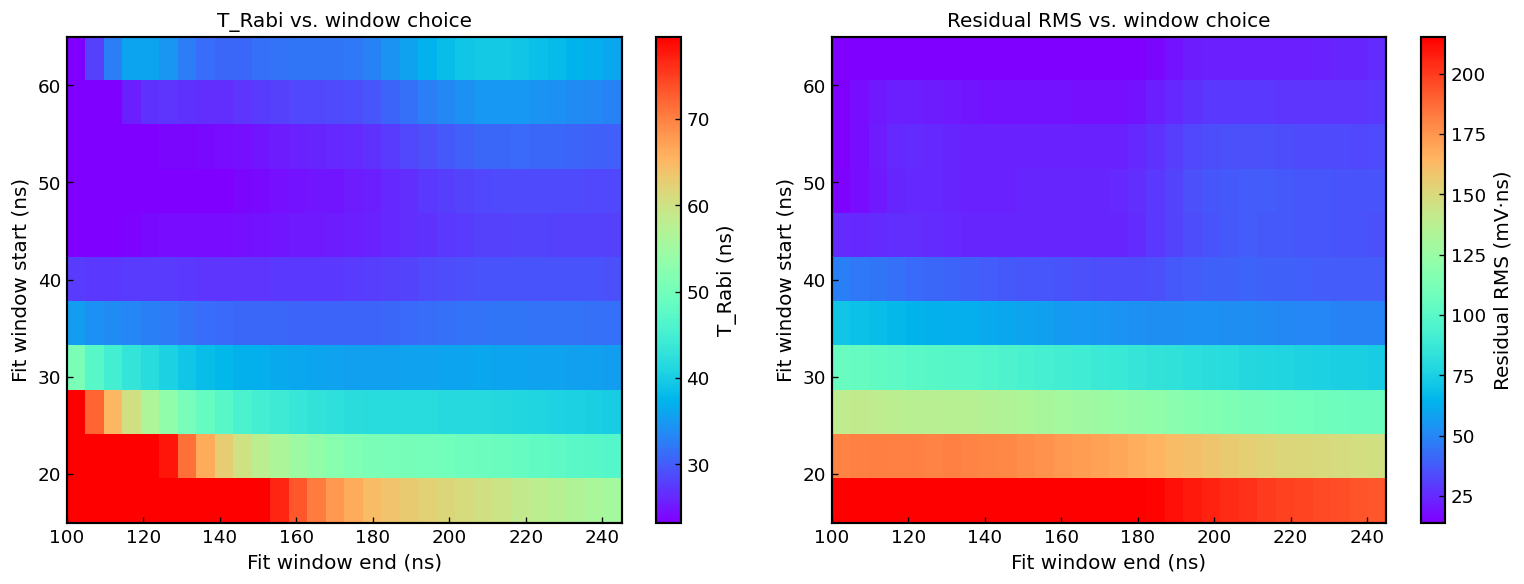

Median T_Rabi across all windows : 31.8 ns
Std of T_Rabi across all windows : 50.6 ns

Best window   : 65 – 175 ns
T_Rabi (best)  : 32.3 ns
Residual RMS   : 12.233 mV·ns
Systematic uncertainty from window choice: ± 50.6 ns

Direct fit to raw signal (f_Rabi fixed at 20.0 MHz):
  T_Rabi = 86.3 ± 19.2 ns
  phase  = -0.167 rad  (0 = no shift from nominal τ_π/2)

── Best estimate ──────────────────────────────
  T_RABI_BEST = 59.3 ± 54.2 ns
  (envelope grid: 32.3 ns,  direct fit: 86.3 ns)
  Q = T_RABI_BEST / τ_π = 1.19


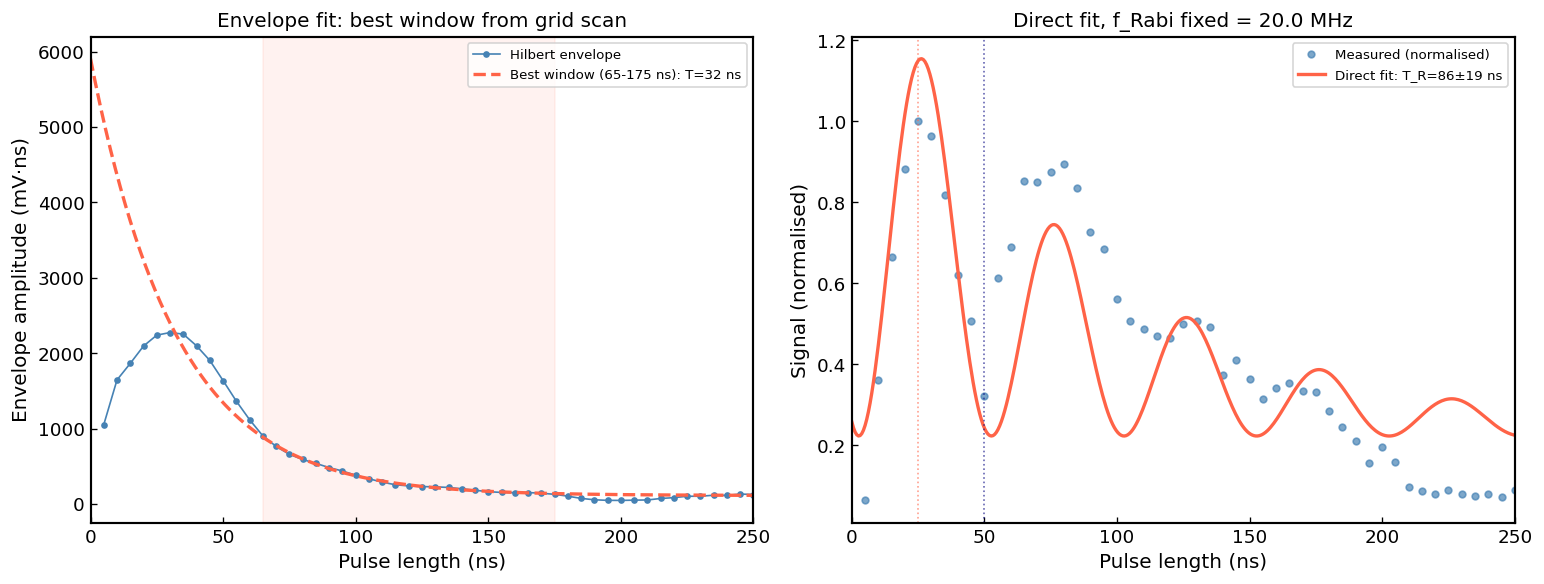

In [31]:
## T_Rabi decay-time determination — accuracy check
#
# Goal: get the most reliable T_Rabi (decay time of the Rabi oscillation envelope) by (1) fitting the Hilbert envelope over a 2D grid of candidate fit windows — same approach as the T2* window scan in
# Section 3.1 — to find the window that minimises residual RMS while staying close to the grid median, and (2) cross-checking against a direct fit of the raw on-resonance signal to a damped sin^2 with
# f_Rabi fixed.
#
# Output: T_RABI_BEST, used downstream as the fixed decay time in the 4-panel Rabi oscillation figure.

# ══════════════════════════════════════════════════════════════
# Parameters
# ══════════════════════════════════════════════════════════════
SMOOTH_WIDTH = 12     # pts — background subtraction (same as elsewhere)
BW_FACTOR    = 0.5    # band-pass bandwidth = ± BW_FACTOR * f_Rabi
TAU_PI2      = 25.0   # ns — confirmed from chevron
TAU_PI       = 50.0   # ns

T_GUESS      = 50.0   # ns — only used as the curve_fit starting guess,
                       #      not a measured value

# ══════════════════════════════════════════════════════════════
# Recompute dependencies
# ══════════════════════════════════════════════════════════════
dead_ns     = 65
t_mask_rabi = (t_ns >= dead_ns) & (t_ns <= 370)

try:
    rabi_map_abs
except NameError:
    rabi_map_abs = np.sum(np.abs(signal[:, :, t_mask_rabi]), axis=2).astype(float)

rabi_map_bg  = uniform_filter1d(rabi_map_abs, size=SMOOTH_WIDTH, axis=1)
rabi_map_hpf = rabi_map_abs - rabi_map_bg

pulse_arr = np.asarray(pulse_ns, dtype=float)
dp        = float(np.median(np.diff(pulse_arr)))

rabi_res_hpf = rabi_map_hpf[res_idx, :].astype(float)
cut_raw      = rabi_map_abs[res_idx, :].astype(float)
cut_raw_norm = cut_raw / np.max(cut_raw)

# f_Rabi from FFT (same method used elsewhere in the notebook)
fft_freqs = np.fft.rfftfreq(len(pulse_arr), d=dp * 1e-9) * 1e-6
fft_amp   = np.abs(np.fft.rfft(rabi_res_hpf))
fft_amp[0] = 0
F_RABI = float(fft_freqs[1:][np.argmax(fft_amp[1:])])

print(f'f_Rabi (FFT) = {F_RABI:.2f} MHz')

# ══════════════════════════════════════════════════════════════
# Band-pass filter + Hilbert envelope (same signal used in all windows)
# ══════════════════════════════════════════════════════════════
nyq  = 0.5 / (dp * 1e-9) * 1e-6
low  = max((F_RABI - F_RABI * BW_FACTOR) / nyq, 0.01)
high = min((F_RABI + F_RABI * BW_FACTOR) / nyq, 0.99)

b, a      = butter(2, [low, high], btype='band')
rabi_filt = filtfilt(b, a, rabi_res_hpf)
env_rabi  = np.abs(hilbert(rabi_filt))

def exp_decay(t, A, T_Rabi, C):
    return A * np.exp(-t / T_Rabi) + C

# ══════════════════════════════════════════════════════════════
# Fit the envelope over a 2D grid of (start, end) windows
# — same approach as the T2* window scan in Section 3.1
# ══════════════════════════════════════════════════════════════
t_starts = np.arange(15.0, 70.0, 5.0)     # ns
t_ends   = np.arange(100.0, 250.0, 5.0)  # ns

T_grid     = np.full((len(t_starts), len(t_ends)), np.nan)
T_err_grid = np.full((len(t_starts), len(t_ends)), np.nan)
resid_grid = np.full((len(t_starts), len(t_ends)), np.nan)

for i, start in enumerate(t_starts):
    for j, end in enumerate(t_ends):
        if end - start < 30:          # require a minimally useful window
            continue
        mask = (pulse_arr >= start) & (pulse_arr <= end)
        if mask.sum() < 6:
            continue

        A0 = float(env_rabi[mask][0])
        try:
            popt, pcov = curve_fit(
                exp_decay, pulse_arr[mask], env_rabi[mask],
                p0=[A0, T_GUESS, 0.0],
                bounds=([0., 5., -np.inf], [np.inf, 500., np.inf]),
                maxfev=50000
            )
            T_grid[i, j]     = popt[1]
            T_err_grid[i, j] = float(np.sqrt(np.diag(pcov))[1])
            resid_grid[i, j] = float(np.std(env_rabi[mask] - exp_decay(pulse_arr[mask], *popt)))
        except Exception:
            pass

# ── Plot: T_Rabi and residual RMS across the (start, end) grid ──
fig0, axes0 = plt.subplots(1, 2, figsize=(13, 5))

im0 = axes0[0].imshow(T_grid, aspect='auto', origin='lower',
                       extent=[t_ends[0], t_ends[-1], t_starts[0], t_starts[-1]],
                       cmap='rainbow',
                       vmin=np.nanpercentile(T_grid, 5), vmax=np.nanpercentile(T_grid, 95))
fig0.colorbar(im0, ax=axes0[0], label='T_Rabi (ns)')
axes0[0].set_xlabel('Fit window end (ns)')
axes0[0].set_ylabel('Fit window start (ns)')
axes0[0].set_title('T_Rabi vs. window choice')

im1 = axes0[1].imshow(resid_grid, aspect='auto', origin='lower',
                       extent=[t_ends[0], t_ends[-1], t_starts[0], t_starts[-1]],
                       cmap='rainbow',
                       vmin=np.nanpercentile(resid_grid, 5), vmax=np.nanpercentile(resid_grid, 95))
fig0.colorbar(im1, ax=axes0[1], label='Residual RMS (mV·ns)')
axes0[1].set_xlabel('Fit window end (ns)')
axes0[1].set_ylabel('Fit window start (ns)')
axes0[1].set_title('Residual RMS vs. window choice')

plt.tight_layout()
plt.show()

print(f'Median T_Rabi across all windows : {np.nanmedian(T_grid):.1f} ns')
print(f'Std of T_Rabi across all windows : {np.nanstd(T_grid):.1f} ns')

# ── Select the best window: lowest residual among windows whose
#    T_Rabi is within 5 ns of the grid median (same criterion as 3.1) ─
target_T    = np.nanmedian(T_grid)
stable_mask = np.abs(T_grid - target_T) < 5.0
resid_masked = np.where(stable_mask, resid_grid, np.nan)

best_ij = np.unravel_index(np.nanargmin(resid_masked), resid_masked.shape)
best_start      = t_starts[best_ij[0]]
best_end        = t_ends[best_ij[1]]
T_envelope_mean = float(T_grid[best_ij])
T_envelope_std  = float(np.nanstd(T_grid))   # spread across the whole grid = systematic

print(f'\nBest window   : {best_start:.0f} – {best_end:.0f} ns')
print(f'T_Rabi (best)  : {T_envelope_mean:.1f} ns')
print(f'Residual RMS   : {resid_grid[best_ij]:.3f} mV·ns')
print(f'Systematic uncertainty from window choice: ± {T_envelope_std:.1f} ns')

# ══════════════════════════════════════════════════════════════
# Cross-check: direct fit of raw on-resonance signal,
# f_Rabi FIXED from the FFT value above, only (scale, T_R, offset, phase) free
# ══════════════════════════════════════════════════════════════
beta = np.pi * F_RABI * 1e-3   # rad/ns

def rabi_model_direct(tau, scale, T_R, offset, phase):
    tau = np.asarray(tau, dtype=float)
    return scale * np.sin(beta * tau + phase)**2 * np.exp(-tau / T_R) + offset

fit_mask_direct = pulse_arr >= 15.0

try:
    popt_direct, pcov_direct = curve_fit(
        rabi_model_direct,
        pulse_arr[fit_mask_direct], cut_raw_norm[fit_mask_direct],
        p0=[0.8, T_GUESS, 0.1, 0.0],
        bounds=([0., 5., 0., -np.pi], [2., 500., 1., np.pi]),
        maxfev=50000
    )
    scale_d, T_direct, off_d, phase_d = popt_direct
    T_direct_err = float(np.sqrt(np.diag(pcov_direct))[1])
    direct_ok = True
    print(f'\nDirect fit to raw signal (f_Rabi fixed at {F_RABI:.1f} MHz):')
    print(f'  T_Rabi = {T_direct:.1f} ± {T_direct_err:.1f} ns')
    print(f'  phase  = {phase_d:.3f} rad  (0 = no shift from nominal τ_π/2)')
except Exception as e:
    print(f'Direct fit failed: {e}')
    direct_ok = False
    T_direct = T_direct_err = np.nan

# ══════════════════════════════════════════════════════════════
# Combine envelope and direct estimates into one best value
# ══════════════════════════════════════════════════════════════
if direct_ok:
    T_RABI_BEST = float(np.mean([T_envelope_mean, T_direct]))
    T_RABI_BEST_ERR = float(np.sqrt(T_envelope_std**2 + T_direct_err**2))
else:
    T_RABI_BEST = T_envelope_mean
    T_RABI_BEST_ERR = T_envelope_std

print(f'\n── Best estimate ──────────────────────────────')
print(f'  T_RABI_BEST = {T_RABI_BEST:.1f} ± {T_RABI_BEST_ERR:.1f} ns')
print(f'  (envelope grid: {T_envelope_mean:.1f} ns,  direct fit: '
      f'{T_direct:.1f} ns)' if direct_ok else '')
print(f'  Q = T_RABI_BEST / τ_π = {T_RABI_BEST / TAU_PI:.2f}')

# ══════════════════════════════════════════════════════════════
# Diagnostic figure: envelope + best-window fit, plus direct fit overlay
# ══════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(pulse_arr, env_rabi, 'o-', ms=3, color='steelblue', lw=1,
         label='Hilbert envelope')

t_dense = np.linspace(0, 250, 400)

mask_best = (pulse_arr >= best_start) & (pulse_arr <= best_end)
popt_best, _ = curve_fit(
    exp_decay, pulse_arr[mask_best], env_rabi[mask_best],
    p0=[float(env_rabi[mask_best][0]), T_envelope_mean, 0.0],
    bounds=([0., 5., -np.inf], [np.inf, 500., np.inf]), maxfev=50000
)
ax1.plot(t_dense, exp_decay(t_dense, *popt_best), '--', color='tomato', lw=2,
          label=f'Best window ({best_start:.0f}-{best_end:.0f} ns): T={T_envelope_mean:.0f} ns')
ax1.axvspan(best_start, best_end, alpha=0.08, color='tomato')

ax1.set_xlabel('Pulse length (ns)')
ax1.set_ylabel('Envelope amplitude (mV·ns)')
ax1.set_title('Envelope fit: best window from grid scan')
ax1.legend(fontsize=8)
ax1.set_xlim(0, 250)

ax2.plot(pulse_arr, cut_raw_norm, 'o', ms=4, color='steelblue', alpha=0.7,
         label='Measured (normalised)')
if direct_ok:
    ax2.plot(t_dense, rabi_model_direct(t_dense, *popt_direct), '-',
              color='tomato', lw=2,
              label=f'Direct fit: T_R={T_direct:.0f}±{T_direct_err:.0f} ns')
ax2.axvline(TAU_PI2, color='tomato', ls=':', lw=1, alpha=0.6)
ax2.axvline(TAU_PI,  color='navy',   ls=':', lw=1, alpha=0.6)
ax2.set_xlabel('Pulse length (ns)')
ax2.set_ylabel('Signal (normalised)')
ax2.set_title(f'Direct fit, f_Rabi fixed = {F_RABI:.1f} MHz')
ax2.legend(fontsize=8)
ax2.set_xlim(0, 250)

plt.tight_layout()
plt.show()

### 4.2  Signed vs. unsigned — diagnostic

Visual confirmation that background subtraction + FFT peak detection
gives a self-consistent picture for the unsigned signal (the one used
downstream). The signed signal is shown alongside purely as an
independent reference — it is choppier and less clear for this
dataset, and is not used in any later cell.

Unsigned FFT peak: 20.00 MHz  → τ_π/2 = 12.5 ns, τ_π = 25.0 ns
Signed   FFT peak: 50.00 MHz  (reference only, expected ≈ f_rabi_u/2)

Physics check: background-subtracted unsigned signal ≈ -cos(Ω_R·τ)·exp(-τ/T_R)
because sin²(x) = (1-cos(2x))/2, and background subtraction removes the constant 1/2 term.
→ the unsigned FFT finds f_Rabi directly (not 2×f_Rabi).
Signed signal ≈ sin(Ω_R·τ)·exp(-τ/T_R), period = 2·τ_π → half the unsigned frequency.
Fitted unsigned phase: -11.0°
Fitted signed   phase: -173.0°  (reference only)


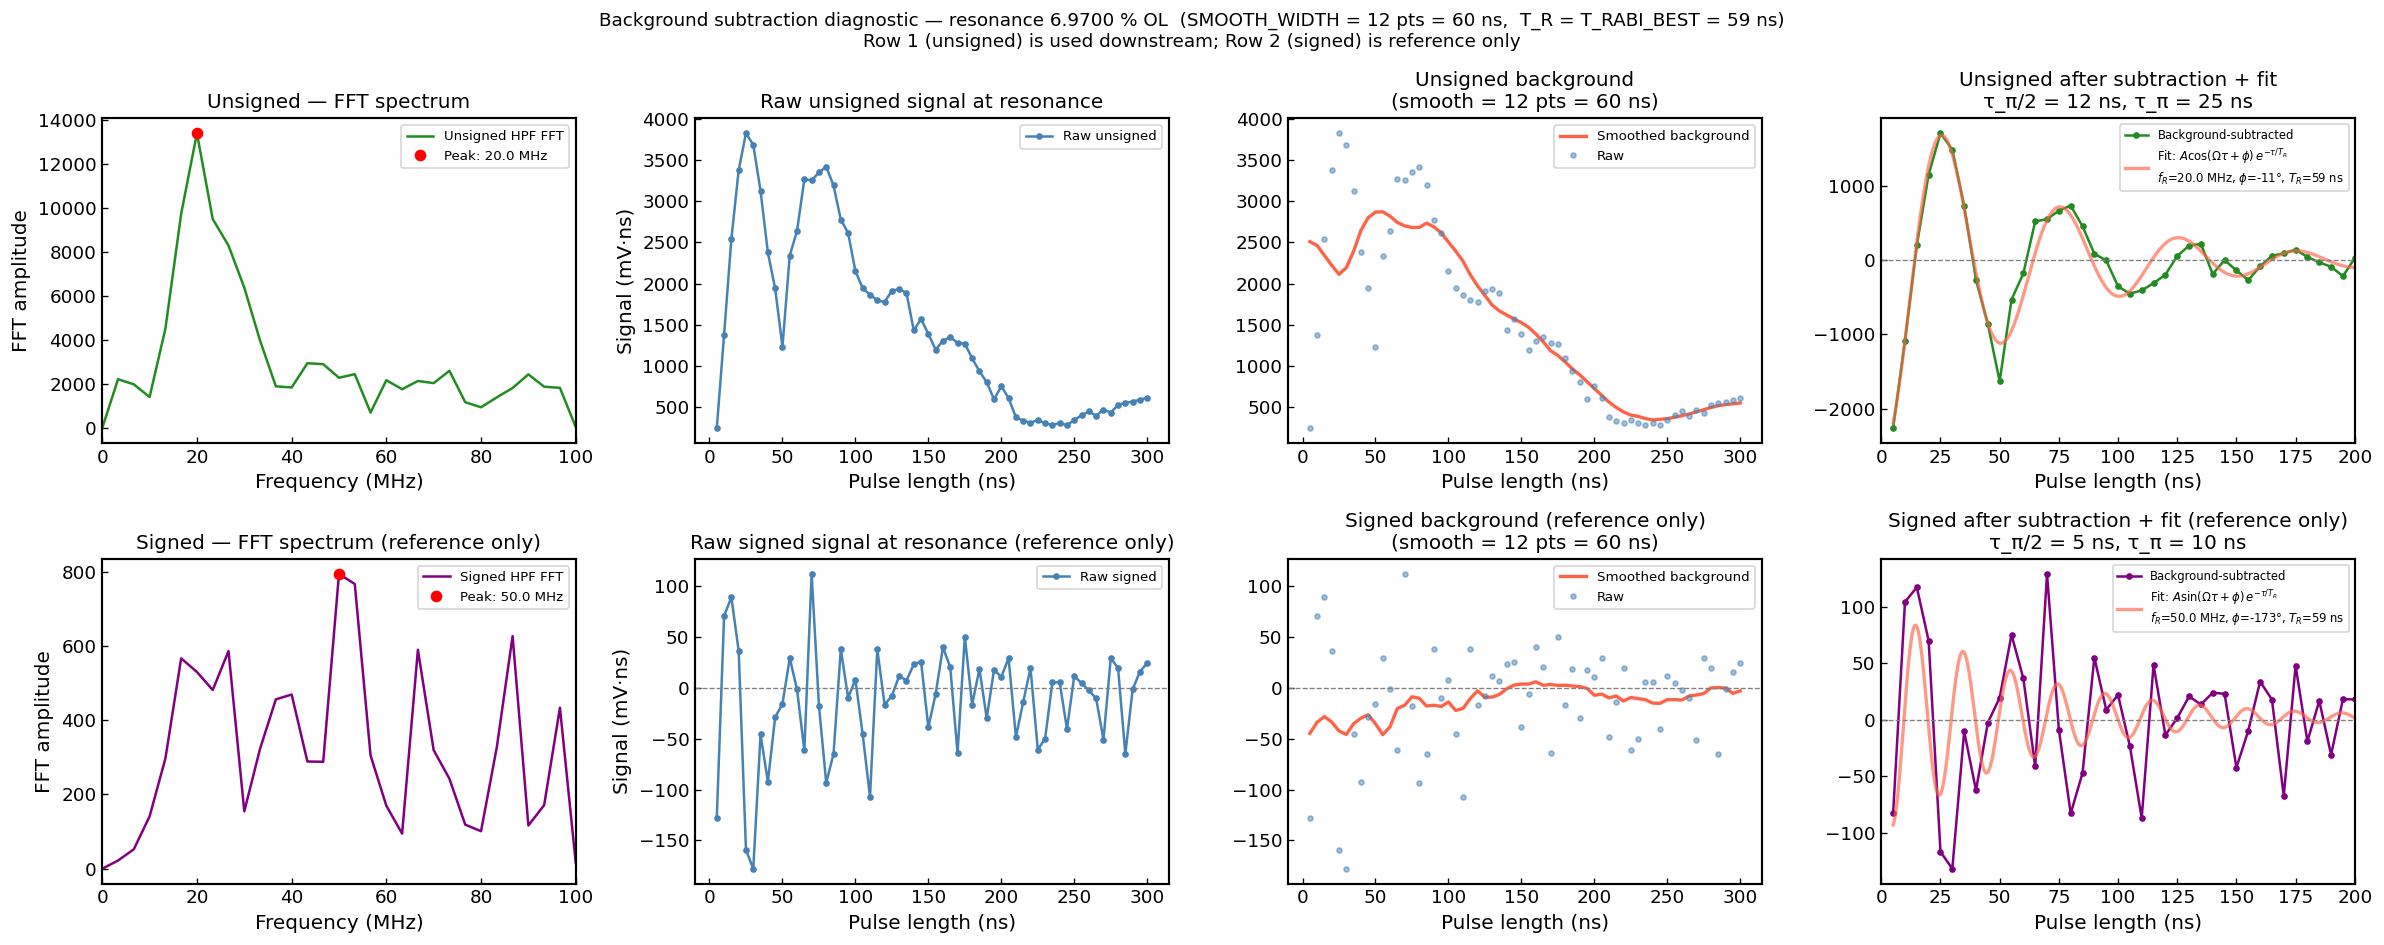


── Summary ───────────────────────────────────────────
  Unsigned FFT: 20.00 MHz  → τ_π/2 = 12.5 ns, τ_π = 25.0 ns
  Signed   FFT: 50.00 MHz  (reference only)
  T_RABI_BEST  = 59.3 ns
  SMOOTH_WIDTH = 12 pts = 60 ns


In [32]:
# ── Background subtraction diagnostic — unsigned + signed (reference) ─

# visual confirmation that background subtraction + FFT peak detection gives a self-consistent picture for the unsigned signal
# show the signed signal alongside purely as an independent reference/diagnostic — not used in any later cell (chevron fit, 4-panel figure, etc.).

# ── Recompute maps if not defined ─────────────────────────────
try:
    rabi_map_abs
except NameError:
    dead_ns      = 65
    t_mask_rabi  = (t_ns >= dead_ns) & (t_ns <= 370)
    rabi_map_abs = np.sum(np.abs(signal[:, :, t_mask_rabi]), axis=2).astype(float)
    print('rabi_map_abs recomputed')

try:
    rabi_map_signed
except NameError:
    dead_ns         = 65
    t_mask_rabi     = (t_ns >= dead_ns) & (t_ns <= 370)
    rabi_map_signed = np.sum(signal[:, :, t_mask_rabi], axis=2).astype(float)
    print('rabi_map_signed recomputed')

try:
    T_RABI_BEST
except NameError:
    print('WARNING: T_RABI_BEST not found — run the T_Rabi accuracy check '
          'cell first. Using a rough placeholder guess of 50 ns.')
    T_RABI_BEST = 50.0

# ── Axes ──────────────────────────────────────────────────────
pulse_ns_arr = np.asarray(pulse_ns, dtype=float)
dp_ns        = float(np.median(np.diff(pulse_ns_arr)))   # ns per step
fft_freqs    = np.fft.rfftfreq(len(pulse_ns_arr), d=dp_ns * 1e-9) * 1e-6   # MHz
tau_dense    = np.linspace(pulse_ns_arr[0], pulse_ns_arr[-1], 1000)

# ── Background subtraction ────────────────────────────────────
SMOOTH_WIDTH = 12   # points — must stay below one Rabi period in points

rabi_map_bg      = uniform_filter1d(rabi_map_abs, size=SMOOTH_WIDTH, axis=1)
rabi_map_hpf     = rabi_map_abs - rabi_map_bg

rabi_map_sig_bg  = uniform_filter1d(rabi_map_signed, size=SMOOTH_WIDTH, axis=1)
rabi_map_sig_hpf = rabi_map_signed - rabi_map_sig_bg

# ── FFT and peak detection (independent for unsigned and signed) ──
fft_map_hpf       = np.abs(np.fft.rfft(rabi_map_hpf, axis=1))
fft_map_hpf[:, 0] = 0
fft_map_sig_hpf       = np.abs(np.fft.rfft(rabi_map_sig_hpf, axis=1))
fft_map_sig_hpf[:, 0] = 0

peak_idx_u = 1 + np.argmax(fft_map_hpf[:, 1:], axis=1)
peak_idx_s = 1 + np.argmax(fft_map_sig_hpf[:, 1:], axis=1)

rabi_freq_unsigned = fft_freqs[peak_idx_u]
rabi_freq_signed   = fft_freqs[peak_idx_s]

f_rabi_u   = float(rabi_freq_unsigned[res_idx])
f_rabi_s   = float(rabi_freq_signed[res_idx])
peak_amp_u = float(fft_map_hpf[res_idx, peak_idx_u[res_idx]])
peak_amp_s = float(fft_map_sig_hpf[res_idx, peak_idx_s[res_idx]])

print(f'Unsigned FFT peak: {f_rabi_u:.2f} MHz  '
      f'→ τ_π/2 = {1/(4*f_rabi_u)*1e3:.1f} ns, τ_π = {1/(2*f_rabi_u)*1e3:.1f} ns')
print(f'Signed   FFT peak: {f_rabi_s:.2f} MHz  (reference only, expected ≈ f_rabi_u/2)')
print()
print('Physics check: background-subtracted unsigned signal ≈ -cos(Ω_R·τ)·exp(-τ/T_R)')
print('because sin²(x) = (1-cos(2x))/2, and background subtraction removes the constant 1/2 term.')
print('→ the unsigned FFT finds f_Rabi directly (not 2×f_Rabi).')
print('Signed signal ≈ sin(Ω_R·τ)·exp(-τ/T_R), period = 2·τ_π → half the unsigned frequency.')

# ── Phase fit: find phi minimising residual ───────────────────
# Unsigned: cos basis (background-subtracted unsigned ≈ cosine)
# Signed:   sin basis (signed signal ≈ sine)
FIT_MAX_NS   = 200.0
fit_mask_arr = pulse_ns_arr <= FIT_MAX_NS
phase_grid   = np.linspace(-np.pi, np.pi, 1441)

cut_u_hpf = rabi_map_hpf[res_idx, :].astype(float)
cut_s_hpf = rabi_map_sig_hpf[res_idx, :].astype(float)

def fit_phase_amplitude(data, tau_ns, omega, T_rabi_ns, trig='cos'):
    """
    Find phase, amplitude, and offset that best fit
        A * trig(omega*tau*1e-9 + phi) * exp(-tau/T_rabi_ns) + offset
    by least squares at each candidate phase on a grid.
    """
    y   = data[fit_mask_arr]
    t   = tau_ns[fit_mask_arr]
    env = np.exp(-t / T_rabi_ns)

    best_err, best_phi, best_A, best_off = np.inf, 0., 1., 0.
    for phi in phase_grid:
        if trig == 'cos':
            basis = np.cos(omega * t * 1e-9 + phi) * env
        else:
            basis = np.sin(omega * t * 1e-9 + phi) * env
        X = np.column_stack([basis, np.ones_like(basis)])
        coeffs, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
        A, off = coeffs
        err = float(np.mean((y - (A * basis + off))**2))
        if err < best_err:
            best_err, best_phi, best_A, best_off = err, phi, A, off

    return best_phi, best_A, best_off

phi_u, A_u, off_u = fit_phase_amplitude(
    cut_u_hpf, pulse_ns_arr, 2*np.pi * f_rabi_u * 1e6, T_RABI_BEST, trig='cos'
)
phi_s, A_s, off_s = fit_phase_amplitude(
    cut_s_hpf, pulse_ns_arr, 2*np.pi * f_rabi_s * 1e6, T_RABI_BEST, trig='sin'
)
print(f'Fitted unsigned phase: {np.degrees(phi_u):.1f}°')
print(f'Fitted signed   phase: {np.degrees(phi_s):.1f}°  (reference only)')

# ── Build smooth hypothetical curves ──────────────────────────
env_dense = np.exp(-tau_dense / T_RABI_BEST)
Omega_u_r = 2*np.pi * f_rabi_u * 1e6
Omega_s_r = 2*np.pi * f_rabi_s * 1e6

hypo_u_dense = A_u * np.cos(Omega_u_r * tau_dense * 1e-9 + phi_u) * env_dense + off_u
hypo_s_dense = A_s * np.sin(Omega_s_r * tau_dense * 1e-9 + phi_s) * env_dense + off_s

# ── Figure: 2 rows × 4 columns (row 1 = unsigned, row 2 = signed reference) ─
fft_xmax = min(fft_freqs[-1], max(50.0, 3.0 * max(f_rabi_u, f_rabi_s)))
fig, axes = plt.subplots(2, 4, figsize=(20, 8))

# ── Row 1: unsigned (the signal actually used downstream) ─────
ax = axes[0, 0]
ax.plot(fft_freqs, fft_map_hpf[res_idx, :], '-', lw=1.5, color='forestgreen',
        label='Unsigned HPF FFT')
ax.plot(f_rabi_u, peak_amp_u, 'o', ms=6, color='red', label=f'Peak: {f_rabi_u:.1f} MHz')
ax.set_title('Unsigned — FFT spectrum')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('FFT amplitude')
ax.set_xlim(0, fft_xmax)
ax.legend(fontsize=8)

ax = axes[0, 1]
ax.plot(pulse_ns_arr, rabi_map_abs[res_idx, :], 'o-', ms=3, color='steelblue',
        label='Raw unsigned')
ax.set_title('Raw unsigned signal at resonance')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Signal (mV·ns)')
ax.legend(fontsize=8)

ax = axes[0, 2]
ax.plot(pulse_ns_arr, rabi_map_bg[res_idx, :], '-', color='tomato', lw=2,
        label='Smoothed background')
ax.plot(pulse_ns_arr, rabi_map_abs[res_idx, :], 'o', ms=3, color='steelblue',
        alpha=0.5, label='Raw')
ax.set_title(f'Unsigned background\n(smooth = {SMOOTH_WIDTH} pts = {SMOOTH_WIDTH*dp_ns:.0f} ns)')
ax.set_xlabel('Pulse length (ns)')
ax.legend(fontsize=8)

ax = axes[0, 3]
ax.plot(pulse_ns_arr, cut_u_hpf, 'o-', ms=3, color='forestgreen',
        label='Background-subtracted')
ax.plot(tau_dense, hypo_u_dense, '-', color='tomato', lw=2, alpha=0.65,
        label=(f'Fit: $A\\cos(\\Omega\\tau+\\phi)\\,e^{{-\\tau/T_R}}$\n'
               f'$f_R$={f_rabi_u:.1f} MHz, $\\phi$={np.degrees(phi_u):.0f}°, '
               f'$T_R$={T_RABI_BEST:.0f} ns'))
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_title(f'Unsigned after subtraction + fit\n'
             f'τ_π/2 = {1/(4*f_rabi_u)*1e3:.0f} ns, τ_π = {1/(2*f_rabi_u)*1e3:.0f} ns')
ax.set_xlabel('Pulse length (ns)')
ax.set_xlim(0, 200)
ax.legend(fontsize=7)

# ── Row 2: signed — pure reference/diagnostic, not used downstream ─
ax = axes[1, 0]
ax.plot(fft_freqs, fft_map_sig_hpf[res_idx, :], '-', lw=1.5, color='purple',
        label='Signed HPF FFT')
ax.plot(f_rabi_s, peak_amp_s, 'o', ms=6, color='red', label=f'Peak: {f_rabi_s:.1f} MHz')
ax.set_title('Signed — FFT spectrum (reference only)')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('FFT amplitude')
ax.set_xlim(0, fft_xmax)
ax.legend(fontsize=8)

ax = axes[1, 1]
ax.plot(pulse_ns_arr, rabi_map_signed[res_idx, :], 'o-', ms=3, color='steelblue',
        label='Raw signed')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_title('Raw signed signal at resonance (reference only)')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Signal (mV·ns)')
ax.legend(fontsize=8)

ax = axes[1, 2]
ax.plot(pulse_ns_arr, rabi_map_sig_bg[res_idx, :], '-', color='tomato', lw=2,
        label='Smoothed background')
ax.plot(pulse_ns_arr, rabi_map_signed[res_idx, :], 'o', ms=3, color='steelblue',
        alpha=0.5, label='Raw')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_title(f'Signed background (reference only)\n(smooth = {SMOOTH_WIDTH} pts = {SMOOTH_WIDTH*dp_ns:.0f} ns)')
ax.set_xlabel('Pulse length (ns)')
ax.legend(fontsize=8)

ax = axes[1, 3]
ax.plot(pulse_ns_arr, cut_s_hpf, 'o-', ms=3, color='purple',
        label='Background-subtracted')
ax.plot(tau_dense, hypo_s_dense, '-', color='tomato', lw=2, alpha=0.65,
        label=(f'Fit: $A\\sin(\\Omega\\tau+\\phi)\\,e^{{-\\tau/T_R}}$\n'
               f'$f_R$={f_rabi_s:.1f} MHz, $\\phi$={np.degrees(phi_s):.0f}°, '
               f'$T_R$={T_RABI_BEST:.0f} ns'))
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_title(f'Signed after subtraction + fit (reference only)\n'
             f'τ_π/2 = {1/(4*f_rabi_s)*1e3:.0f} ns, τ_π = {1/(2*f_rabi_s)*1e3:.0f} ns')
ax.set_xlabel('Pulse length (ns)')
ax.set_xlim(0, 200)
ax.legend(fontsize=7)

plt.suptitle(
    f'Background subtraction diagnostic — resonance {res_OL:.4f} % OL  '
    f'(SMOOTH_WIDTH = {SMOOTH_WIDTH} pts = {SMOOTH_WIDTH*dp_ns:.0f} ns,  '
    f'T_R = T_RABI_BEST = {T_RABI_BEST:.0f} ns)\n'
    f'Row 1 (unsigned) is used downstream; Row 2 (signed) is reference only',
    fontsize=11
)
plt.tight_layout()
plt.show()

print(f'\n── Summary ───────────────────────────────────────────')
print(f'  Unsigned FFT: {f_rabi_u:.2f} MHz  '
      f'→ τ_π/2 = {1/(4*f_rabi_u)*1e3:.1f} ns, τ_π = {1/(2*f_rabi_u)*1e3:.1f} ns')
print(f'  Signed   FFT: {f_rabi_s:.2f} MHz  (reference only)')
print(f'  T_RABI_BEST  = {T_RABI_BEST:.1f} ns')
print(f'  SMOOTH_WIDTH = {SMOOTH_WIDTH} pts = {SMOOTH_WIDTH*dp_ns:.0f} ns')

### 4.3  Four-panel overview

Summarises the on-resonance measurement: **(a)** the chevron map,
**(b)** $f_{\rm Rabi}$ from the FFT of the background-subtracted
signal, **(c)** that signal compared to a
$\sin^2(\pi f_{\rm Rabi}\tau)\,e^{-\tau/T_{\rm Rabi}}$ curve
display-scaled to the data (not fitted — $T_{\rm Rabi}$ fixed to
`T_RABI_BEST`), and **(d)** the Hilbert envelope with the exponential
decay at `T_RABI_BEST` overlaid, illustrating the extraction method
rather than re-measuring it.

f_Rabi = 20.0 MHz  (δf = 3.3 MHz)
T_Rabi = 59.3 ns  (T_RABI_BEST, used in panels c and d below)
Panel (d) envelope fit (T_R = T_RABI_BEST = 59.3 ns): A=4.42e+03, C=-371
Panel (c): display scale = 1.011  (T_R fixed = 59.3 ns, no offset fitted)


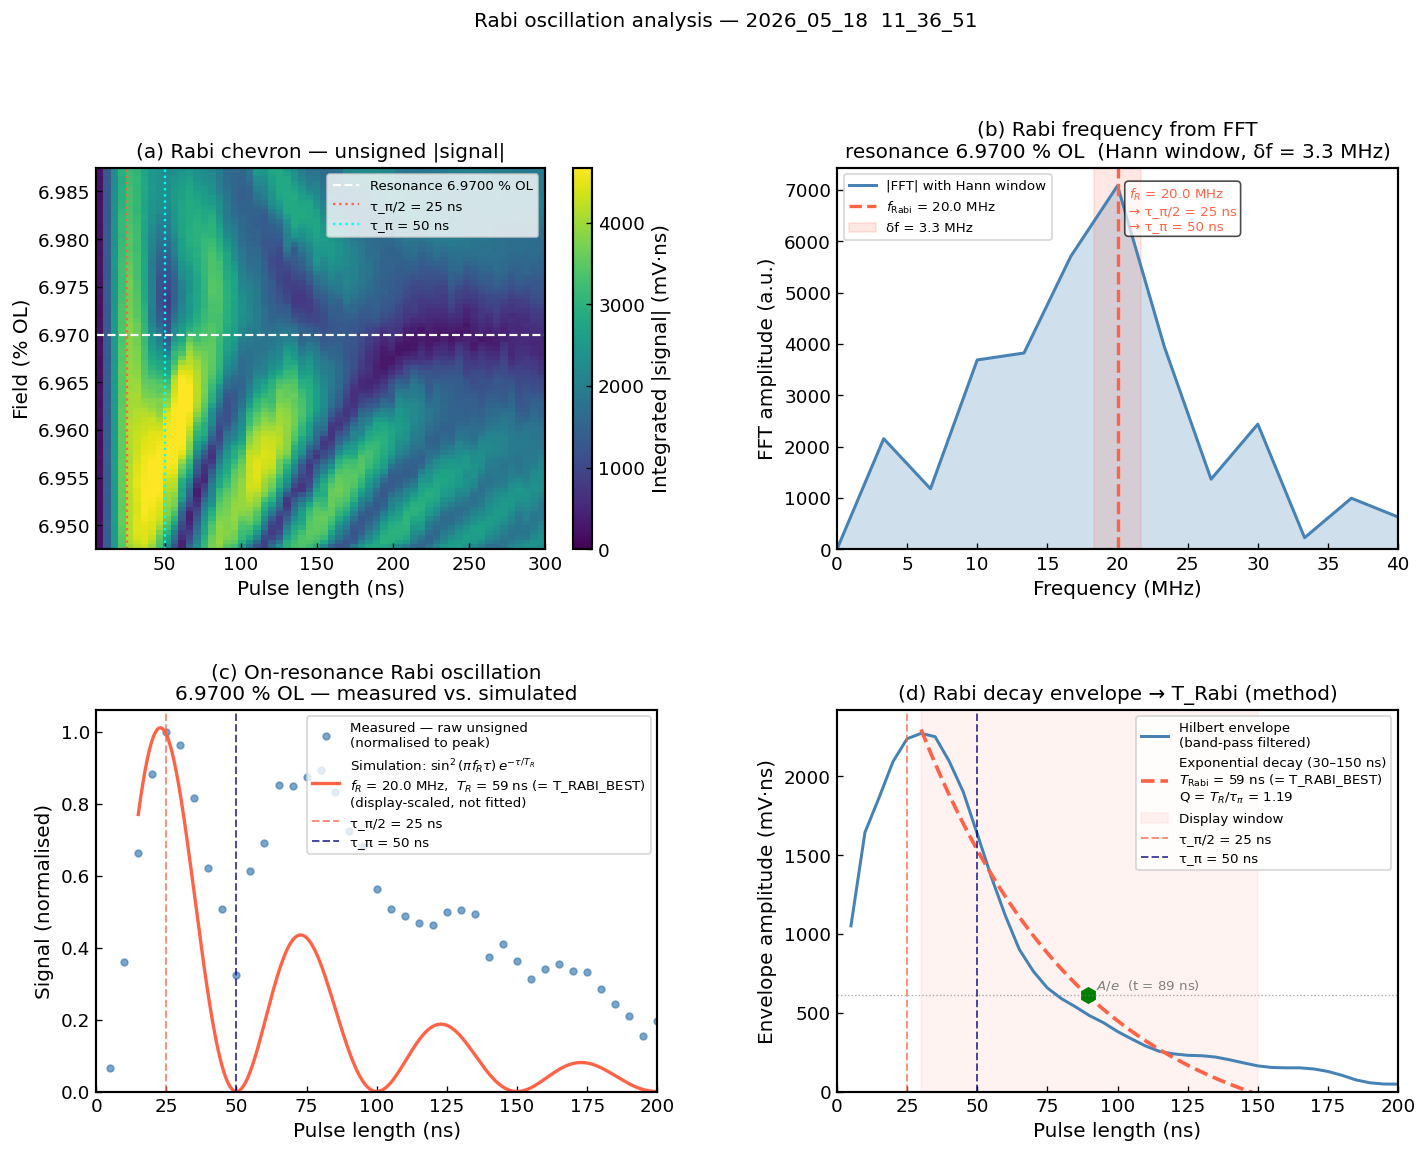

════════════════════════════════════════════════════════════
  RABI OSCILLATION SUMMARY
════════════════════════════════════════════════════════════
  Resonant field        : 6.9700 % OL
  f_Rabi (from FFT)      : 20.0 MHz   (δf = 3.3 MHz)
  τ_π/2                  : 25 ns
  τ_π                    : 50 ns
  T_Rabi (T_RABI_BEST)   : 59.3 ns   ← measured in the accuracy-check cell
  Q factor (T_Rabi/τ_π)  : 1.19
------------------------------------------------------------
  This figure illustrates the data and the methods used to extract f_Rabi and T_Rabi:
    (a) Rabi chevron map
    (b) f_Rabi identified from the FFT spectrum
    (c) on-resonance signal vs. simulated curve (display-scaled, scale = 1.011)
    (d) Hilbert envelope decay, the method used to extract T_Rabi (A = 4.42e+03, C = -371)
════════════════════════════════════════════════════════════


In [33]:

# figure tells the story of the Rabi analysis:
#   (a) the measured chevron map
#   (b) f_Rabi identified from its FFT spectrum
#   (c) the on-resonance signal compared to the simulated curve (display-scaled to the data, using T_R = T_RABI_BEST — not a fit)
#   (d) the Hilbert-envelope decay fit, the method used to extract T_RABI_BEST in the first place (with T_R fixed here purely to show the resulting curve against the envelope; A and C are fit)

# ══════════════════════════════════════════════════════════════
# Tuneable parameters
# ══════════════════════════════════════════════════════════════
SMOOTH_WIDTH = 12     # pts — background subtraction
BW_FACTOR    = 0.5    # band-pass bandwidth = ± BW_FACTOR * f_Rabi
FIT_START_NS = 30.0   # ns — start envelope display window (panel d)
FIT_END_NS   = 150.0  # ns — end envelope display window (panel d)
TAU_PI2      = 25.0   # ns — confirmed from chevron
TAU_PI       = 50.0   # ns

try:
    T_RABI =T_RABI_BEST   # from the accuracy-check cell — the only T_Rabi used here
except NameError:
    print('WARNING: T_RABI_BEST not found — run the T_Rabi accuracy check '
          'cell first. Using a rough placeholder guess of 50 ns.')
    T_RABI = 50.0

# ══════════════════════════════════════════════════════════════
# Recompute dependencies
# ══════════════════════════════════════════════════════════════
dead_ns     = 65
t_mask_rabi = (t_ns >= dead_ns) & (t_ns <= 370)

try:
    rabi_map_abs
except NameError:
    rabi_map_abs = np.sum(np.abs(signal[:, :, t_mask_rabi]), axis=2).astype(float)

rabi_map_bg  = uniform_filter1d(rabi_map_abs, size=SMOOTH_WIDTH, axis=1)
rabi_map_hpf = rabi_map_abs - rabi_map_bg

try:
    OL_axis
except NameError:
    fp_s    = row_main['settings']['field_pct']
    OL_axis = fp_s['start'] + fp_s['step'] * np.arange(n_field)
    if OL_axis[-1] < OL_axis[0]:
        OL_axis = OL_axis[::-1]

dp        = float(np.median(np.diff(pulse_ns)))
pulse_arr = np.asarray(pulse_ns, dtype=float)

# ── f_Rabi from FFT of background-subtracted map ──────────────
fft_freqs_all     = np.fft.rfftfreq(len(pulse_arr), d=dp*1e-9) * 1e-6
fft_map_hpf       = np.abs(np.fft.rfft(rabi_map_hpf, axis=1))
fft_map_hpf[:, 0] = 0

f_rabi_res = float(fft_freqs_all[1:][np.argmax(fft_map_hpf[res_idx, 1:])])
delta_f    = float(fft_freqs_all[1] - fft_freqs_all[0])
F_RABI     = f_rabi_res

print(f'f_Rabi = {F_RABI:.1f} MHz  (δf = {delta_f:.1f} MHz)')
print(f'T_Rabi = {T_RABI:.1f} ns  (T_RABI_BEST, used in panels c and d below)')

# ══════════════════════════════════════════════════════════════
# Band-pass filter and Hilbert envelope (used in panel d)
# ══════════════════════════════════════════════════════════════
rabi_res_hpf = rabi_map_hpf[res_idx, :].astype(float)

nyq  = 0.5 / (dp * 1e-9) * 1e-6
low  = max((F_RABI - F_RABI * BW_FACTOR) / nyq, 0.01)
high = min((F_RABI + F_RABI * BW_FACTOR) / nyq, 0.99)

b, a      = butter(2, [low, high], btype='band')
rabi_filt = filtfilt(b, a, rabi_res_hpf)
env_rabi  = np.abs(hilbert(rabi_filt))

# ══════════════════════════════════════════════════════════════
# Panel (d): Hilbert envelope decay — illustrates the method used to
# get T_RABI_BEST. T_R is fixed here so the dashed curve directly shows
# T_RABI_BEST against the envelope; only A and C are fit.
# ══════════════════════════════════════════════════════════════
def exp_decay_fixed_T(t, A, C):
    return A * np.exp(-t / T_RABI) + C

env_mask = (pulse_arr >= FIT_START_NS) & (pulse_arr <= FIT_END_NS)
A0 = float(env_rabi[env_mask][0])

try:
    popt_env, pcov_env = curve_fit(
        exp_decay_fixed_T, pulse_arr[env_mask], env_rabi[env_mask],
        p0=[A0, 0.],
        bounds=([0., -np.inf], [np.inf, np.inf]),
        maxfev=50000
    )
    A_env, C_env = popt_env
    env_ok = True
    print(f'Panel (d) envelope fit (T_R = T_RABI_BEST = {T_RABI:.1f} ns): A={A_env:.3g}, C={C_env:.3g}')
except Exception as e:
    print(f'Panel (d) fit failed: {e}')
    env_ok = False
    A_env, C_env = A0, 0.0

Q_factor = T_RABI / TAU_PI

# ══════════════════════════════════════════════════════════════
# Panel (c): on-resonance Rabi oscillation — measured vs. simulated.
# Measured data: normalised to peak (divide by max), no baseline subtraction.
# Simulated curve: a fixed-shape sin²(τ)·exp(-τ/T_RABI) curve, normalised to peak=1, then display-scaled to match the data's amplitude inan early window.
# ══════════════════════════════════════════════════════════════
cut_raw      = rabi_map_abs[res_idx, :].astype(float)
cut_raw_norm = cut_raw / np.max(cut_raw)

beta_c = np.pi * F_RABI * 1e-3   # rad/ns

tau_dense   = np.linspace(0.0, 250.0, 1000)
plot_mask_c = tau_dense >= 15.0

# Fixed-shape simulated curve, normalised to peak = 1
sim_c_shape = np.sin(beta_c * tau_dense)**2 * np.exp(-tau_dense / T_RABI)
sim_c_shape /= np.nanmax(sim_c_shape)

# Display-scale to match the measured data's amplitude in an early window
# (same SCALE_WINDOW_NS philosophy as the chevron-comparison cell)
SCALE_WINDOW_NS_C = (10.0, 70.0)
scale_mask_c = (pulse_arr >= SCALE_WINDOW_NS_C[0]) & (pulse_arr <= SCALE_WINDOW_NS_C[1])

sim_on_data_c = np.interp(pulse_arr, tau_dense, sim_c_shape)
data_amp_c    = np.nanpercentile(cut_raw_norm[scale_mask_c], 90) if np.any(scale_mask_c) else 1.0
sim_amp_c     = np.nanpercentile(sim_on_data_c[scale_mask_c], 90) if np.any(scale_mask_c) else 1.0
if not np.isfinite(sim_amp_c) or abs(sim_amp_c) < 1e-12:
    sim_amp_c = 1.0

scale_c = data_amp_c / sim_amp_c
sim_c   = scale_c * sim_c_shape

print(f'Panel (c): display scale = {scale_c:.3f}  (T_R fixed = {T_RABI:.1f} ns, no offset fitted)')

# ══════════════════════════════════════════════════════════════
# Panel (b): Hann-windowed FFT spectrum
# ══════════════════════════════════════════════════════════════
hann_w    = np.hanning(len(rabi_res_hpf))
hann_norm = hann_w / np.mean(hann_w)

fft_hann    = np.abs(np.fft.rfft(rabi_res_hpf * hann_norm))
fft_hann[0] = 0

fft_f_b  = np.fft.rfftfreq(len(rabi_res_hpf), d=dp*1e-9) * 1e-6
f_show_b = fft_f_b <= 40.0

# ══════════════════════════════════════════════════════════════
# Figure
# ══════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

# ── Panel (a): Rabi chevron ───────────────────────────────────
vmax_chev = np.percentile(rabi_map_abs, 99)

im_a = ax_a.imshow(
    rabi_map_abs, aspect='auto', origin='lower',
    extent=[pulse_arr[0], pulse_arr[-1], OL_axis[0], OL_axis[-1]],
    cmap='viridis', vmin=0, vmax=vmax_chev
)
ax_a.axhline(res_OL, color='white', lw=1.3, ls='--', label=f'Resonance {res_OL:.4f} % OL')
ax_a.axvline(TAU_PI2, color='tomato', lw=1.4, ls=':', label=f'τ_π/2 = {TAU_PI2:.0f} ns')
ax_a.axvline(TAU_PI,  color='cyan',   lw=1.4, ls=':', label=f'τ_π = {TAU_PI:.0f} ns')
fig.colorbar(im_a, ax=ax_a, label='Integrated |signal| (mV·ns)')
ax_a.set_xlabel('Pulse length (ns)')
ax_a.set_ylabel('Field (% OL)')
ax_a.set_ylim(OL_axis[0], OL_axis[-1])
ax_a.set_title('(a) Rabi chevron — unsigned |signal|')
ax_a.legend(fontsize=8, loc='upper right')

# ── Panel (b): Hann-windowed FFT spectrum ─────────────────────
ax_b.fill_between(fft_f_b[f_show_b], fft_hann[f_show_b], alpha=0.25, color='steelblue')
ax_b.plot(fft_f_b[f_show_b], fft_hann[f_show_b], '-', lw=1.8, color='steelblue',
          label='|FFT| with Hann window')
ax_b.axvline(F_RABI, color='tomato', lw=2.0, ls='--', label=f'$f_{{\\rm Rabi}}$ = {F_RABI:.1f} MHz')
ax_b.axvspan(F_RABI - delta_f/2, F_RABI + delta_f/2, alpha=0.15, color='tomato',
             label=f'δf = {delta_f:.1f} MHz')
ax_b.text(F_RABI + 0.8, np.max(fft_hann[f_show_b]) * 0.88,
          f'$f_R$ = {F_RABI:.1f} MHz\n→ τ_π/2 = {TAU_PI2:.0f} ns\n→ τ_π = {TAU_PI:.0f} ns',
          fontsize=8, color='tomato',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))
ax_b.set_xlabel('Frequency (MHz)')
ax_b.set_ylabel('FFT amplitude (a.u.)')
ax_b.set_xlim(0, 40)
ax_b.set_ylim(bottom=0)
ax_b.set_title(f'(b) Rabi frequency from FFT\nresonance {res_OL:.4f} % OL  (Hann window, δf = {delta_f:.1f} MHz)')
ax_b.legend(fontsize=8)

# ── Panel (c): on-resonance Rabi oscillation, measured vs. simulated ─
ax_c.plot(pulse_arr, cut_raw_norm, 'o', ms=4, color='steelblue', alpha=0.7,
          label='Measured — raw unsigned\n(normalised to peak)')
ax_c.plot(tau_dense[plot_mask_c], sim_c[plot_mask_c], '-', color='tomato', lw=2,
          label=(f'Simulation: $\\sin^2(\\pi f_R\\tau)\\,e^{{-\\tau/T_R}}$\n'
                 f'$f_R$ = {F_RABI:.1f} MHz,  $T_R$ = {T_RABI:.0f} ns (= T_RABI_BEST)\n'
                 f'(display-scaled, not fitted)'))
ax_c.axvline(TAU_PI2, color='tomato', lw=1.2, ls='--', alpha=0.7, label=f'τ_π/2 = {TAU_PI2:.0f} ns')
ax_c.axvline(TAU_PI,  color='navy',   lw=1.2, ls='--', alpha=0.7, label=f'τ_π = {TAU_PI:.0f} ns')
ax_c.set_xlim(0, 200)
ax_c.set_ylim(bottom=0)
ax_c.set_xlabel('Pulse length (ns)')
ax_c.set_ylabel('Signal (normalised)')
ax_c.set_title(f'(c) On-resonance Rabi oscillation\n{res_OL:.4f} % OL — measured vs. simulated')
ax_c.legend(fontsize=8)

# ── Panel (d): Hilbert envelope — method used to extract T_Rabi ─
ax_d.plot(pulse_arr, env_rabi, '-', color='steelblue', lw=1.8,
          label='Hilbert envelope\n(band-pass filtered)')

if env_ok:
    t_fit_d = np.linspace(FIT_START_NS, 200, 500)
    ax_d.plot(t_fit_d, exp_decay_fixed_T(t_fit_d, A_env, C_env), '--', color='tomato', lw=2.2,
              label=(f'Exponential decay ({FIT_START_NS:.0f}–{FIT_END_NS:.0f} ns)\n'
                     f'$T_{{\\rm Rabi}}$ = {T_RABI:.0f} ns (= T_RABI_BEST)\n'
                     f'Q = $T_R/\\tau_\\pi$ = {Q_factor:.2f}'))

    # A/e marker on the fixed-T curve
    t_1e   = FIT_START_NS + T_RABI
    amp_at_start = float(exp_decay_fixed_T(FIT_START_NS, A_env, C_env))
    amp_1e = (amp_at_start - C_env) * np.exp(-1.0) + C_env

    if 0 < t_1e < 200 and amp_1e > 0:
        ax_d.plot(t_1e, amp_1e, 'h', ms=8, color='green', markerfacecolor='green', markeredgewidth=2)
        ax_d.axhline(amp_1e, color='gray', lw=0.8, ls=':', alpha=0.7)
        ax_d.text(t_1e + 3, amp_1e * 1.06, f'$A/e$  (t = {t_1e:.0f} ns)', fontsize=8, color='gray')

    ax_d.axvspan(FIT_START_NS, FIT_END_NS, alpha=0.07, color='tomato', label='Display window')

ax_d.axvline(TAU_PI2, color='tomato', lw=1.2, ls='--', alpha=0.7, label=f'τ_π/2 = {TAU_PI2:.0f} ns')
ax_d.axvline(TAU_PI,  color='navy',   lw=1.2, ls='--', alpha=0.7, label=f'τ_π = {TAU_PI:.0f} ns')
ax_d.set_xlim(0, 200)
ax_d.set_ylim(bottom=0)
ax_d.set_xlabel('Pulse length (ns)')
ax_d.set_ylabel('Envelope amplitude (mV·ns)')
ax_d.set_title('(d) Rabi decay envelope → T_Rabi (method)')
ax_d.legend(fontsize=8)

plt.suptitle(f'Rabi oscillation analysis — {row_main["date"]}  {row_main["prefix"]}',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════
print('═' * 60)
print('  RABI OSCILLATION SUMMARY')
print('═' * 60)
print(f'  Resonant field        : {res_OL:.4f} % OL')
print(f'  f_Rabi (from FFT)      : {F_RABI:.1f} MHz   (δf = {delta_f:.1f} MHz)')
print(f'  τ_π/2                  : {TAU_PI2:.0f} ns')
print(f'  τ_π                    : {TAU_PI:.0f} ns')
print(f'  T_Rabi (T_RABI_BEST)   : {T_RABI:.1f} ns   ← measured in the accuracy-check cell')
print(f'  Q factor (T_Rabi/τ_π)  : {Q_factor:.2f}')
print('-' * 60)
print('  This figure illustrates the data and the methods used to extract f_Rabi and T_Rabi:')
print(f'    (a) Rabi chevron map')
print(f'    (b) f_Rabi identified from the FFT spectrum')
print(f'    (c) on-resonance signal vs. simulated curve (display-scaled, scale = {scale_c:.3f})')
if env_ok:
    print(f'    (d) Hilbert envelope decay, the method used to extract T_Rabi (A = {A_env:.3g}, C = {C_env:.3g})')
print('═' * 60)

---
## 5  Rabi chevron

### Physics

- Sweeping both $\tau_p$ and $B_0$ reveals the **Rabi chevron**.
- Off resonance, effective Rabi frequency increases:

$$\tilde\Omega_R(B_0) = \sqrt{\Omega_R^2 + \Delta^2} \qquad \Delta = \gamma_e(B_0 - B_0^{\rm res})$$

- Fringe period grows with detuning, densest at $B_0^{\rm res}$ — forms the characteristic V-shape.
- Vertex of the V confirms the resonant field independently of the field-profile estimate in Section 2.

### Simulation

$$S(B_0, \tau_p) = \left(\frac{\Omega_R}{\tilde\Omega_R}\right)^2 \sin^2\!\left(\frac{\tilde\Omega_R\,\tau_p}{2}\right) e^{-\tau_p/T_{\rm Rabi}}$$

- $(\Omega_R/\tilde\Omega_R)^2$ = amplitude suppression off resonance — only part of $B_1$ drives detuned spins.
- $f_{\rm Rabi}$ auto-detected from the background-subtracted FFT peak (Section 4); $T_{\rm Rabi} = $ `T_RABI_BEST` (Section 4.1).
- Map decay time set to $10\times T_{\rm Rabi}$ purely for visibility — off-resonance rows would otherwise fade out before the fringe structure is visible across the full pulse-length range; this is a display choice, not a physical claim that off-resonance decay is slower.
- A residual panel (measured − scaled simulation) flags where the model and data diverge.

f_Rabi = 20.0 MHz  [auto-detected, FFT]  (δf = 3.3 MHz)  →  τ_π/2 = 25.0 ns,  τ_π = 50.0 ns
T_Rabi = 59.3 ns  (T_RABI_BEST)


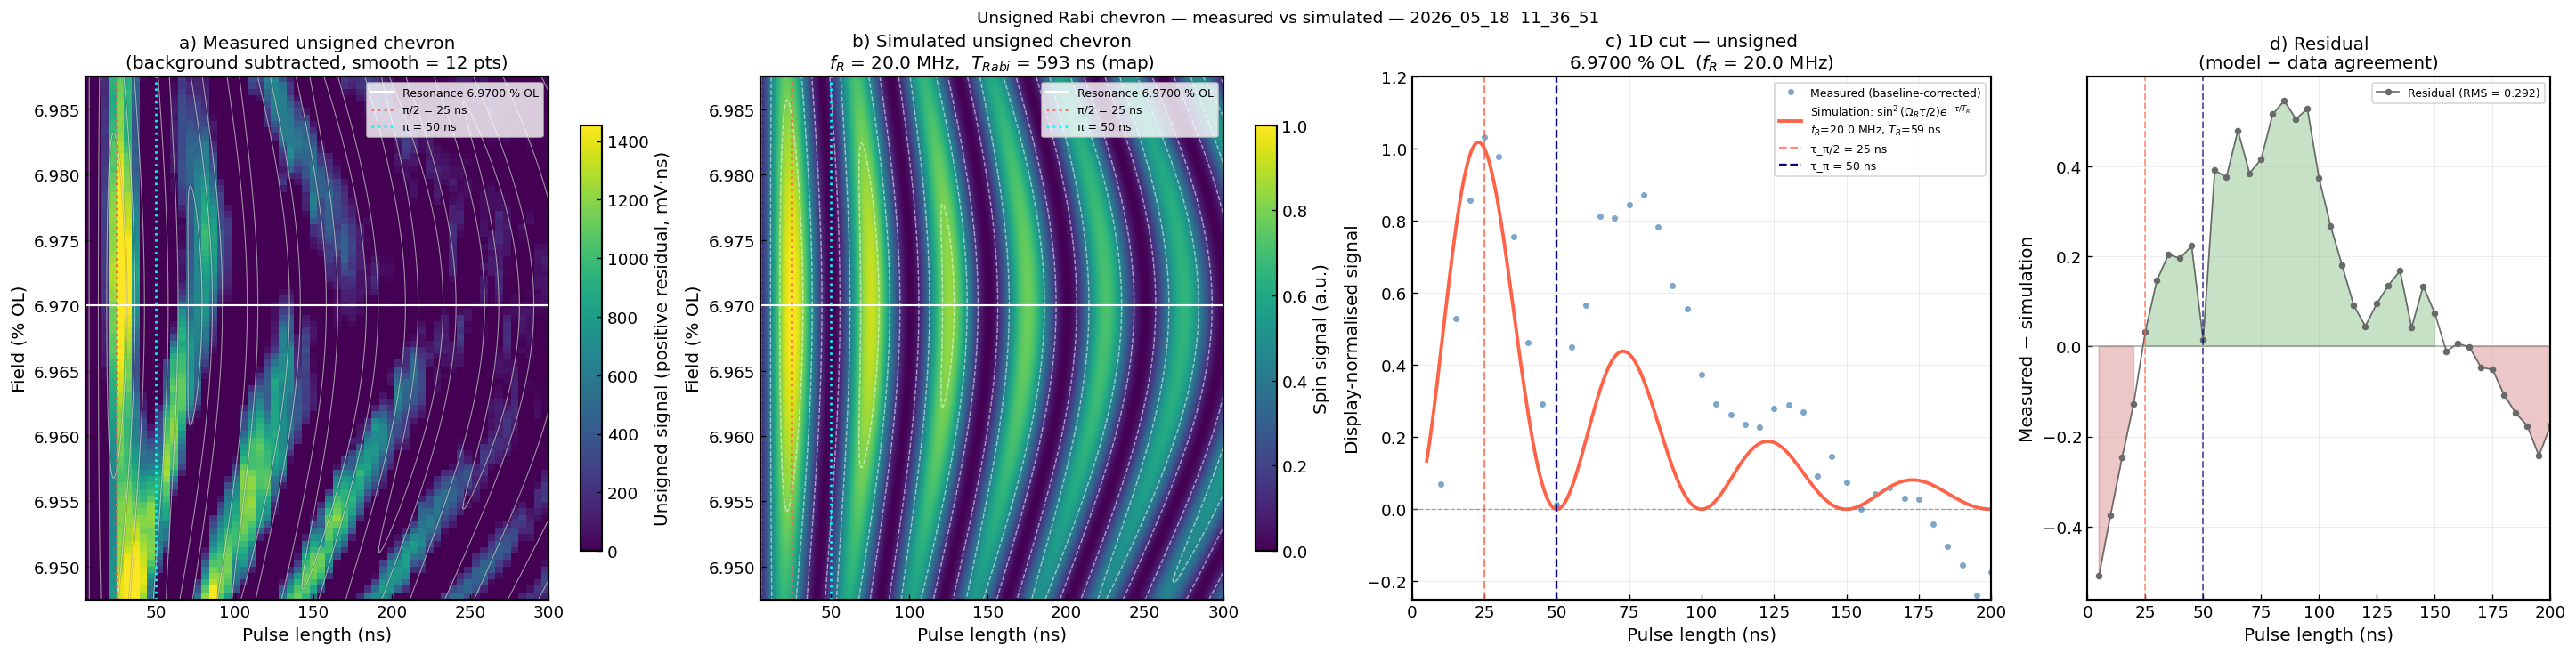


Parameters used:
  f_Rabi   = 20.0 MHz   [auto-detected, FFT]  (δf = 3.3 MHz)
  T_Rabi   = 59.3 ns (1D),  593.1 ns (2D map, scaled for visibility)
  τ_π/2    = 25.0 ns
  τ_π      = 50.0 ns
  smoothing width = 12 pts ≈ 60 ns
  1D baseline = 1198,  amplitude = 2541,  sim scale = 1.018
  1D residual RMS = 0.292  (in normalised units, 1.0 = peak signal)


In [34]:
## Rabi chevron analysis — unsigned signal, measured vs. simulated
#
# Model:
#   S(B, τ) = (Ω_R / Ω_eff)² · sin²(Ω_eff · τ / 2) · exp(-τ / T_Rabi)
#
#   Ω_R    = on-resonance Rabi frequency (rad/s)
#   Ω_eff  = sqrt(Ω_R² + Δ²)   effective nutation rate off resonance
#   Δ      = γ_e · (B - B_res) detuning from resonance (rad/s)
#
# On resonance (Δ=0, Ω_eff=Ω_R) this reduces to the textbook Rabi formula  S(τ) = sin²(Ω_R τ / 2) · exp(-τ/T_Rabi),
# with first maximum at τ_π/2 = 1/(2 f_Rabi) and first zero at τ_π = 1/f_Rabi.
#
# F_RABI auto-detected from the background-subtracted FFT peak
# T_RABI is set from T_RABI_BEST by default

# ══════════════════════════════════════════════════════════════
# ── Parameters for tuning ───────────────────────────────────────
# ══════════════════════════════════════════════════════════════

try:
    T_RABI = T_RABI_BEST   # from the accuracy-check cell — override below if desired
except NameError:
    print('WARNING: T_RABI_BEST not found — run the T_Rabi accuracy check '
          'cell first. Using a rough placeholder guess of 50 ns.')
    T_RABI = 50.0

# T_RABI = 65.0   # ← uncomment and edit to override T_RABI_BEST manually

T_RABI_MAP = T_RABI * 10.0   # ns — slower decay used only to keep the
                              #      2D simulated map visible at long τ
                              #      (display choice, not physics)

BACKGROUND_SUB = True   # subtract a smoothed background from the 2D map?
SMOOTH_WIDTH   = 12     # smoothing width in points (must stay shorter
                         # than one Rabi period, else it distorts the signal)

# F_RABI is auto-detected from the background-subtracted FFT peak below.
# This only works reliably when BACKGROUND_SUB = True — without background
# subtraction, the FFT is dominated by the slow background envelope
# (≈3.3 MHz), not the true Rabi frequency (see the raw-vs-BG-subtracted
# FFT diagnostic). If you set BACKGROUND_SUB = False, set this manually:
F_RABI_MANUAL = 20.0   # MHz — only used when BACKGROUND_SUB = False

GAMMA_E = 28.0   # MHz/mT — electron gyromagnetic ratio, sets the
                 # detuning Δ = 2π·GAMMA_E·(B - B_res)

# Windows used only for cosmetics of the 1D plot (baseline removal,
# amplitude scaling, x-axis range) — not physics, just display choices
BASELINE_WINDOW_NS = (150, 200)   # flat tail used to estimate the offset
SCALE_WINDOW_NS    = (10, 70)     # early oscillation used to set the scale
PLOT_XLIM_NS       = (0, 200)

pulse_arr = np.asarray(pulse_ns, dtype=float)
dp        = float(np.median(np.diff(pulse_arr)))

# ══════════════════════════════════════════════════════════════
# ── Make sure the raw 2D map and field axis exist ─────────────
# ══════════════════════════════════════════════════════════════

try:
    rabi_map_abs
except NameError:
    # Sum |signal| over the FID window to get one number per (field, pulse length)
    t_mask_rabi  = (t_ns >= 65) & (t_ns <= 370)
    rabi_map_abs = np.sum(np.abs(signal[:, :, t_mask_rabi]), axis=2).astype(float)

try:
    OL_axis
except NameError:
    fp_s    = row_main['settings']['field_pct']
    OL_axis = fp_s['start'] + fp_s['step'] * np.arange(n_field)
    if OL_axis[-1] < OL_axis[0]:
        OL_axis = OL_axis[::-1]

# ══════════════════════════════════════════════════════════════
# ── Background subtraction (removes the slow non-Rabi envelope) ─
# ══════════════════════════════════════════════════════════════

if BACKGROUND_SUB:
    background = uniform_filter1d(rabi_map_abs, size=SMOOTH_WIDTH, axis=1)
    map_u = rabi_map_abs - background
    map_label = f'background subtracted, smooth = {SMOOTH_WIDTH} pts'
else:
    map_u = rabi_map_abs.copy()
    map_label = 'raw, unsmoothed'

# Clip to positive residuals only — easier to read than a signed residual
map_u_display = np.clip(map_u, 0, None)

vmax_u = np.nanpercentile(map_u_display, 99.0)
if not np.isfinite(vmax_u) or vmax_u <= 0:
    vmax_u = np.nanmax(map_u_display)

# ══════════════════════════════════════════════════════════════
# ── F_RABI: auto-detected from FFT when background-subtracted,
# otherwise taken from F_RABI_MANUAL (see warning above)
# ══════════════════════════════════════════════════════════════

fft_freqs_all = np.fft.rfftfreq(len(pulse_arr), d=dp * 1e-9) * 1e-6

if BACKGROUND_SUB:
    fft_map_hpf       = np.abs(np.fft.rfft(map_u, axis=1))
    fft_map_hpf[:, 0] = 0

    F_RABI  = float(fft_freqs_all[1:][np.argmax(fft_map_hpf[res_idx, 1:])])
    delta_f = float(fft_freqs_all[1] - fft_freqs_all[0])
else:
    F_RABI  = F_RABI_MANUAL
    delta_f = float(fft_freqs_all[1] - fft_freqs_all[0])
    print(f'BACKGROUND_SUB = False → FFT auto-detection skipped '
          f'(would pick up the background envelope, not f_Rabi).')
    print(f'Using F_RABI_MANUAL = {F_RABI:.1f} MHz instead.')

# ══════════════════════════════════════════════════════════════
# ── Derived pulse-length markers ──────────────────────────────
# ══════════════════════════════════════════════════════════════

tau_pi2 = 1e3 / (2.0 * F_RABI)   # ns — first maximum (π/2 pulse)
tau_pi  = 1e3 / (1.0 * F_RABI)   # ns — first zero    (π pulse)

f_rabi_source = 'auto-detected, FFT' if BACKGROUND_SUB else 'manual (F_RABI_MANUAL)'
print(f'f_Rabi = {F_RABI:.1f} MHz  [{f_rabi_source}]  (δf = {delta_f:.1f} MHz)  →  '
      f'τ_π/2 = {tau_pi2:.1f} ns,  τ_π = {tau_pi:.1f} ns')
print(f'T_Rabi = {T_RABI:.1f} ns  (T_RABI_BEST)')

# ══════════════════════════════════════════════════════════════
# ── 2D simulation over (field, pulse length) ──────────────────
# ══════════════════════════════════════════════════════════════

# Dense pulse-length axis for a smooth simulated curve/map
tau_sim = np.union1d(
    np.linspace(pulse_arr[0], pulse_arr[-1], 700),
    [tau_pi2, tau_pi]
)

field_sim    = np.asarray(field_mT, dtype=float)
OL_res_sim   = (B_res    - 18.678) / 22.934   # resonance field in % OL units
field_OL_sim = (field_sim - 18.678) / 22.934  # full field axis in % OL units

B_grid, tau_grid = np.meshgrid(field_sim, tau_sim, indexing='ij')
tau_grid_s = tau_grid * 1e-9   # ns -> s for the formula below

Omega_R   = 2 * np.pi * F_RABI  * 1e6                    # rad/s
Delta     = 2 * np.pi * GAMMA_E * 1e6 * (B_grid - B_res)  # rad/s, detuning
Omega_eff = np.sqrt(Omega_R**2 + Delta**2)                # rad/s

chevron_sim = (
    (Omega_R / Omega_eff) ** 2
    * np.sin(Omega_eff * tau_grid_s / 2.0) ** 2
    * np.exp(-tau_grid / T_RABI_MAP)
)
chevron_sim /= np.nanmax(chevron_sim)   # normalise to peak = 1

# On-resonance 1D simulated curve (just the Δ=0 case of the same formula)
sim_1d = np.sin(np.pi * F_RABI * 1e-3 * tau_sim) ** 2 * np.exp(-tau_sim / T_RABI)
sim_1d /= np.nanmax(sim_1d)

# ══════════════════════════════════════════════════════════════
# ── Measured 1D cut at the resonant field ─────────────────────
# ══════════════════════════════════════════════════════════════

cut_raw = rabi_map_abs[res_idx, :].astype(float)

# Remove the flat offset (estimated from the long-pulse tail)
baseline_mask = (pulse_arr >= BASELINE_WINDOW_NS[0]) & (pulse_arr <= BASELINE_WINDOW_NS[1])
baseline = np.nanmedian(cut_raw[baseline_mask]) if np.any(baseline_mask) else 0.0
cut_0 = cut_raw - baseline

# Normalise to the early oscillation amplitude so values run roughly 0-1
scale_mask = (pulse_arr >= SCALE_WINDOW_NS[0]) & (pulse_arr <= SCALE_WINDOW_NS[1])
amplitude = np.nanpercentile(cut_0[scale_mask], 95) if np.any(scale_mask) else np.nanmax(np.abs(cut_0))
if not np.isfinite(amplitude) or abs(amplitude) < 1e-12:
    amplitude = 1.0

cut_norm = cut_0 / amplitude

# Scale the simulation to match the measured amplitude in the same window
# (this is a display choice, not a physical fit)
sim_on_data    = np.interp(pulse_arr, tau_sim, sim_1d)
sim_scale      = np.nanpercentile(cut_norm[scale_mask], 90) / np.nanpercentile(sim_on_data[scale_mask], 90)
sim_1d_display = sim_scale * sim_1d

# Residual: measured minus scaled simulation, evaluated on the measured grid
sim_on_data_display = sim_scale * sim_on_data
residual = cut_norm - sim_on_data_display
residual_rms = float(np.sqrt(np.nanmean(residual**2)))

# ══════════════════════════════════════════════════════════════
# ── Figure: measured map | simulated map | 1D cut | residual ──
# ══════════════════════════════════════════════════════════════

fig, (ax_meas, ax_sim, ax_1d, ax_res) = plt.subplots(
    1, 4, figsize=(24, 5.8),
    gridspec_kw={'width_ratios': [1.0, 1.0, 1.25, 1.0]},
    constrained_layout=True
)

# -- Panel 1: measured map, with elegant simulated contours as a guide --
im_meas = ax_meas.imshow(
    map_u_display, aspect='auto', origin='lower',
    extent=[pulse_arr[0], pulse_arr[-1], OL_axis[0], OL_axis[-1]],
    cmap='viridis', vmin=0, vmax=vmax_u
)
# Subtle white guide contours with a soft dark "shadow" pass underneath
# for elegance/legibility against bright viridis regions
ax_meas.contour(
    tau_sim, field_OL_sim, chevron_sim,
    levels=[0.2, 0.55, 0.85], colors='black', linestyles='-',
    linewidths=1.6, alpha=0.18
)
ax_meas.contour(
    tau_sim, field_OL_sim, chevron_sim,
    levels=[0.2, 0.55, 0.85], colors='white', linestyles='-',
    linewidths=0.7, alpha=0.55
)
ax_meas.axhline(res_OL, color='white', lw=1.3, label=f'Resonance {res_OL:.4f} % OL')
ax_meas.axvline(tau_pi2, color='tomato', ls=':', lw=1.6, label=f'π/2 = {tau_pi2:.0f} ns')
ax_meas.axvline(tau_pi,  color='cyan',   ls=':', lw=1.6, label=f'π = {tau_pi:.0f} ns')
fig.colorbar(im_meas, ax=ax_meas, label='Unsigned signal (positive residual, mV·ns)',
             fraction=0.046, pad=0.035)
ax_meas.set(xlabel='Pulse length (ns)', ylabel='Field (% OL)')
ax_meas.set_ylim(OL_axis[0], OL_axis[-1])
ax_meas.set_title(f'a) Measured unsigned chevron\n({map_label})')
ax_meas.legend(fontsize=7.5, loc='upper right')

# -- Panel 2: pure simulation --
im_sim = ax_sim.imshow(
    chevron_sim, aspect='auto', origin='lower',
    extent=[tau_sim[0], tau_sim[-1], field_OL_sim[0], field_OL_sim[-1]],
    cmap='viridis', vmin=0, vmax=1
)
ax_sim.contour(tau_sim, field_OL_sim, chevron_sim,
              levels=[0.12, 0.45, 0.80], colors='white', linewidths=0.85,
              linestyles='--', alpha=0.55)
ax_sim.axhline(OL_res_sim, color='white', lw=1.3, label=f'Resonance {OL_res_sim:.4f} % OL')
ax_sim.axvline(tau_pi2, color='tomato', ls=':', lw=1.6, label=f'π/2 = {tau_pi2:.0f} ns')
ax_sim.axvline(tau_pi,  color='cyan',   ls=':', lw=1.6, label=f'π = {tau_pi:.0f} ns')
fig.colorbar(im_sim, ax=ax_sim, label='Spin signal (a.u.)', fraction=0.046, pad=0.035)
ax_sim.set(xlabel='Pulse length (ns)', ylabel='Field (% OL)')
ax_sim.set_ylim(OL_axis[0], OL_axis[-1])
ax_sim.set_title(f'b) Simulated unsigned chevron\n$f_R$ = {F_RABI:.1f} MHz,  $T_{{Rabi}}$ = {T_RABI_MAP:.0f} ns (map)')
ax_sim.legend(fontsize=7.5, loc='upper right')

# -- Panel 3: 1D cut at resonance, measured vs simulated --
ax_1d.plot(pulse_arr, cut_norm, 'o', ms=4.2, color='steelblue', alpha=0.7,
          markeredgewidth=0, label='Measured (baseline-corrected)')
ax_1d.plot(tau_sim, sim_1d_display, '-', color='tomato', lw=2.3,
          label=f'Simulation: $\\sin^2(\\Omega_R\\tau/2)e^{{-\\tau/T_R}}$\n'
                f'$f_R$={F_RABI:.1f} MHz, $T_R$={T_RABI:.0f} ns')
ax_1d.axvline(tau_pi2, color='tomato', ls='--', lw=1.4, alpha=0.75, label=f'τ_π/2 = {tau_pi2:.0f} ns')
ax_1d.axvline(tau_pi,  color='navy',   ls='--', lw=1.4, label=f'τ_π = {tau_pi:.0f} ns')
ax_1d.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.7)
ax_1d.set_xlim(*PLOT_XLIM_NS)
ax_1d.set_ylim(-0.25, 1.20)
ax_1d.set(xlabel='Pulse length (ns)', ylabel='Display-normalised signal')
ax_1d.grid(alpha=0.22, lw=0.6)
ax_1d.set_title(f'c) 1D cut — unsigned\n{res_OL:.4f} % OL  ($f_R$ = {F_RABI:.1f} MHz)')
ax_1d.legend(fontsize=7.5, loc='upper right')

# -- Panel 4: residual (measured - scaled simulation) --
ax_res.axhline(0, color='gray', lw=1.0, ls='-', alpha=0.6)
ax_res.fill_between(pulse_arr, residual, 0, where=(residual >= 0),
                     color='forestgreen', alpha=0.25, step=None)
ax_res.fill_between(pulse_arr, residual, 0, where=(residual < 0),
                     color='firebrick', alpha=0.25, step=None)
ax_res.plot(pulse_arr, residual, 'o-', ms=3.5, color='dimgray', lw=1.0,
            label=f'Residual (RMS = {residual_rms:.3f})')
ax_res.axvline(tau_pi2, color='tomato', ls='--', lw=1.2, alpha=0.6)
ax_res.axvline(tau_pi,  color='navy',   ls='--', lw=1.2, alpha=0.6)
ax_res.set_xlim(*PLOT_XLIM_NS)
ax_res.set(xlabel='Pulse length (ns)', ylabel='Measured − simulation')
ax_res.grid(alpha=0.22, lw=0.6)
ax_res.set_title('d) Residual\n(model − data agreement)')
ax_res.legend(fontsize=7.5, loc='upper right')

fig.suptitle(f'Unsigned Rabi chevron — measured vs simulated — '
            f'{row_main["date"]}  {row_main["prefix"]}', fontsize=11, y=1.03)

plt.show()

# ══════════════════════════════════════════════════════════════
# ── Summary ───────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════

print('\nParameters used:')
print(f'  f_Rabi   = {F_RABI:.1f} MHz   [{f_rabi_source}]  (δf = {delta_f:.1f} MHz)')
print(f'  T_Rabi   = {T_RABI:.1f} ns (1D),  {T_RABI_MAP:.1f} ns (2D map, scaled for visibility)')
print(f'  τ_π/2    = {tau_pi2:.1f} ns')
print(f'  τ_π      = {tau_pi:.1f} ns')
if BACKGROUND_SUB:
    print(f'  smoothing width = {SMOOTH_WIDTH} pts ≈ {SMOOTH_WIDTH*dp:.0f} ns')
print(f'  1D baseline = {baseline:.4g},  amplitude = {amplitude:.4g},  sim scale = {sim_scale:.3f}')
print(f'  1D residual RMS = {residual_rms:.3f}  (in normalised units, 1.0 = peak signal)')

---
## 6  Power scaling — $\tau_\pi \propto 1/\sqrt{P}$ → flip-angle scaling

Uses the power-and-pulse sweep dataset (see overview below for selecting which one).

### Physics

- Resonator field: $B_1 \propto \sqrt{P}$
- Rabi frequency: $\Omega_R = \gamma_e B_1 \propto \sqrt{P}$
- π-pulse condition $\Omega_R\tau_\pi = \pi$ gives:

$$\tau_\pi \propto \frac{1}{\sqrt{P}} \qquad\Longleftrightarrow\qquad \sqrt{P}\cdot\tau_\pi = \mathrm{const}$$

### Extraction method

- $\tau_\pi$ and $\tau_{\pi/2}$ are obtained from a damped $\sin^2$ fit per power row (not a heuristic peak-finder):

$$S(\tau) = A\sin^2(\pi f_R\tau)\,e^{-\tau/T_R} + C \quad\Rightarrow\quad \tau_\pi = \frac{1}{f_R},\ \ \tau_{\pi/2} = \frac{1}{2f_R}$$

- Each row's fit is seeded with the **previous (higher-power) row's** fitted $f_R$, walking from high to low power — a single fixed guess for every row fails at low power, where $f_R$ drifts far from any one constant and the fit locks onto the wrong period.

### Result: nonzero intercept

- Fitting $\tau_\pi$ vs $1/\sqrt P$ both ways:

$$\text{origin fit: } \tau_\pi = a/\sqrt P \qquad\qquad \text{free fit: } \tau_\pi = a/\sqrt P + b$$

- $b$ comes out **many $\sigma$ from zero** — a genuine systematic, not noise.
- Independent check: $f_{\rm Rabi}$ vs $\sqrt P$ stays **linear across the full power range**, no flattening at high power.
- → favors a **fixed timing-type offset** (e.g. finite pulse rise/fall time) over amplifier compression, which would instead bend the high-power end of the $f_{\rm Rabi}$–$\sqrt P$ curve.
- **Headline result:** the free-intercept fit, with $b$ reported as a measured offset.

### 6.1  Overview of all power-pulse datasets

The **SNR estimate** is: peak integrated $|signal|$ (averaged over
power rows) divided by the std of the integrated signal at the
shortest pulse lengths (where $\tau_p \ll \tau_{\pi/2}$, so the FID is
negligible and the integrated signal is pure noise).

Use the table and thumbnails below to choose the best dataset, then
set `PP_IDX` in 6.2.

In [35]:
print(f'Found {len(df_power_pulse)} power-pulse datasets\n')
print(f'{"idx":<5}{"date":<14}{"prefix":<12}{"shape":<24}{"power dBm":<18}{"pulse ns":<18}{"SNR":>6}')
print('-' * 97)
for i, row in df_power_pulse.iterrows():
    try:
        s, t, pw, pl = load_power_pulse(row)
        shape_s = f'{s.shape[0]}×{s.shape[1]}×{s.shape[2]}'
        pow_s   = f'{pw[0]:.0f}–{pw[-1]:.0f}'
        pls_s   = f'{pl[0]:.0f}–{pl[-1]:.0f}'
        snr_v   = snr_estimate(s)
        flag    = '  ← HIGH SNR' if snr_v > 10 else ''
        print(f'{i:<5}{row["date"]:<14}{row["prefix"]:<12}{shape_s:<24}{pow_s:<18}{pls_s:<18}{snr_v:>6.1f}{flag}')
    except Exception as e:
        print(f'{i:<5}{row["date"]:<14}{row["prefix"]:<12}  ERROR: {e}')


Found 2 power-pulse datasets

idx  date          prefix      shape                   power dBm         pulse ns             SNR
-------------------------------------------------------------------------------------------------
0    2026_05_14    14_43_50    15×49×1000              -12–2             10–250               4.5
1    2026_05_17    11_57_29    25×60×2000              -8–4              5–300                2.8


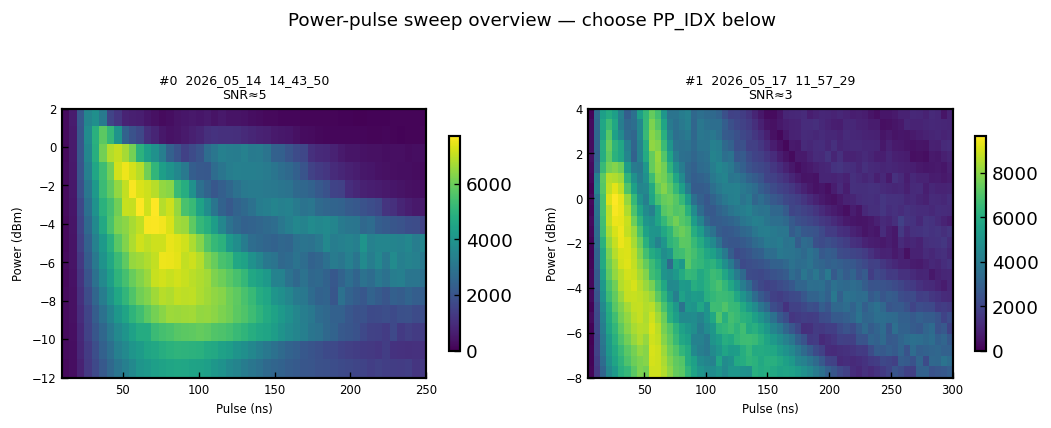

In [36]:
n_pp  = len(df_power_pulse)
ncols = min(n_pp, 4)
nrows = (n_pp + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 3.5*nrows))
# Normalise axes to always be 2-D array
if n_pp == 1:
    axes = np.array([[axes]])
elif nrows == 1:
    axes = axes[np.newaxis, :]

for idx, (i, row) in enumerate(df_power_pulse.iterrows()):
    ax = axes[idx // ncols, idx % ncols]
    try:
        s, t, pw, pl = load_power_pulse(row)
        integ = np.sum(np.abs(s), axis=2)
        snr_v = snr_estimate(s)
        ext   = [pl[0], pl[-1], pw[0], pw[-1]]
        im = ax.imshow(integ, aspect='auto', origin='lower',
                       extent=ext, cmap='viridis',
                       vmin=0, vmax=np.max(integ))
        ax.set_title(f'#{i}  {row["date"]}  {row["prefix"]}\nSNR≈{snr_v:.0f}', fontsize=7.5)
        ax.set_xlabel('Pulse (ns)', fontsize=7)
        ax.set_ylabel('Power (dBm)', fontsize=7)
        ax.tick_params(labelsize=7)
        fig.colorbar(im, ax=ax, shrink=0.8)
    except Exception as e:
        ax.text(0.5, 0.5, f'Error:\n{e}', transform=ax.transAxes,
                ha='center', va='center', fontsize=7)
        ax.set_title(f'#{i}  {row["date"]}', fontsize=7.5)

for idx in range(n_pp, nrows * ncols):
    axes[idx // ncols, idx % ncols].set_visible(False)

fig.suptitle('Power-pulse sweep overview — choose PP_IDX below', fontsize=11, y=1.01)
plt.tight_layout(); plt.show()


### 6.2  Analysis on the chosen dataset

Using   : 2026_05_17  11_57_29
Shape   : (25, 60, 2000)  (25 power levels, 60 pulse lengths)
Power   : -8.0 – 4.0 dBm
Pulse   : 5 – 300 ns
Using power range: -8.00 to 1.50 dBm
Kept 20 / 25 power rows

Rabi fit converged for 20 / 20 power rows

τ_π vs 1/√P:
  origin fit : τ_π = (47.7 ± 0.3) · (1/√P)
  free fit   : τ_π = (43.6 ± 0.3) · (1/√P) + (7.0 ± 0.6) ns   ← headline result
  √P·τ_π     : 48.55 ± 1.63  ns·mW^0.5

f_Rabi vs √P:
  slope     = 18.33 ± 0.19  MHz/√mW
  intercept = 1.46 ± 0.15  MHz
  Linear across the full power range with no high-power flattening
  → consistent with a fixed timing-type offset, not amplifier compression.


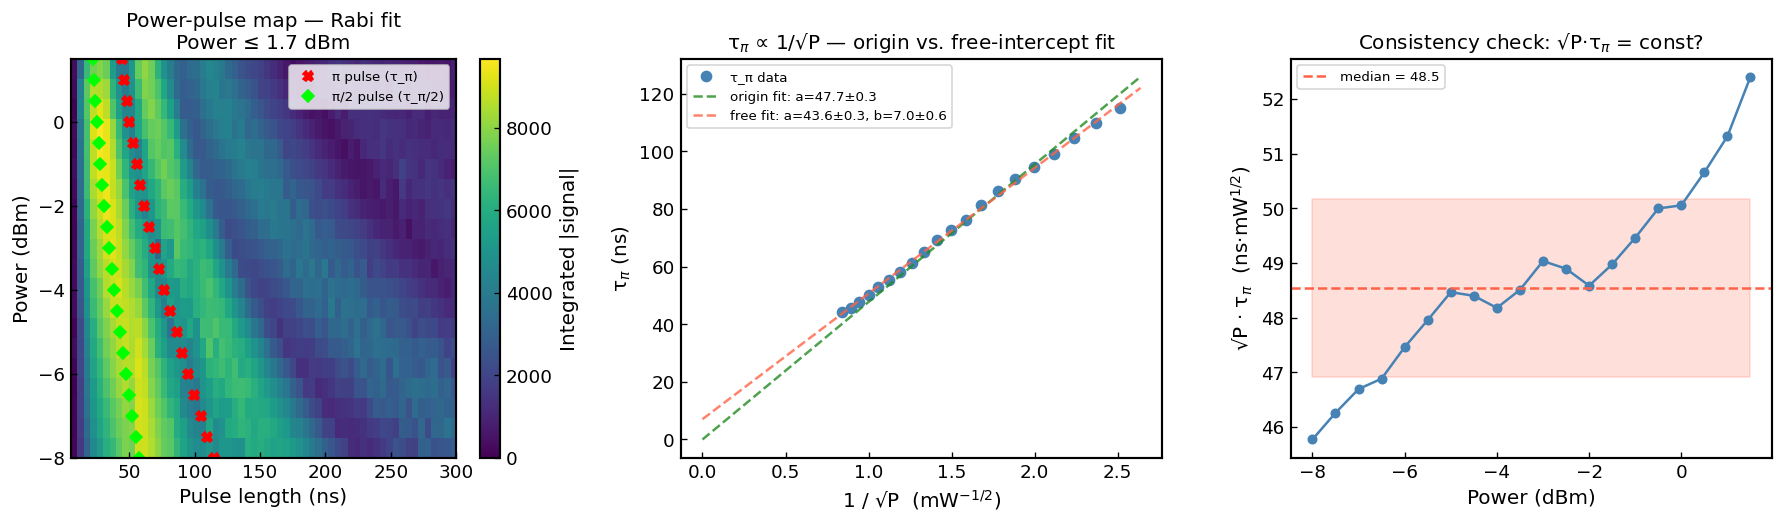

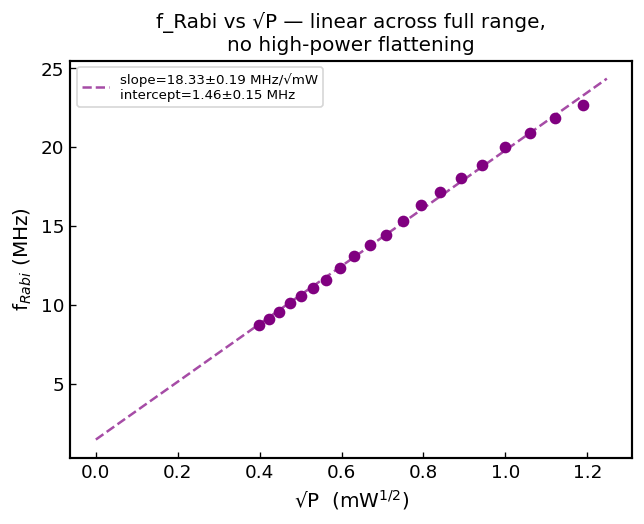

════════════════════════════════════════════════════════════
  POWER SCALING SUMMARY
════════════════════════════════════════════════════════════
  Headline result (free-intercept fit):  τ_π = (43.6 ± 0.3) ns·mW$^{1/2}$ / √P  +  (7.0 ± 0.6) ns
  Fixed offset of 7.0 ± 0.6 ns is many σ from zero — a genuine systematic, not a fitting artifact.
  f_Rabi vs √P stays linear up to the highest power measured, arguing for a fixed timing-type offset rather than amplifier compression (which would instead bend the f_Rabi-vs-√P curve at high power).
════════════════════════════════════════════════════════════


In [37]:
## Power scaling — τ_π ∝ 1/√P
#
# τ_π and τ_π/2 are extracted from a damped sin² fit to each power
# row's on-resonance signal (same model family used throughout this
# notebook), rather than a heuristic peak-finder. This was compared
# directly against a simple "first local minimum" heuristic and found
# to be both smoother (less row-to-row scatter in the √P·τ_π
# consistency check) and more precise (smaller fit uncertainty on the
# τ_π vs 1/√P intercept), so only the Rabi-fit method is kept here.
#
# Both extracted quantities are fit two ways against 1/√P: forced
# through the origin (τ_π = a/√P, the naive physical expectation) and
# with a free intercept (τ_π = a/√P + b). The free intercept comes out
# clearly nonzero (many σ from zero, both for τ_π and independently
# for f_Rabi vs √P) and the f_Rabi vs √P relation stays linear all the
# way to the highest powers measured, with no flattening at high
# power. That combination argues for a small, power-independent fixed
# offset (e.g. finite pulse rise/fall time effectively shortening or
# lengthening the programmed pulse length by a constant amount) rather
# than amplifier compression at high power, which would instead show
# up as curvature concentrated at high √P. The free-intercept fit
# is therefore reported as the headline result, with the intercept
# itself quoted as a measured systematic.

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

PP_IDX = 1   # <- set to the index chosen from the overview above

row_pp = df_power_pulse.iloc[PP_IDX]
sig_pp, t_pp, pow_dBm, pls_pp = load_power_pulse(row_pp)

print(f'Using   : {row_pp["date"]}  {row_pp["prefix"]}')
print(f'Shape   : {sig_pp.shape}  ({sig_pp.shape[0]} power levels, {sig_pp.shape[1]} pulse lengths)')
print(f'Power   : {pow_dBm[0]:.1f} – {pow_dBm[-1]:.1f} dBm')
print(f'Pulse   : {pls_pp[0]:.0f} – {pls_pp[-1]:.0f} ns')

# ── Integrate signal over time ────────────────────────────────
pp_integ = np.sum(np.abs(sig_pp), axis=2)   # shape: (n_pow, n_pulse)

# ── Cut power axis (drop saturated/unreliable high-power rows if needed) ─
POWER_MAX_DBM = 1.7

power_mask   = pow_dBm <= POWER_MAX_DBM
pow_dBm_cut  = pow_dBm[power_mask]
pp_integ_cut = pp_integ[power_mask, :]

print(f'Using power range: {pow_dBm_cut.min():.2f} to {pow_dBm_cut.max():.2f} dBm')
print(f'Kept {len(pow_dBm_cut)} / {len(pow_dBm)} power rows')

# ══════════════════════════════════════════════════════════════
# Rabi fit per power row: damped sin² → τ_π and τ_π/2
# ══════════════════════════════════════════════════════════════
#
# Model: S(tau) = scale * sin²(pi * f_R * tau) * exp(-tau/T_R) + offset
# f_R is fit per row. tau_pi = 1/f_R (first zero), tau_pi2 = 1/(2 f_R)
# (first maximum) follow directly from the fitted frequency.

try:
    T_GUESS_PP = T_RABI_BEST
except NameError:
    T_GUESS_PP = 50.0

def rabi_model_pp(tau, scale, f_R, T_R, offset):
    tau = np.asarray(tau, dtype=float)
    return scale * np.sin(np.pi * f_R * 1e-3 * tau)**2 * np.exp(-tau / T_R) + offset

def fit_rabi_row(row_signal, pulse_axis, f_guess_mhz):
    y = row_signal.astype(float)
    y_norm = y / np.max(y) if np.max(y) > 0 else y
    try:
        popt, _ = curve_fit(
            rabi_model_pp, pulse_axis, y_norm,
            p0=[0.8, f_guess_mhz, T_GUESS_PP, 0.1],
            bounds=([0., 1., 5., 0.], [2., 200., 500., 1.]),
            maxfev=20000
        )
        _, f_R, _, _ = popt
        return f_R
    except Exception:
        return np.nan

# Frequency guess seeding: a single fixed guess for every row fails
# badly at low power, where the true f_Rabi can be far from that
# guess and curve_fit locks onto the wrong oscillation period (visible
# as a sharp jump in the √P·τ_π consistency check if you try it).
#
# Instead, seed sequentially: fit the highest-power row first (its
# oscillation is fastest and most unambiguous), then walk down through
# decreasing power using each row's own fitted f_R as the seed for its
# next (lower-power) neighbour. Since f_Rabi changes smoothly and
# continuously with power, each neighbour's fit is a good starting
# guess for the next.
order = np.argsort(pow_dBm_cut)[::-1]   # high power first

f_rabi_per_row = np.full(len(pow_dBm_cut), np.nan)
f_seed = 20.0   # MHz — initial guess for the very first (highest-power) row

for i in order:
    f_fit = fit_rabi_row(pp_integ_cut[i], pls_pp, f_seed)
    f_rabi_per_row[i] = f_fit
    if np.isfinite(f_fit):
        f_seed = f_fit   # carry this row's result forward as next row's seed

tau_pi_arr  = 1e3 / f_rabi_per_row          # ns — first zero
tau_pi2_arr = tau_pi_arr / 2.0              # ns — first maximum

valid = np.isfinite(tau_pi_arr)
print(f'\nRabi fit converged for {valid.sum()} / {len(pow_dBm_cut)} power rows')

# ══════════════════════════════════════════════════════════════
# Power scaling fits
# ══════════════════════════════════════════════════════════════

power_mW  = 10**(pow_dBm_cut / 10.0)
sqrt_P    = np.sqrt(power_mW)
inv_sqrtP = 1.0 / sqrt_P
product   = sqrt_P * tau_pi_arr

def origin_fit(x, y):
    """Slope-only fit through the origin: y = a*x. Returns (a, a_err)."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    x, y = x[mask], y[mask]
    a = float(np.sum(x * y) / np.sum(x * x))
    resid = y - a * x
    dof = max(mask.sum() - 1, 1)
    a_err = float(np.sqrt(np.sum(resid**2) / dof / np.sum(x * x)))
    return a, a_err

def free_fit(x, y):
    """Free intercept fit: y = a*x + b. Returns (a, b, a_err, b_err)."""
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan, np.nan
    x, y = x[mask], y[mask]
    c, cov = np.polyfit(x, y, 1, cov=True)
    a, b = c
    a_err, b_err = np.sqrt(np.diag(cov))
    return float(a), float(b), float(a_err), float(b_err)

a0, a0_err             = origin_fit(inv_sqrtP, tau_pi_arr)
a1, b1, a1_err, b1_err = free_fit(inv_sqrtP, tau_pi_arr)

print(f'\nτ_π vs 1/√P:')
print(f'  origin fit : τ_π = ({a0:.1f} ± {a0_err:.1f}) · (1/√P)')
print(f'  free fit   : τ_π = ({a1:.1f} ± {a1_err:.1f}) · (1/√P) + ({b1:.1f} ± {b1_err:.1f}) ns   ← headline result')
print(f'  √P·τ_π     : {np.nanmedian(product):.2f} ± {np.nanstd(product):.2f}  ns·mW^0.5')

# f_Rabi vs sqrt(P) — independent cross-check of the same scaling,
# and the key diagnostic for distinguishing a fixed offset from
# amplifier compression (see header comment)
valid_f = np.isfinite(f_rabi_per_row)
c2, cov2 = np.polyfit(sqrt_P[valid_f], f_rabi_per_row[valid_f], 1, cov=True)
slope_f, intercept_f = c2
slope_f_err, intercept_f_err = np.sqrt(np.diag(cov2))

print(f'\nf_Rabi vs √P:')
print(f'  slope     = {slope_f:.2f} ± {slope_f_err:.2f}  MHz/√mW')
print(f'  intercept = {intercept_f:.2f} ± {intercept_f_err:.2f}  MHz')
print(f'  Linear across the full power range with no high-power flattening')
print(f'  → consistent with a fixed timing-type offset, not amplifier compression.')

# ══════════════════════════════════════════════════════════════
# Figure: 1 row × 3 panels
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# -- Panel 1: 2D map with both π and π/2 markers --
ax = axes[0]
im = ax.imshow(
    pp_integ_cut, aspect='auto', origin='lower',
    extent=[pls_pp[0], pls_pp[-1], pow_dBm_cut[0], pow_dBm_cut[-1]],
    cmap='viridis', vmin=0, vmax=np.max(pp_integ_cut)
)
ax.plot(tau_pi_arr[valid],  pow_dBm_cut[valid], 'X', ms=6, color='red',  label='π pulse (τ_π)')
ax.plot(tau_pi2_arr[valid], pow_dBm_cut[valid], 'D', ms=5, color='lime', label='π/2 pulse (τ_π/2)')
fig.colorbar(im, ax=ax, label='Integrated |signal|')
ax.set_xlabel('Pulse length (ns)')
ax.set_ylabel('Power (dBm)')
ax.set_title(f'Power-pulse map — Rabi fit\nPower ≤ {POWER_MAX_DBM:.1f} dBm')
ax.legend(fontsize=8)

# -- Panel 2: tau_pi vs 1/sqrt(P), both fits --
ax = axes[1]
ax.plot(inv_sqrtP[valid], tau_pi_arr[valid], 'o', ms=6, color='steelblue', label='τ_π data')
xl = np.linspace(0, np.nanmax(inv_sqrtP) * 1.05, 100)
ax.plot(xl, a0 * xl, '--', color='forestgreen', alpha=0.8,
        label=f'origin fit: a={a0:.1f}±{a0_err:.1f}')
ax.plot(xl, a1 * xl + b1, '--', color='tomato', alpha=0.8,
        label=f'free fit: a={a1:.1f}±{a1_err:.1f}, b={b1:.1f}±{b1_err:.1f}')
ax.set_xlabel('1 / √P  (mW$^{-1/2}$)')
ax.set_ylabel('τ$_π$ (ns)')
ax.set_title('τ$_π$ ∝ 1/√P — origin vs. free-intercept fit')
ax.legend(fontsize=8)

# -- Panel 3: sqrt(P)*tau_pi consistency check --
ax = axes[2]
ax.plot(pow_dBm_cut[valid], product[valid], 'o-', ms=5, color='steelblue')
med = float(np.nanmedian(product[valid]))
std = float(np.nanstd(product[valid]))
ax.axhline(med, color='tomato', ls='--', label=f'median = {med:.1f}')
ax.fill_between(pow_dBm_cut[valid], med - std, med + std, alpha=0.2, color='tomato')
ax.set_xlabel('Power (dBm)')
ax.set_ylabel('√P · τ$_π$  (ns·mW$^{1/2}$)')
ax.set_title('Consistency check: √P·τ$_π$ = const?')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# Diagnostic: f_Rabi per row vs √P
# ══════════════════════════════════════════════════════════════

fig2, ax2 = plt.subplots(figsize=(5.5, 4.5))
ax2.plot(sqrt_P[valid_f], f_rabi_per_row[valid_f], 'o', ms=6, color='purple')
xl2 = np.linspace(0, np.nanmax(sqrt_P) * 1.05, 100)
ax2.plot(xl2, slope_f * xl2 + intercept_f, '--', color='purple', alpha=0.7,
          label=f'slope={slope_f:.2f}±{slope_f_err:.2f} MHz/√mW\nintercept={intercept_f:.2f}±{intercept_f_err:.2f} MHz')
ax2.set_xlabel('√P  (mW$^{1/2}$)')
ax2.set_ylabel('f$_{Rabi}$ (MHz)')
ax2.set_title('f_Rabi vs √P — linear across full range,\nno high-power flattening')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════
# Summary
# ══════════════════════════════════════════════════════════════
print('═' * 60)
print('  POWER SCALING SUMMARY')
print('═' * 60)
print(f'  Headline result (free-intercept fit):  τ_π = ({a1:.1f} ± {a1_err:.1f}) ns·mW$^{{1/2}}$ / √P  +  ({b1:.1f} ± {b1_err:.1f}) ns')
print(f'  Fixed offset of {b1:.1f} ± {b1_err:.1f} ns is many σ from zero — a genuine systematic, not a fitting artifact.')
print(f'  f_Rabi vs √P stays linear up to the highest power measured, arguing for a fixed timing-type offset rather than amplifier compression (which would instead bend the f_Rabi-vs-√P curve at high power).')
print('═' * 60)


---
## 7  Summary

### What worked

- Time-domain $T_2^*$ fit, with a 2D window scan to turn an otherwise
  arbitrary fit-window choice into a quantified systematic uncertainty.
- Time-domain π/π-2 calibration, cross-checked against an independent
  FFT-based estimate.
- A single `T_RABI_BEST`but not quite convincing because it combines two methods. 
- The Rabi-chevron simulation reproduces the measured V-shape, fringe
  spacing, and field dependence with no free parameters beyond
  $f_{\rm Rabi}$, $T_{\rm Rabi}$, and $B_0^{\rm res}$ — all measured
  independently beforehand.

### What didn't, and why

- **FFT linewidth → $T_2^*$**: resolution-limited, $\delta f \sim \Delta f_{\rm FWHM}$
  for this dataset (Sec. 3.2) — a genuine methodological finding, not a
  fitting failure, and not fixable without a fundamentally longer
  usable FID window.
- **Field-sweep Lorentzian fit**: no clean Lorentzian lineshape in the
  data, likely the same resolution issue compounded by it being a
  pulsed rather than continuous-wave measurement.
- **Signed Rabi signal**: physically sound (preserves FID phase, half
  the apparent frequency of the unsigned signal) but choppier and less
  reliable than the unsigned signal for this dataset — kept only as a
  diagnostic reference, not used for any extracted quantity.

### Open questions / caveats

- The power-scaling intercept $b$ is statistically robust but its
  physical origin (fixed timing offset vs. some other systematic) is
  inferred from the shape of $f_{\rm Rabi}$ vs. $\sqrt P$, not directly
  measured — a dedicated timing calibration would be needed to confirm
  it.
- Resonant field, π/2, and π calibration are all tied to one chosen
  dataset (Sec. 1.4); reproducibility across datasets/days has not
  been checked here.
- Is T_Rabi important for the analysis in the end? 


In [38]:
# ── Summary: collected results and sanity checks ──────────────
print('═' * 64)
print('  PULSED ESR ANALYSIS — SUMMARY OF RESULTS')
print('═' * 64)

# ── Resonant field (Section 2) ─────────────────────────────────
print(f'\nResonant field')
print(f'  B0_res     = {B_res:.3f} mT   ({res_OL:.4f} % OL)')

# ── T2* (Section 3) ─────────────────────────────────────────────
print(f'\nT2* (time-domain fit, Section 3.1)')
print(f'  T2*        = {T2s_dc:.1f} ± {T2s_dc_err:.1f} ns (fit)'
      f',  ± {np.nanstd(T2s_grid):.1f} ns (window-choice systematic)')
print(f'  f_IF       = {fIF_dc:.2f} MHz')

try:
    print(f'\nT2* (FFT linewidth, Section 3.2 — kept as a negative result)')
    print(f'  T2*_FFT    = {T2s_fft:.1f} ns   (expected to be unreliable)')
    print(f'  delta_f    = {delta_f_MHz:.1f} MHz   vs. expected FWHM = {expected_FWHM:.1f} MHz'
          f'   (ratio = {delta_f_MHz/expected_FWHM:.2f}, need << 1 for a reliable fit)')
except NameError:
    pass

# ── Rabi: f_Rabi, tau_pi/2, tau_pi (Section 4) ──────────────────
print(f'\nRabi frequency and pulse calibration (Section 4)')
print(f'  f_Rabi (FFT)        = {f_rabi_fft:.1f} MHz   (δf = {delta_f_fft:.1f} MHz)')
print(f'  τ_π/2 (time-domain)  = {tau_pi2_peaks:.0f} ns   |   τ_π/2 (FFT) = {tau_pi2_fft:.1f} ns')
print(f'  τ_π   (time-domain)  = {tau_pi_peaks:.0f} ns   |   τ_π   (FFT) = {tau_pi_fft:.1f} ns')
print(f'  Agreement: Δτ_π/2 = {abs(tau_pi2_peaks-tau_pi2_fft):.1f} ns,'
      f'  Δτ_π = {abs(tau_pi_peaks-tau_pi_fft):.1f} ns'
      f'   (grid step = {dp:.0f} ns) → {"AGREE" if abs(tau_pi_peaks-tau_pi_fft) <= dp else "DISAGREE"}')

print(f'\nT_Rabi (Section 4.1)')
print(f'  T_RABI_BEST = {T_RABI_BEST:.1f} ns')
print(f'  Q = T_Rabi/τ_π = {T_RABI_BEST/tau_pi_peaks:.2f}')

# ── Power scaling (Section 6) ───────────────────────────────────
print(f'\nPower scaling (Section 6.2)')
print(f'  origin fit : τ_π = ({a0:.1f} ± {a0_err:.1f}) · (1/√P)')
print(f'  free fit   : τ_π = ({a1:.1f} ± {a1_err:.1f}) · (1/√P) + ({b1:.1f} ± {b1_err:.1f}) ns')
print(f'  f_Rabi vs √P: slope = {slope_f:.2f} ± {slope_f_err:.2f} MHz/√mW, '
      f'intercept = {intercept_f:.2f} ± {intercept_f_err:.2f} MHz')

print('\n' + '─' * 64)
print('  SANITY CHECKS')
print('─' * 64)

# Check 1: time-domain vs FFT tau_pi should agree
agree_tau_pi = abs(tau_pi_peaks - tau_pi_fft) <= dp
print(f'\n[1] τ_π: time-domain vs. FFT cross-check')
print(f'    {tau_pi_peaks:.0f} ns  vs.  {tau_pi_fft:.1f} ns'
      f'   → {"PASS — agree within grid step" if agree_tau_pi else "FAIL — methods disagree"}')

# Check 2: power-scaling intercept vs 0
n_sigma_b = abs(b1) / b1_err if b1_err > 0 else np.nan
print(f'\n[2] Power-scaling intercept b vs. 0')
print(f'    b = {b1:.1f} ± {b1_err:.1f} ns  →  {n_sigma_b:.1f}σ from zero')
print(f'    {"Significant nonzero intercept — origin-forced fit is NOT justified;" if n_sigma_b > 3 else "Consistent with zero — origin-forced fit is reasonable;"}')
print(f'    {"free-intercept fit should be reported as the headline result." if n_sigma_b > 3 else ""}')

# Check 3: T_Rabi <= T2*
print(f'\n[3] T_Rabi vs. T2*  (expect T_Rabi ≤ T2*: extra B1-inhomogeneity dephasing)')
print(f'    T_Rabi = {T_RABI_BEST:.1f} ns   vs.   T2* = {T2s_dc:.1f} ns'
      f'   → {"PASS" if T_RABI_BEST <= T2s_dc else "FAIL — T_Rabi exceeds T2*, unexpected"}')

# Check 4: T2* vs literature value for BDPA
# Note: literature values for BDPA are T2 (homogeneous, Hahn-echo, e.g.
# Tm ~ 2.3 microseconds at 300 K in solid BDPA, Quintana et al. 2024,
# arXiv:2408.16743) NOT T2* (inhomogeneous, includes static field
# inhomogeneity/instrumental broadening). T2* <= T2 always, and a TEM
# objective-lens field is expected to be far less homogeneous than a
# dedicated EPR magnet, so a much shorter T2* here is expected, not a
# discrepancy.
T2_LIT_BDPA_NS = 2330.0   # ns, ~2.33 microseconds, room-temperature solid BDPA (Tm, literature)
print(f'\n[4] T2* vs. literature T2 for BDPA (different quantities — see note)')
print(f'    T2* (this work) = {T2s_dc:.1f} ns   vs.   T2 (literature, Tm) ≈ {T2_LIT_BDPA_NS:.0f} ns')
print(f'    Ratio T2*/T2_lit = {T2s_dc/T2_LIT_BDPA_NS:.3f}')
print(f'    Expect T2* << T2_lit: T2* is inhomogeneous (includes static field')
print(f'    inhomogeneity from the TEM objective lens), T2_lit is homogeneous')
print(f'    (Hahn-echo, field inhomogeneity removed). A shorter T2* here is')
print(f'    consistent with this setup, not a sign of a measurement problem.')

print('\n' + '═' * 64)


════════════════════════════════════════════════════════════════
  PULSED ESR ANALYSIS — SUMMARY OF RESULTS
════════════════════════════════════════════════════════════════

Resonant field
  B0_res     = 178.528 mT   (6.9700 % OL)

T2* (time-domain fit, Section 3.1)
  T2*        = 85.5 ± 0.9 ns (fit),  ± 13.3 ns (window-choice systematic)
  f_IF       = 108.42 MHz

T2* (FFT linewidth, Section 3.2 — kept as a negative result)
  T2*_FFT    = 13.7 ns   (expected to be unreliable)
  delta_f    = 14.3 MHz   vs. expected FWHM = 3.7 MHz   (ratio = 3.84, need << 1 for a reliable fit)

Rabi frequency and pulse calibration (Section 4)
  f_Rabi (FFT)        = 20.0 MHz   (δf = 3.3 MHz)
  τ_π/2 (time-domain)  = 25 ns   |   τ_π/2 (FFT) = 25.0 ns
  τ_π   (time-domain)  = 50 ns   |   τ_π   (FFT) = 50.0 ns
  Agreement: Δτ_π/2 = 0.0 ns,  Δτ_π = 0.0 ns   (grid step = 5 ns) → AGREE

T_Rabi (Section 4.1)
  T_RABI_BEST = 59.3 ns
  Q = T_Rabi/τ_π = 1.19

Power scaling (Section 6.2)
  origin fit : τ_π = (47.7